# **AS-IS Process Simulation — 3LoD Governance, Risk & Compliance**
---

> *This AS-IS simulation demonstrates the traditional Three Lines of Defence (3LoD) governance architecture where each line operates in an information silo. Data access is mediated by IT, drill-downs require formal requests, and cross-line collaboration is structurally constrained by role-based data separation.*

---

## **Notebook Overview**

In this study, the AS-IS scenario illustrates the general operational conditions of a company within its governance, risk, and compliance (GRC) process based on the traditional — Three Lines of Defence (3LoD) governance architecture — where each line operates in an information silo. Data access is mediated by IT, drill-downs require formal requests, and cross-line collaboration is structurally constrained by role-based data separation.

Before running the traditional AS-IS simulation, a data sampling process was conducted from all available data. This was to address hardware limitations and training dataset limitations in the synthetic data generation (SDG) process.

Therefore, data preparation began with a stratification process—a sampling method that ensures the data used is representative of the entire dataset, specifically the distribution of transaction data that represents all transaction activity models.
This stratified sampling process aims to ensure that the datasets used as baselines—traditional simulations, synthetic data generation, and synthetic data-based simulations—use the same dataset as a reference point for assessing the extent of challenges in data accessibility and collaboration across lines.

This simulation only illustrates the process of data flow after it has been processed and sent to end users (downstream) within an organization. Therefore, the traditional AS-IS simulation does not focus on algorithm performance in detecting suspicious transactions. Performance assessment in this simulation will focus on:
1. Level of data detail and simplification
2. Level of process escalation and workload
3. Level of structural dependencies and governance constraints (process bottlenecks) within the context of the data sharing architecture.

---

## **Table of Contents**

```
SECTION 0   — Data Preparation: Customer-Complete Sampling
SECTION 1   — Load Data & Exploratory Data Analysis (EDA)
  1.1  Customers
  1.2  Transactions
  1.3  EDA
    1.3.1  Customer EDA
    1.3.2  Transaction EDA
SECTION 2   — Dataset Mapping: Three Lines of Defence Overview
SECTION 3   — THE FIRST LINE OF DEFENCE (1LoD)
  S3-1.1  IT Department — Raw Data Custodian
  S3-1.2  DataOps — Preprocessing & Aggregation
    1.2.1  Input
    1.2.2  Data Process
    1.2.3  Output: customer_day
  S3-1.3  Business Operations — Monitoring & Escalation
    1.3.1  Input
    1.3.2  Data Processing
    1.3.3  Output
SECTION 4   — THE SECOND LINE OF DEFENCE (2LoD)
  S4-1.1  Risk Management Department
    1.1.1  Input
    1.1.2  Data Process: Risk Dashboard
    1.1.3  Output: lod2_risk_dashboard
  S4-1.2  Compliance Department
    1.2.1  Input
    1.2.2  Data Process: Compliance Review Log
    1.2.3  Data Process: Compliance Logic
    1.2.4  Output: lod2_compliance_review_log
SECTION 5   — THE THIRD LINE OF DEFENCE (3LoD)
  S5-1.1  Internal Audit Department
    1.1.1  Input & Audit Sampling
    1.1.2  Auditor Checking
    1.1.3  Output
SECTION 6   — AS-IS Evaluation Matrices & Summary
SECTION 10  — Save All Outputs
```

---

## **AS-IS Architecture**

```mermaid
flowchart TD
    subgraph Silo1 [Data Operations - 1st Line]
        A[(Raw Transaction Data)] --> B[Threshold & Monitoring Logic]
        B --> C{customer_day\nRed Flag Signal}
    end
    subgraph Silo2 [Business Operations - 1st Line]
        D[Triage Signal] --> E{Decision: Escalate?}
        E -- Yes --> F[Formal IT Request]
        F -.->|Manual Request\n1-5 day lag| A
        A -.->|Full Data + PII| G[Investigation & Case Review]
        G --> H[ops_case_log]
    end
    subgraph Silo3 [Risk & Compliance - 2nd Line]
        I[Review Case Evidence] --> J[SOP Validation]
        J --> K[lod2_compliance_review_log]
        K --> L[lod2_risk_dashboard]
    end
    subgraph SiloAudit [Internal Audit - 3rd Line]
        M{Independent Verification}
        M --> N[Audit Trail Reconstruction]
        N --> O[audit_review_log + workpaper]
    end
    C --> D
    H -- Submit Evidence --> I
    M -.->|Data Request| C
    M -.->|Evidence Request| H
    M -.->|Governance Request| K
    C & H & K -.->|Delayed Response| M
    O --> Board[[Board / Audit Committee]]
    style Silo1 fill:#f5f5f5,stroke:#333,stroke-dasharray:5 5
    style Silo2 fill:#e1f5fe,stroke:#01579b,stroke-dasharray:5 5
    style Silo3 fill:#fff3cd,stroke:#856404,stroke-dasharray:5 5
    style SiloAudit fill:#fce4ec,stroke:#880e4f,stroke-width:2px
    style Board fill:#f3e5f5,stroke:#4a148c,stroke-width:3px
```

---

### **Dataset Used**

| Dataset | Source | Rows | Notes |
|---|---|---|---|
| `customers_sampled.csv` | Real data (PII) — sampled | 100 customers | Stratified by activity level |
| `transactions_sampled.csv` | Real data — customer-complete | ~16,797 | ALL transactions per sampled customer |

> **Note on scope:** In this simulation we will use stratified method to select dataset due hardware constraint problem.

---

## **Monitoring Threshold Design**

| Metric | Normal | Elevated | Significant | auto_red_flag |
|---|---|---|---|---|
| `ratio_velocity` | ≤ 1.5 | 1.5 – 2.0 | > 2.0 | **YES** |
| `ratio_value` | ≤ 1.5 | 1.5 – 2.0 | > 2.0 | **YES** |

---
<div style="background-color: #f0f7ff; border-left: 6px solid #0056b3; padding: 20px; border-radius: 10px; font-family: "Segoe UI", Roboto, Helvetica, Arial, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.08);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">💡</span>
        <strong style="color: #004085; font-size: 1.1em; letter-spacing: 0.3px;">METHODOLOGY & COMPLIANCE BASIS</strong>
    </div>
    <div style="color: #2c3e50; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 15px 0;">
            Identical thresholds are maintained across both environments to ensure an 
            <b style="color: #0056b3;">"apples-to-apples"</b> comparison between 
            <i>AS-IS</i> and <i>TO-BE</i> performance metrics.
        </p>
        <div style="background: #ffffff; padding: 12px; border-radius: 6px; border: 1px dashed #b8daff; margin-top: 10px;">
            <p style="margin: 0 0 8px 0; font-size: 0.9em;">
                <b style="color: #004085;">Threshold basis:</b> FATF Recommendation 20 (suspicious transaction monitoring) and EBA AML Guidelines — 2x baseline deviation as standard escalation threshold.
            </p>
            <p style="margin: 0; font-size: 0.9em; font-style: italic; color: #495057;">
                Thresholds are <b>identical</b> between AS-IS and TO-BE — ensuring apples-to-apples comparison.
            </p>
        </div>
    </div>
</div>



---
# **SECTION 0 — Data Preparation: Customer-Complete Transaction Sampling**
---

*Applying Data selection by using stratified sampling*

## **Why Customer-Complete Sampling**

The full dataset contains **1,551,068 transactions from 9,519 customers**.  
Due to GPU hardware constraints (3GB VRAM) for the SDG pipeline, a subset is used.

**Critical constraint:** Every customer included in the sample must have ALL their transactions included. Partial history causes biased in baseline-dependent features(e.g.,`baseline_txn_count`), which is computed by applying expanding mean (`min_periods=5`).

```
WRONG — transaction-first sampling:
  Customer A has 100 transactions → sample gets only 40 → baseline biased ***NO***

CORRECT — customer-first sampling:
  Select Customer A → include ALL 100 transactions → baseline intact ***OK***
```

*This ensures that temporal behavioral patterns and baseline-driven indicators remain statistically valid and consistent with the full population.*


## **Sampling Strategy — Stratified by Activity Level**

*The strategy approach is to ensure that the distribution of behavioral segments is preserved, and to balance computational feasibility (GPU constraints), statistical representativeness, and temporal consistency for SDG modeling.*

<div style="text-align: center;">
  <img src= "https://static.vecteezy.com/system/resources/previews/045/757/813/non_2x/stratified-sampling-method-to-divide-a-population-into-homogeneous-subpopulations-called-strata-based-on-specific-characteristics-vector.jpg" alt="stratified sampling" width="500"/>
</div>


| Activity Level | Criteria | Population | Sample | Diff |
|---|---|---|---|---|
| Dormant | < 12 txn/year | 6.4% | 6% | 0.4% |
| Low | 12–50 txn/year | 12.3% | 12% | 0.3% |
| Moderate | 50–200 txn/year | 60.6% | 61% | 0.4% |
| Heavy | 200+ txn/year | 20.7% | 21% | 0.3% |


**Result:** 100 customers → **16,797 transactions**

> - **Scope:** This simulation focuses on `customers` and `transactions` only.
> - **EDA scope:** Full dataset (stratified sampling) for population profiling.
> - **Monitoring scope:** 100 sampled customers with complete transaction histories.

***Reference:***
https://researcher.life/blog/article/what-is-stratified-sampling-definition-types-examples

---

this study samples a subset of customers, and includes all transactions belonging to the selected customers within the observation period. below is the structure of simulation approach conducted in this study.

```
transactions_2024.csv (1,551,068 rows)
        |
        | stratified customer sampling (seed=42)
        v
selected customers
        |
        | include ALL transactions per customer
        v
selected transaction (< 30,000 rows)
        |                    |
        v                    v
AS-IS Simulation      SDG Pipeline ()
                             |
                             v
                      thetic_transactions + thetic_customer
                             |
                             v
                      TO-BE Simulation

```

<div style="background-color: #fdf2f2; border-left: 6px solid #991b1b; padding: 20px; border-radius: 10px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1);">
    <div style="display: flex; align-items: center; margin-bottom: 15px;">
        <span style="font-size: 1.6em; margin-right: 12px; line-height: 1;">⚓</span>
        <strong style="color: #7f1d1d; font-size: 1.1em; letter-spacing: 0.5px;">METHODOLOGICAL ANCHOR: ELIMINATING BIAS</strong>
    </div>
    <div style="color: #450a0a; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 12px 0; font-weight: 500;">
            To ensure results are driven by the <b>architecture</b>, not data inconsistencies, the unit of analysis is standardized at the <b>Customer Level</b> across both environments.
        </p>
        <div style="background: #ffffff; padding: 12px; border-radius: 8px; border: 1px solid #fee2e2;">
            <p style="margin: 0; color: #991b1b; font-size: 0.9em; font-style: italic;">
                "This revision ensures that differences in outcomes are attributed to the <b>thetic data approach itself</b>, rather than inconsistencies in data representation."
            </p>
        </div>
        <p style="margin: 12px 0 0 0; font-size: 0.85em; color: #7f1d1d; border-top: 1px solid #fecaca; padding-top: 10px;">
            <b>Standardized Metrics:</b> Escalation Rate • Behavioral Baselines • Amplification Ratio
        </p>
    </div>
</div>

In [177]:
import pandas as pd
import numpy as np
import os
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import phik
from phik.report import plot_correlation_matrix
import warnings

warnings.filterwarnings("ignore")


## **Access Folder and Create Dataframe**

*Based on the result above, a sample of 100 stratified customers was considered the most feasible configuration, producing 16,797 transactions, while still preserving activity-level diversity and complete per-customer history for behavioral baseline construction.*

For activity level distribution, dormant customers (inactive customers) defined by assuming at least these customer have one transaction each month.

In [178]:
dataframes = {}

# Specify the folder path
folder_path = r"data/"
for file in os.listdir(folder_path):
    if file.lower().endswith(".csv"):
        df_name = file.replace(".csv", "")
        full_path = os.path.join(folder_path, file)
        dataframes[df_name] = pd.read_csv(full_path)


In [179]:
# load transaction and customer data

transactions_df = dataframes["transactions_2024"].copy() #to duplicate original customer data

customers_df = dataframes["customers"].copy() #to duplicate original customer data


In [180]:
print(f"\n\033[1m ~~~~~ FULL TRANSACTION DATA SANITY CHECK ~~~~~ \033[0m\n")

# Dimensions & Info
print("Dimension consistency check:")
print(f"  Actual transactions      : {len(transactions_df):,}")
print(f"Dimension transactions    : {transactions_df.shape}")
print(f"Columns: {transactions_df.columns.tolist()}")

print("\n\033[1m--- DATA INFO & TYPES ---\n\033[0m")
transactions_df.info()
print()

# Missing Values
print(f'\033[1m----- MISSING VALUES -----\033[0m\n{transactions_df.isnull().sum()}\n')
# Duplicates
print(f'\033[1m----- DUPLICATE CLIENT_ID -----\033[0m\n{transactions_df.duplicated(subset=["client_id"]).sum()}\n')
# Statistical Summary
print("\033[1m----- STATISTICAL DESCRIPTION -----\033[0m")
display(transactions_df.describe(include="all").T)



 ~~~~~ FULL TRANSACTION DATA SANITY CHECK ~~~~~ 

Dimension consistency check:
  Actual transactions      : 1,551,068
Dimension transactions    : (1551068, 13)
Columns: ['client_id', 'date', 'time', 'txn_id', 'channel', 'd_c', 'trx_ccy', 'amount_eur', 'amount_orig', 'acct_iban', 'counterparty_iban', 'mcc', 'merchant_country']

--- DATA INFO & TYPES ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1551068 entries, 0 to 1551067
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   client_id          1551068 non-null  object 
 1   date               1551068 non-null  object 
 2   time               1551068 non-null  object 
 3   txn_id             1551068 non-null  object 
 4   channel            1551068 non-null  object 
 5   d_c                1551068 non-null  object 
 6   trx_ccy            1551068 non-null  object 
 7   amount_eur         1551068 non-null  float64
 8   amount_orig        155106

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_id,1551068,9519,CUST009523,724,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,1551068,366,2024-12-16,12413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,1551068,64730,15:30:55,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
txn_id,1551068,1551068,TX00000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,1551068,5,card,898714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
d_c,1551068,2,D,1359488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trx_ccy,1551068,9,EUR,1508379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount_eur,1551068.0,NaN,NaN,NaN,172.024382,463.424096,0.6,19.8,39.6,88.63,7199.46
amount_orig,1551068.0,NaN,NaN,NaN,187.929497,540.623747,0.6,20.09,40.83,94.85,65493.89
acct_iban,1551068,13664,ACC_MWMZ7HOPJ4TPFNQNCZSKS6GG,719,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Display dataset
print("\n\033[1m----- TRANSACTION DATASET -----\n\033[0m")
display(transactions_df.head())

In [182]:
print(f"\n\033[1m ~~~~~ CUSTOMER DATA SANITY CHECK ~~~~~ \033[0m\n")

# Dimensions & Info
print("Dimension consistency check:")
print(f'  Actual customers      : {len(customers_df):,}')
print(f'Dimension customers    : {customers_df.shape}')
print(f'Columns: {customers_df.columns.tolist()}')


print("\n\033[1m----- DATA INFO & TYPES -----\033[0m")
customers_df.info()
print()

# Missing Values
print(f'\033[1m----- MISSING VALUES -----\033[0m\n{customers_df.isnull().sum()}\n')

# Duplicates
print(f'\033[1m----- DUPLICATE CLIENT_ID -----\033[0m\n{customers_df.duplicated(subset=["client_id"]).sum()}\n')

# Statistical Summary
print("\033[1m----- STATISTICAL DESCRIPTION -----\033[0m")
display(customers_df.describe(include="all").T)



 ~~~~~ CUSTOMER DATA SANITY CHECK ~~~~~ 

Dimension consistency check:
  Actual customers      : 10,000
Dimension customers    : (10000, 9)
Columns: ['client_id', 'type_cd', 'segment', 'group_head_flg', 'birth_dt', 'gender_cd', 'lang_pref', 'postal_code', 'bank_reg_dt']

----- DATA INFO & TYPES -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   client_id       10000 non-null  object
 1   type_cd         10000 non-null  object
 2   segment         10000 non-null  object
 3   group_head_flg  10000 non-null  object
 4   birth_dt        10000 non-null  object
 5   gender_cd       10000 non-null  object
 6   lang_pref       10000 non-null  object
 7   postal_code     10000 non-null  int64 
 8   bank_reg_dt     10000 non-null  object
dtypes: int64(1), object(8)
memory usage: 703.2+ KB

----- MISSING VALUES -----
client_id         0
type_c

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_id,10000,10000,CUST000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_cd,10000,1,H,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment,10000,1,Private,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
group_head_flg,10000,1,Parent,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
birth_dt,10000,7594,2006-04-18,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender_cd,10000,2,F,5162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lang_pref,10000,3,EE,7350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
postal_code,10000.0,NaN,NaN,NaN,48629.4889,29181.841272,10001.0,13146.75,51665.0,75046.75,94995.0
bank_reg_dt,10000,3967,2024-12-28,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Display dataset
print("\n\033[1m----- CUSTOMER DATASET -----\n\033[0m")
display(customers_df.head())


In [184]:
def sample_customers_with_full_trx(
    customers_df,
    transactions_df,
    n_customers=100,
    random_state=42 # To ensure reproducibility and consistent sampling for audit trails
):
    # 1. Compute txn count per customer
    txn_counts = (
        transactions_df
        .groupby("client_id")
        .size()
        .reset_index(name="txn_count")
    )

    # 2. Assign activity level
    txn_counts["activity_level"] = pd.cut(
        txn_counts["txn_count"],
        bins=[0, 12, 50, 200, 9999],
        labels=["Dormant", "Low", "Moderate", "Heavy"],
        include_lowest=True
    )

    # 3. Stratified sample proportional to population
    sampled = (
        txn_counts
        .groupby("activity_level", group_keys=False)
        .apply(lambda x: x.sample(
            n=max(1, round(len(x) * n_customers / len(txn_counts))), #ensure that there is at least 1 person representing each group
            random_state=random_state
        ))
    )
    sampled_ids = sampled["client_id"].values

    # 4: All transactions for sampled customers
    transactions_out = transactions_df[
        transactions_df["client_id"].isin(sampled_ids)
    ].copy()

    # 5. customer master data for sampled customers
    customers_out = customers_df[
        customers_df["client_id"].isin(sampled_ids)
    ].copy()

    # Validation
    print("\n\033[1m~~~~~CUSTOMER-COMPLETE SAMPLING RESULT~~~~~\n\033[0m")
    print(f"Target customers     : {n_customers}")
    print(f"Actual customers     : {len(sampled_ids):,}")
    print(f"Total transactions   : {len(transactions_out):,}")
    print(f"Avg txn/customer     : {len(transactions_out)/len(sampled_ids):.1f}")
    print(f"Population avg       : {len(transactions_df)/len(txn_counts):.1f}")
    print()

    print("\n\033[1m~~~~~Activity level distribution (sample vs population):~~~~~\n\033[0m")
    s_dist = sampled["activity_level"].value_counts(normalize=True).round(3)
    p_dist = txn_counts["activity_level"].value_counts(normalize=True).round(3)
    cmp    = pd.DataFrame({"Sample": s_dist, "Population": p_dist})
    cmp["Diff"] = (cmp["Sample"] - cmp["Population"]).abs()
    print(cmp)
    print()

    # Monthly coverage
    transactions_out["date"]  = pd.to_datetime(transactions_out["date"])
    transactions_out["month"] = transactions_out["date"].dt.to_period("M")
    monthly = transactions_out.groupby("month").size()
    print("\n\033[1m~~~~~Monthly transaction coverage:~~~~~\n\033[0m")
    print(monthly.to_string())
    print(f"\n\033[1mMonths with 0 transactions: {(monthly == 0).sum()} <- must be 0\033[0m")
    transactions_out.drop(columns=["month"], inplace=True)

    return customers_out, transactions_out


In [185]:
# Run customer-complete sampling
customers_sampled, transactions_sampled = sample_customers_with_full_trx(
    customers_df,
    transactions_df,
    n_customers= 100,
    random_state= 42
)



~~~~~CUSTOMER-COMPLETE SAMPLING RESULT~~~~~

Target customers     : 100
Actual customers     : 100
Total transactions   : 16,797
Avg txn/customer     : 168.0
Population avg       : 162.9


~~~~~Activity level distribution (sample vs population):~~~~~

                Sample  Population   Diff
activity_level                           
Moderate          0.61       0.606  0.004
Heavy             0.21       0.207  0.003
Low               0.12       0.123  0.003
Dormant           0.06       0.064  0.004


~~~~~Monthly transaction coverage:~~~~~

month
2024-01    1370
2024-02    1284
2024-03    1318
2024-04    1273
2024-05    1337
2024-06    1433
2024-07    1326
2024-08    1373
2024-09    1371
2024-10    1551
2024-11    1540
2024-12    1621
Freq: M

Months with 0 transactions: 0 <- must be 0


In [186]:
print("\n\033[1m-----SAMPLE DATASET RESULT-----\n\033[0m")
print(f"customers_sampled    : {customers_sampled.shape}")
print(f"transactions_sampled : {transactions_sampled.shape}")


-----SAMPLE DATASET RESULT-----

customers_sampled    : (100, 9)
transactions_sampled : (16797, 13)


In [ ]:
print("\n\033[1m 1. customers_sampled:\n\033[0m")
display(customers_sampled.head())

print("\n\033[1m 2. transactions_sampled:\n\033[0m")
display(transactions_sampled.head())

In [188]:
# Save sampled files — run ONCE, reload on subsequent runs
cust_sampled_path = os.path.join(folder_path, "customers_sampled.csv")
trx_sampled_path  = os.path.join(folder_path, "transactions_sampled.csv")

if os.path.exists(trx_sampled_path) and os.path.exists(cust_sampled_path):
    print("Sampled files already exist — loading...")
    customers_sampled    = pd.read_csv(cust_sampled_path)
    transactions_sampled = pd.read_csv(trx_sampled_path)
    print(f"customers_sampled    : {customers_sampled.shape}")
    print(f"transactions_sampled : {transactions_sampled.shape}")
else:
    customers_sampled, transactions_sampled = sample_customers_with_full_trx(
        customers_df,
        transactions_df,
        n_customers = 100,
        random_state = 42
    )
    customers_sampled.to_csv(cust_sampled_path, index=False)
    transactions_sampled.to_csv(trx_sampled_path, index=False)
    print(f"\n Saved: customers_sampled.csv    {customers_sampled.shape}")
    print(f" Saved: transactions_sampled.csv {transactions_sampled.shape}")

print(f"\n\033[1m -- Used by: AS-IS monitoring pipeline + SDG pipeline + TO-BE simulation --\033[0m")


Sampled files already exist — loading...
customers_sampled    : (100, 9)
transactions_sampled : (16797, 13)

 -- Used by: AS-IS monitoring pipeline + SDG pipeline + TO-BE simulation --


---
# **SECTION 1 — Load Data and Exploratory Data Analysis (EDA)**

*Monitoring pipeline uses sampled data. EDA below uses full dataset for population profiling.*

## **AS-IS GRC Simulation — Three Lines of Defense (3LoD)**

This notebook simulates an AS-IS Governance, Risk, and Compliance (GRC) workflow
based on the Three Lines of Defense model.

The objective is NOT to optimize fraud detection accuracy,
but to demonstrate:
- role separation,
- data silos,
- information flow limitations,
- and governance inefficiencies
in handling suspicious transaction cases.

All detection logic is intentionally simple and explainable.


## **Data Model**

1. customers — master data (type, group, language, KYC dates).
    
2. transactions — dated ledger-like events; optional MCC/merchant country for card purchases.

---
## **1.1 — Customers**

## **Data Dictionary for Customers Table**

| Field | Description |
|---|---|
| `client_id` | Primary key for the customer master record |
| `type_cd` | C = Corporate, H = Private (household / retail) |
| `segment` | High-level segment: Corporate / SME / Private |
| `group_head_flg` | 1 = parent company (group head), 0 = child / subsidiary |
| `gender_cd` | M / F / U (unknown or undisclosed) |
| `lang_pref` | Interface / communication language code (e.g., EN, ET, LV, LT, RU, DE) |
| `postal_code` | ZIP / Postal code of the customer"s address |
| `bank_reg_dt` | Date the customer was registered / activated in the bank |
| `birth_dt` | Birth date for private customers; legal registration date for corporates |


In [189]:
# accessing dataframe customers

customers = pd.read_csv(r"D:/KULIAH/SEMESTER 4/DRAFT/Data Sources/seb_ee_synth_out/seb_ee_synth_out/final datasource/customers_sampled.csv")

print(f"\n\033[1m ~~~~~ CUSTOMERS DATA SANITY CHECK ~~~~~ \033[0m\n")
print(f"\033[1m--- DIMENSIONS ---\033[0m\n{customers.shape}\n")
customers.info()
print(f"\n\033[1m--- MISSING VALUES ---\033[0m\n{customers.isnull().sum()}\n")
print(f"\033[1m--- DUPLICATE ---\033[0m\n{customers.duplicated().sum()}\n")
display(customers.describe(include="all"))


 ~~~~~ CUSTOMERS DATA SANITY CHECK ~~~~~ 

--- DIMENSIONS ---
(100, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   client_id       100 non-null    object
 1   type_cd         100 non-null    object
 2   segment         100 non-null    object
 3   group_head_flg  100 non-null    object
 4   birth_dt        100 non-null    object
 5   gender_cd       100 non-null    object
 6   lang_pref       100 non-null    object
 7   postal_code     100 non-null    int64 
 8   bank_reg_dt     100 non-null    object
dtypes: int64(1), object(8)
memory usage: 7.2+ KB

--- MISSING VALUES ---
client_id         0
type_cd           0
segment           0
group_head_flg    0
birth_dt          0
gender_cd         0
lang_pref         0
postal_code       0
bank_reg_dt       0
dtype: int64

--- DUPLICATE ---
0



,client_id,type_cd,segment,group_head_flg,birth_dt,gender_cd,lang_pref,postal_code,bank_reg_dt
count,100,100,100,100,100,100,100,100.000000,100
unique,100,1,1,1,100,2,3,NaN,98
top,CUST000150,H,Private,Parent,1980-09-14,F,EE,NaN,2024-09-26
freq,1,100,100,100,1,55,75,NaN,2
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44947.660000,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29383.659289,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10066.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12661.500000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46663.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74991.250000,NaN


## **Customer Base Profile**
---
### **Basic Data Information Customers**

### **1.3.1 — Customer: Explanatory Data Analysis (EDA)**

### **Association/Correlation Matrix in Customers Table**

Gathering Correlation Method:
- Pearson for numeric
- Cramér"s V for categorical
- Combined via phik correlation


['client_id', 'type_cd', 'segment', 'group_head_flg', 'birth_dt', 'gender_cd', 'lang_pref', 'postal_code', 'bank_reg_dt']


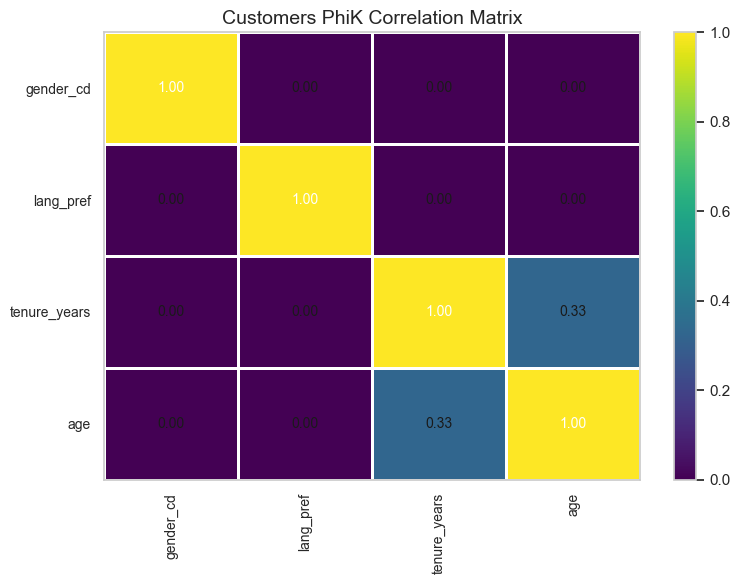

                   age  tenure_years  lang_pref  gender_cd
age           1.000000      0.327861        0.0        0.0
tenure_years  0.327861      1.000000        0.0        0.0
lang_pref     0.000000      0.000000        1.0        0.0
gender_cd     0.000000      0.000000        0.0        1.0


In [190]:
# check column availability
print(customers.columns.tolist())

# convert date columns
customers["birth_dt"] = pd.to_datetime(customers["birth_dt"], errors="coerce")
customers["bank_reg_dt"] = pd.to_datetime(customers["bank_reg_dt"], errors="coerce")

# create derived numeric columns
today = pd.Timestamp.today().normalize()
customers["age"] = ((today - customers["birth_dt"]).dt.days / 365.25).round(1)
customers["tenure_years"] = ((today - customers["bank_reg_dt"]).dt.days / 365.25).round(1)

# choose columns for phik
relevant_cols = [
    "age",
    "tenure_years",
    "lang_pref",
    "gender_cd"
]

df_subset = customers[relevant_cols].copy()

# fix dtypes for categorical columns
df_subset["lang_pref"] = df_subset["lang_pref"].astype("object")
df_subset["gender_cd"] = df_subset["gender_cd"].astype("object")

# optional: drop rows with missing values
df_subset = df_subset.dropna()

# compute phik correlation
phik_corr = df_subset.phik_matrix(
    interval_cols=["age", "tenure_years"],
    njobs=1
)


plot_correlation_matrix(
    phik_corr.values,
    x_labels=phik_corr.columns,
    y_labels=phik_corr.index,
    figsize=(8, 6),
    color_map="viridis",
    vmin=0,
    vmax=1,
    title="Customers PhiK Correlation Matrix"
)

plt.show()

print(phik_corr)


### **Check Customers Distribution**

*The dataset represents a structurally homogeneous customer segment, where variation is primarily driven by demographic and lifecycle attributes rather than organisational or product complexity.*

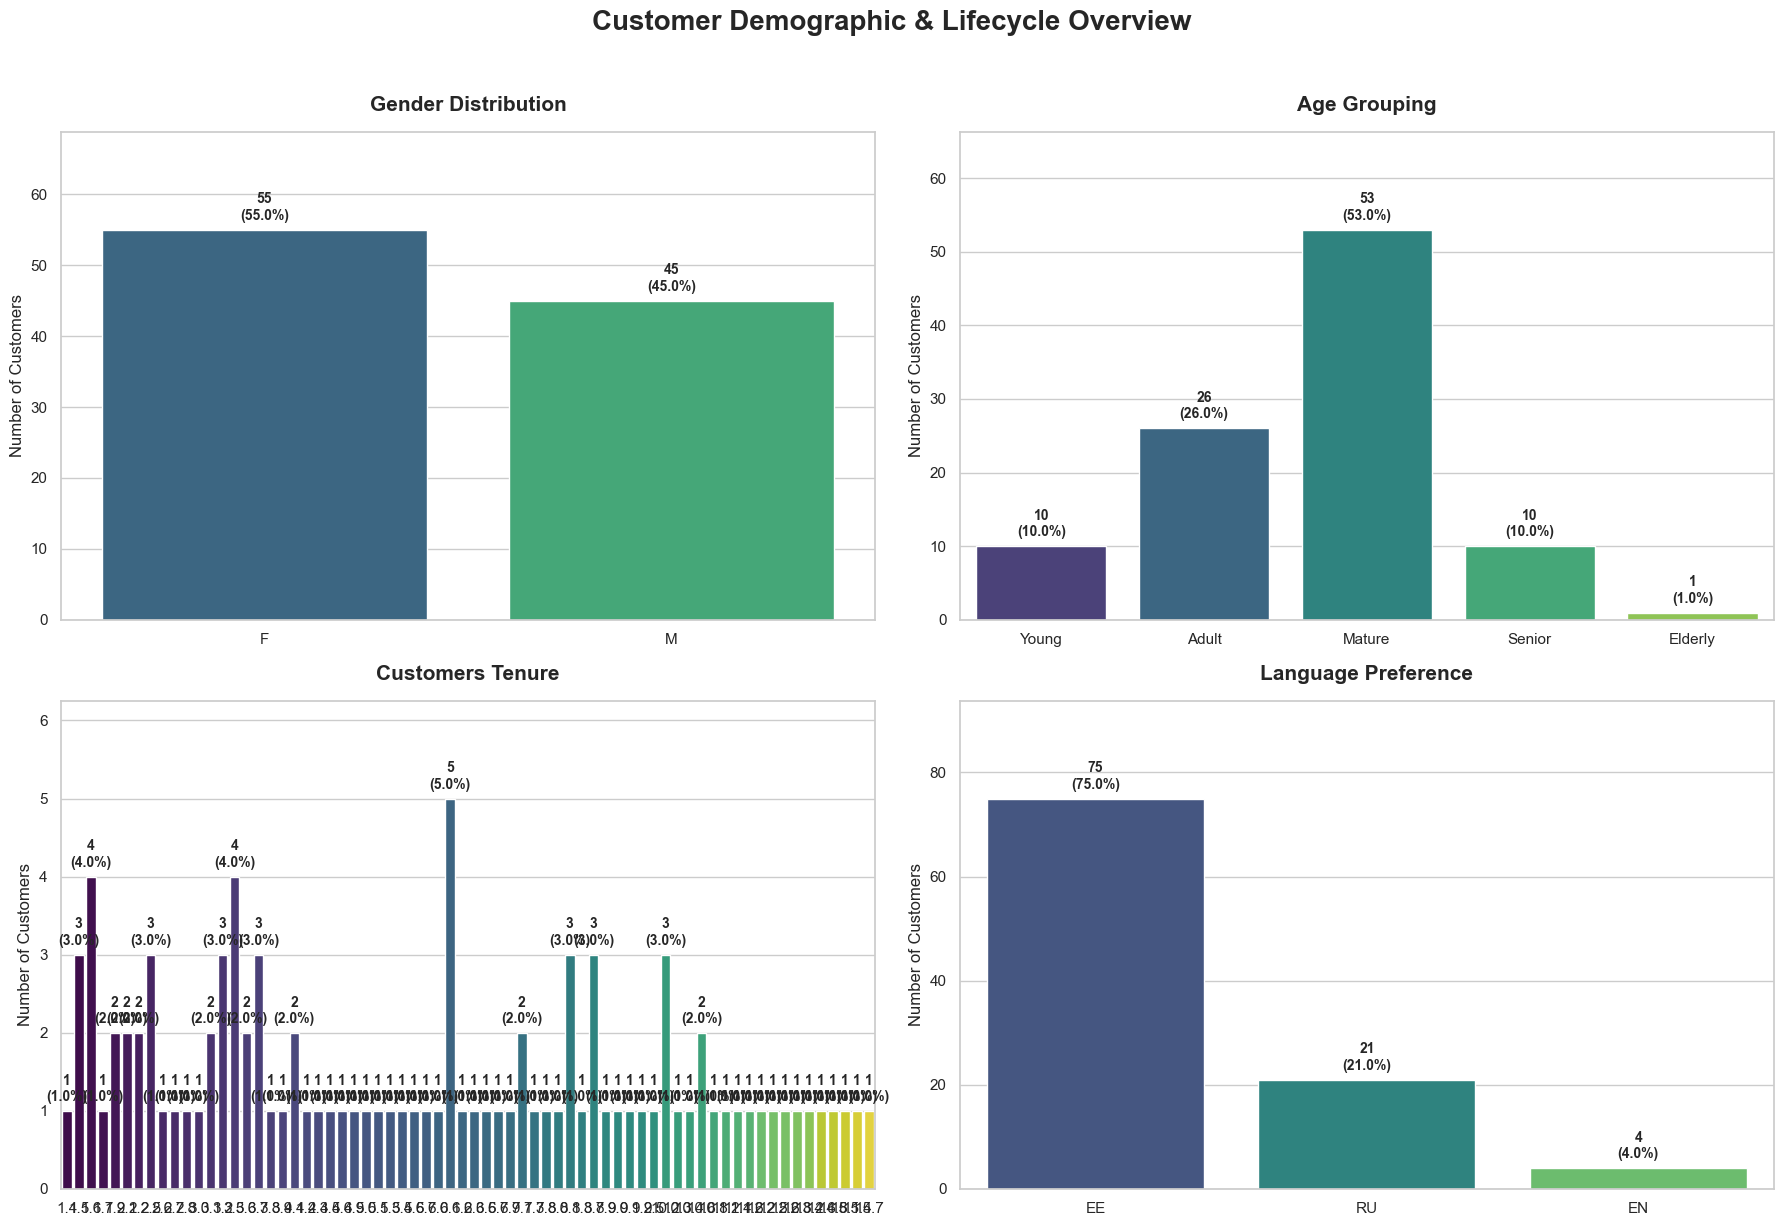

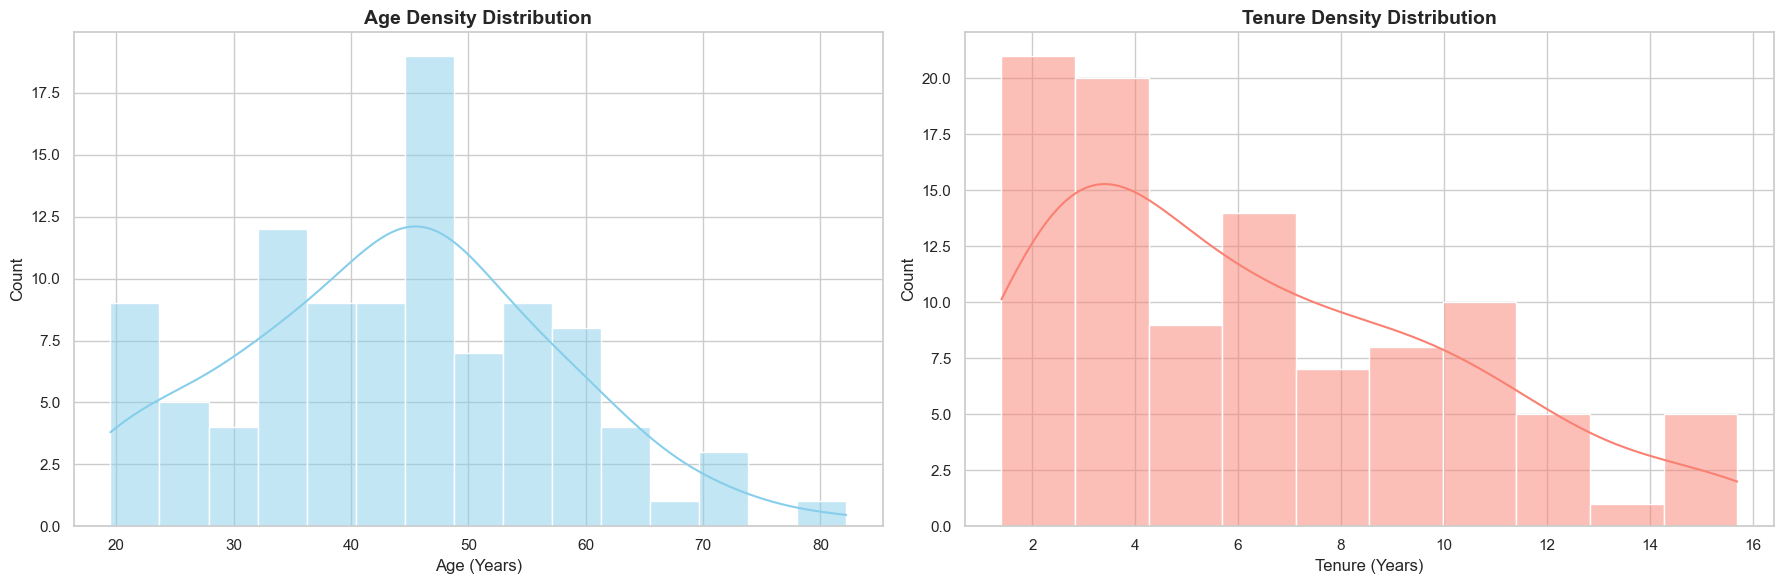

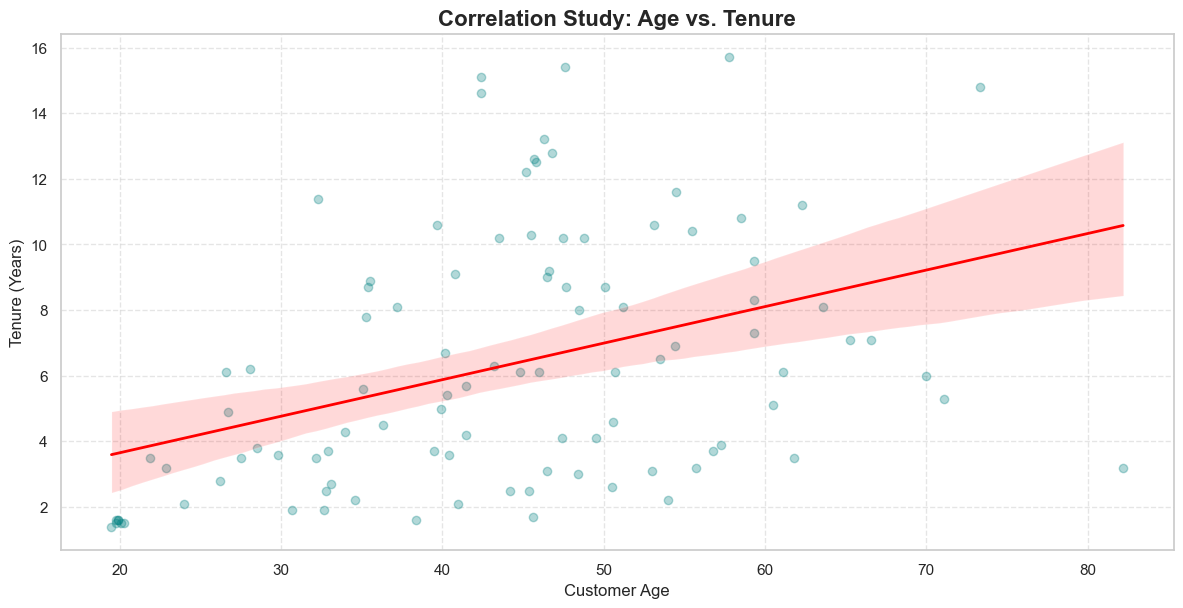

In [191]:
customers_plot = customers.copy()

#grouping age

customers_plot["age_group"] = pd.cut(
    customers_plot["age"],
    bins=[0, 25, 40, 60, 80, 120],
    labels=["Young", "Adult", "Mature", "Senior", "Elderly"]
)

# 1. Customers Distribution (Categorical Data)
# Define columns and their corresponding titles for the dashboard
cols_to_plot = ["gender_cd", "age_group", "tenure_years", "lang_pref"]
titles = ["Gender Distribution", "Age Grouping", "Customers Tenure", "Language Preference"]

# Initialize subplots: 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten() # Flatten 2D array to 1D for easier iteration

for i, col in enumerate(cols_to_plot):
    # Calculate frequency and percentage distribution
    counts = customers_plot[col].value_counts(dropna=False).reset_index()
    counts.columns = ["Label", "Count"]
    total = counts["Count"].sum()
    counts = counts.sort_values(by="Count", ascending=False)
    
    # Generate bar plot
    sns.barplot(x="Label", y="Count", data=counts, ax=axes[i], hue="Label", palette="viridis", legend=False)
    
    # Add data labels (Count & Percentage) on top of bars
    for p in axes[i].patches:
        h = p.get_height()
        perc = f"{(100 * h / total):.1f}%"
        axes[i].annotate(f"{int(h):,}\n({perc})", 
                         (p.get_x() + p.get_width() / 2, h),
                         ha="center", va="bottom", 
                         fontsize=10, fontweight="bold", 
                         xytext=(0, 5), textcoords="offset points")
    
    # Subplot styling and labeling
    axes[i].set_title(titles[i], fontsize=15, fontweight="bold", pad=15)
    axes[i].set_ylim(0, counts["Count"].max() * 1.25) # Buffer for annotations
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Number of Customers")

plt.suptitle("Customer Demographic & Lifecycle Overview", fontsize=20, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 2. Customers Distribution (Numerical Data)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Age distribution with Kernel Density Estimate (KDE)
sns.histplot(customers_plot["age"], bins=15, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Age Density Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Age (Years)")

# Tenure distribution showing skewness
sns.histplot(customers_plot["tenure_years"], bins=10, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Tenure Density Distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Tenure (Years)")

plt.tight_layout()
plt.show()

# --- 3. CORRELATION ANALYSIS ---
plt.figure(figsize=(12, 6))
# Using regplot to visualize relationship and trendline between Age and Tenure
sns.regplot(x="age", y="tenure_years", data=customers_plot, 
            scatter_kws={"alpha":0.3, "color": "teal"}, 
            line_kws={"color":"red", "lw": 2})

plt.tight_layout()
plt.title("Correlation Study: Age vs. Tenure", fontsize=16, fontweight="bold")
plt.xlabel("Customer Age")
plt.ylabel("Tenure (Years)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### **Plot Intepretation: Customer Demographic & Lifecycle Profile Mature Segment Dominance**

1. **Mature Segment Dominance:** The customer base is primarily composed of the **"Mature" (53%)** and **"Adult" (26%)** groups. The highest density sits within the **40–50 years old** bracket, indicating a stable demographic with likely established purchasing power.
2. **Gender & Language Core:** There is a slight **female majority (55%)**, and the vast majority of the base (**75%**) prefers **Estonian (EE)**. Marketing efforts are most effective when localized to this specific linguistic and gender profile.
3. **Tenure Retention Gap:** The tenure distribution is **heavily right-skewed**. While there is a strong influx of newer customers (**1–4 years**), the population thins out significantly after 5 years. This highlights a successful acquisition phase but a clear need for improved **long-term retention** strategies.
4. **Age-Tenure Correlation:** A **positive correlation** exists, showing that as age increases, tenure tends to grow. However, the high variance in the scatter plot suggests that many older individuals are still joining as new customers, representing a "late-bloomer" acquisition opportunity.

---
## **1.2 — Transactions**

## **Data Dictionary for Transactions Table**

| Field | Description |
|---|---|
| `client_id` | Foreign key to `customers.client_id` |
| `date` | Value / booking date of the transaction (bank ledger date) |
| `time` | Time component for the booking entry |
| `txn_id` | Unique transaction / journal identifier |
| `channel` | Origin channel: online, mobile, card, branch, atm |
| `d_c` | D = debit (money leaves); C = credit (money enters) |
| `trx_ccy` | Original transaction currency |
| `amount_eur` | Transaction amount converted to EUR |
| `amount_orig` | Amount in the original transaction currency |
| `acct_iban` | IBAN of the customer"s account |
| `counterparty_iban` | IBAN of the other party |
| `mcc` | 4-digit merchant category code (ISO 18245); card transactions only |
| `merchant_country` | Country of the merchant (card transactions only) |


In [192]:
transactions = pd.read_csv(r"D:/KULIAH/SEMESTER 4/DRAFT/Data Sources/seb_ee_synth_out/seb_ee_synth_out/final datasource/transactions_sampled.csv")

print(f"\n\033[1m ~~~~~ TRANSACTION DATA SANITY CHECK ~~~~~ \033[0m\n")
print(f"\033[1m--- DIMENSIONS ---\033[0m\n{transactions.shape}\n")
transactions.info()
print(f"\n\033[1m--- MISSING VALUES ---\033[0m\n{transactions.isnull().sum()}\n")
print(f"\033[1m--- DUPLICATE ---\033[0m\n{transactions.duplicated().sum()}\n")
display(transactions.describe(include="all"))



 ~~~~~ TRANSACTION DATA SANITY CHECK ~~~~~ 

--- DIMENSIONS ---
(16797, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16797 entries, 0 to 16796
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   client_id          16797 non-null  object 
 1   date               16797 non-null  object 
 2   time               16797 non-null  object 
 3   txn_id             16797 non-null  object 
 4   channel            16797 non-null  object 
 5   d_c                16797 non-null  object 
 6   trx_ccy            16797 non-null  object 
 7   amount_eur         16797 non-null  float64
 8   amount_orig        16797 non-null  float64
 9   acct_iban          16797 non-null  object 
 10  counterparty_iban  16797 non-null  object 
 11  mcc                9855 non-null   float64
 12  merchant_country   16797 non-null  object 
dtypes: float64(3), object(10)
memory usage: 1.7+ MB

--- MISSING VALUES ---
client_id       

,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig,acct_iban,counterparty_iban,mcc,merchant_country
count,16797,16797,16797,16797,16797,16797,16797,16797.000000,16797.000000,16797,16797,9855.000000,16797
unique,100,366,14309,16797,5,2,9,NaN,NaN,142,4112,NaN,17
top,CUST007049,2024-11-18,18:55:39,TX00021919,card,D,EUR,NaN,NaN,ACC_XJ27DNVWMRNKLCDTXTDNDGGC,CP_Z77UW3O3C3Q5VUFKDXQTASEI,NaN,EE
freq,676,145,5,1,9855,14859,16355,NaN,NaN,565,607,NaN,15115
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160.284148,175.795686,NaN,NaN,5550.568645,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,448.664465,534.771937,NaN,NaN,619.663207,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.820000,1.820000,NaN,NaN,4111.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.650000,20.000000,NaN,NaN,5411.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.060000,40.280000,NaN,NaN,5651.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.780000,92.440000,NaN,NaN,5816.000000,NaN


## **Transaction Base Profile**
---
### **Basic Data Information Transactions**

### **1.3.2 — Transaction: Explanatory Data Analysis (EDA)**

### **Association/Correlation Matrix in Transactions Table**

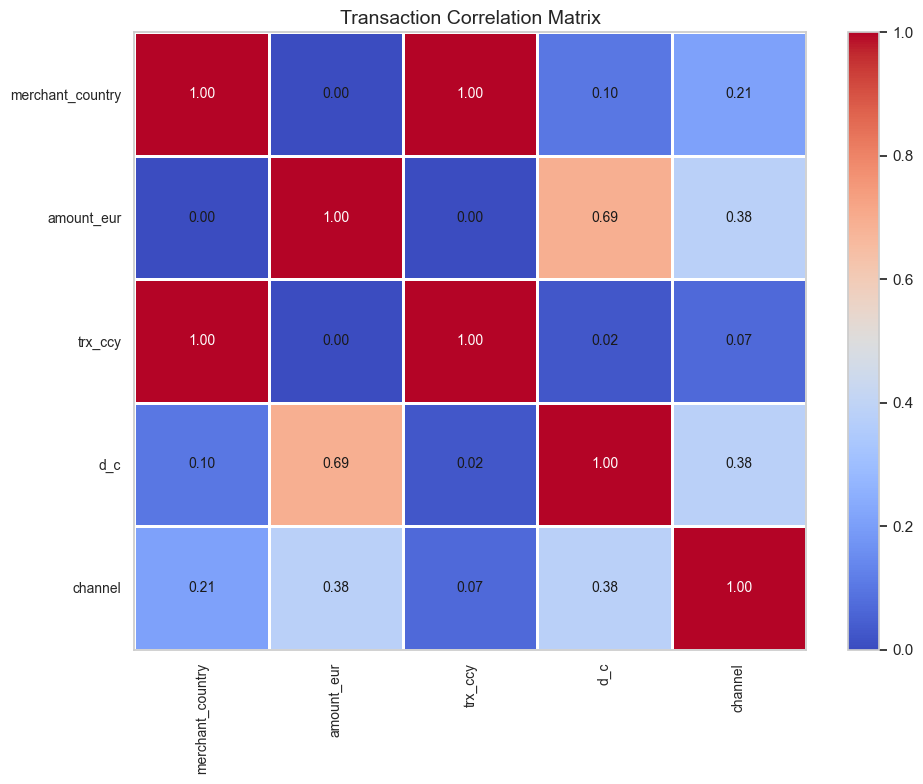

                   channel       d_c   trx_ccy  amount_eur  merchant_country
channel           1.000000  0.380999  0.067655    0.380689          0.208293
d_c               0.380999  1.000000  0.024058    0.691447          0.097675
trx_ccy           0.067655  0.024058  1.000000    0.000000          1.000000
amount_eur        0.380689  0.691447  0.000000    1.000000          0.000000
merchant_country  0.208293  0.097675  1.000000    0.000000          1.000000


In [193]:
# choose columns for phik
relevant_cols = [
    "channel", 
    "d_c", 
    "trx_ccy", 
    "amount_eur",
    "merchant_country"
]

df_subset = transactions[relevant_cols].sample(
    n=min(20000, len(transactions)),
    random_state=42
).copy()

# force categorical/string columns to plain object
cat_cols = ["channel", "d_c", "trx_ccy", "merchant_country"]
for col in cat_cols:
    df_subset[col] = df_subset[col].astype("object")

# optional: drop rows with missing values
df_subset = df_subset.dropna()

# make sure numeric column is numeric
df_subset["amount_eur"] = pd.to_numeric(df_subset["amount_eur"], errors="coerce")

# define interval columns manually
interval_cols = ["amount_eur"]

# disable multiprocessing with njobs=1
phik_corr = df_subset.phik_matrix(interval_cols=interval_cols, njobs=1)


plot_correlation_matrix(
    phik_corr.values,
    x_labels=phik_corr.columns,
    y_labels=phik_corr.index,
    figsize=(10, 8),
    vmin=0,
    vmax=1,
    color_map="coolwarm",
    title="Transaction Correlation Matrix"
)

plt.show()

print(phik_corr)


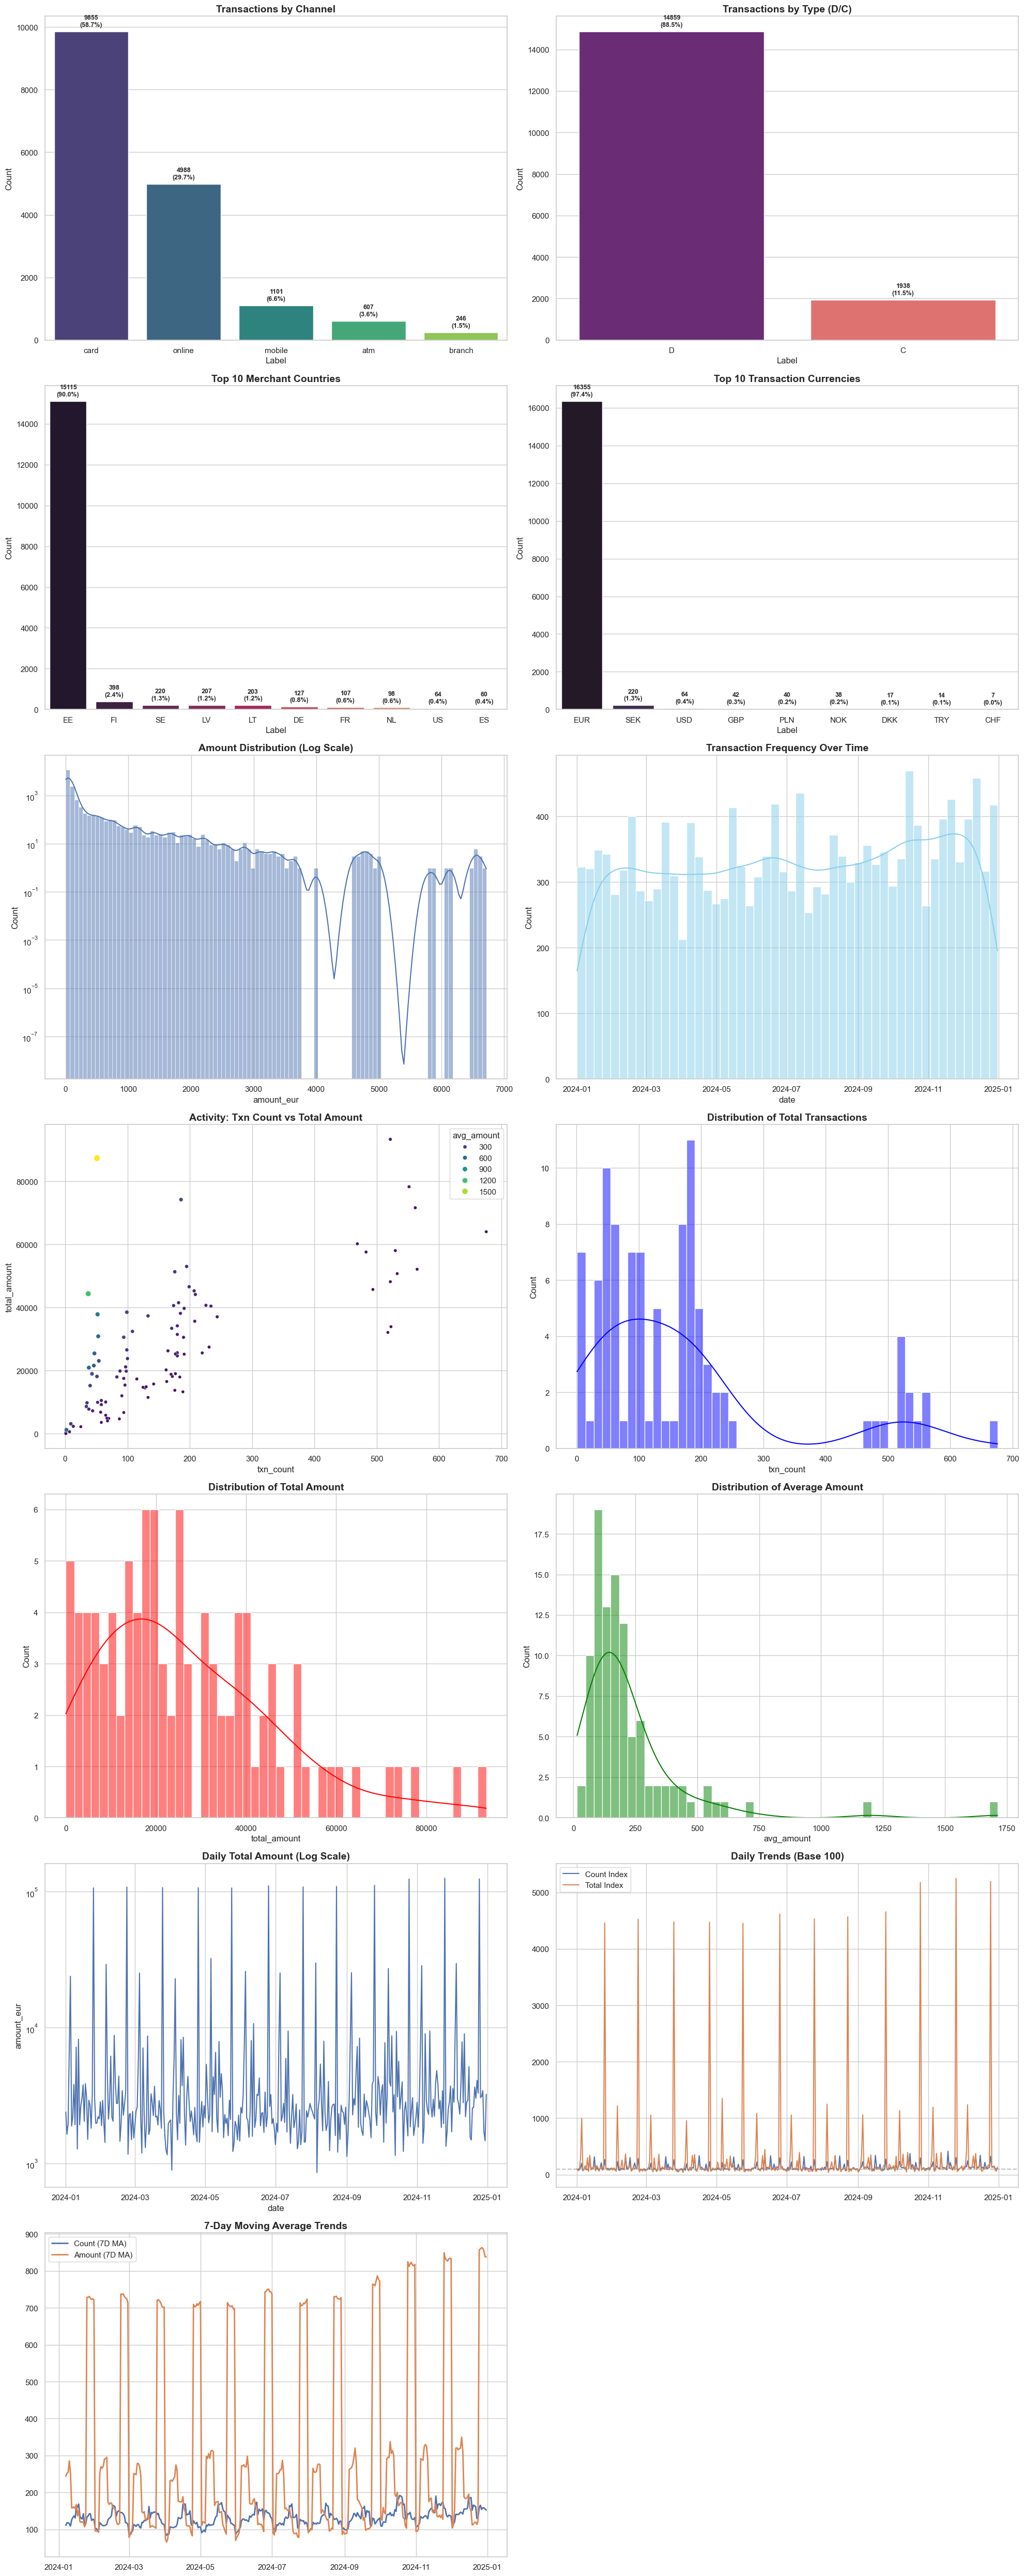

In [194]:

transactions_plot = transactions.copy()
transactions_plot["date"] = pd.to_datetime(transactions_plot["date"], errors="coerce")

# Buat Layout Subplot (7 Baris x 2 Kolom)
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(20, 50))
axes = axes.flatten()

def add_annotations(ax, total):
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            percentage = f"{(100 * height / total):.1f}%"
            ax.annotate(f"{int(height)}\n({percentage})", 
                        (p.get_x() + p.get_width() / 2, height), 
                        ha="center", va="bottom", fontsize=9, fontweight="bold", xytext=(0, 5), textcoords="offset points")

# 1. Distribution by Channel
channel_counts = transactions_plot["channel"].value_counts(dropna=False).reset_index()
channel_counts.columns = ["Label", "Count"]
sns.barplot(x="Label", y="Count", data=channel_counts, ax=axes[0], palette="viridis")
axes[0].set_title("Transactions by Channel", fontsize=14, fontweight="bold")
add_annotations(axes[0], channel_counts["Count"].sum())

# 2. Distribution by Transaction Type (d_c)
dc_counts = transactions_plot["d_c"].value_counts(dropna=False).reset_index()
dc_counts.columns = ["Label", "Count"]
sns.barplot(x="Label", y="Count", data=dc_counts, ax=axes[1], palette="magma")
axes[1].set_title("Transactions by Type (D/C)", fontsize=14, fontweight="bold")
add_annotations(axes[1], dc_counts["Count"].sum())

# 3. Distribution by Merchant Country
merchant_counts = transactions_plot["merchant_country"].value_counts().head(10).reset_index()
merchant_counts.columns = ["Label", "Count"]
sns.barplot(x="Label", y="Count", data=merchant_counts, ax=axes[2], palette="rocket")
axes[2].set_title("Top 10 Merchant Countries", fontsize=14, fontweight="bold")
add_annotations(axes[2], transactions_plot["merchant_country"].count())

# 4. Distribution by Transaction Currency
ccy_counts = transactions_plot["trx_ccy"].value_counts().head(10).reset_index()
ccy_counts.columns = ["Label", "Count"]
sns.barplot(x="Label", y="Count", data=ccy_counts, ax=axes[3], palette="mako")
axes[3].set_title("Top 10 Transaction Currencies", fontsize=14, fontweight="bold")
add_annotations(axes[3], transactions_plot["trx_ccy"].count())

# 5. Amount Distribution (Log Scale)
sns.histplot(transactions_plot["amount_eur"], bins=100, kde=True, ax=axes[4])
axes[4].set_yscale("log")
axes[4].set_title("Amount Distribution (Log Scale)", fontsize=14, fontweight="bold")

# 6. Frequency Over Time
sns.histplot(transactions_plot["date"], bins=50, kde=True, color="skyblue", ax=axes[5])
axes[5].set_title("Transaction Frequency Over Time", fontsize=14, fontweight="bold")

# --- Customer Summary Aggregation ---
customer_txn_summary = transactions_plot.groupby("client_id").agg(
    txn_count=("txn_id", "count"),
    total_amount=("amount_eur", "sum"),
    avg_amount=("amount_eur", "mean")
).reset_index()

# 7. Customer Activity Scatter
sns.scatterplot(data=customer_txn_summary, x="txn_count", y="total_amount", size="avg_amount", hue="avg_amount", palette="viridis", ax=axes[6])
axes[6].set_title("Activity: Txn Count vs Total Amount", fontsize=14, fontweight="bold")

# 8. Distribution of Txn Count
sns.histplot(customer_txn_summary["txn_count"], bins=50, kde=True, color="blue", ax=axes[7])
axes[7].set_title("Distribution of Total Transactions", fontsize=14, fontweight="bold")

# 9. Distribution of Total Amount
sns.histplot(customer_txn_summary["total_amount"], bins=50, kde=True, color="red", ax=axes[8])
axes[8].set_title("Distribution of Total Amount", fontsize=14, fontweight="bold")

# 10. Distribution of Average Amount
sns.histplot(customer_txn_summary["avg_amount"], bins=50, kde=True, color="green", ax=axes[9])
axes[9].set_title("Distribution of Average Amount", fontsize=14, fontweight="bold")

# 11. Daily Total Amount (Log)
daily_amount = transactions_plot.groupby("date")["amount_eur"].sum().reset_index()
sns.lineplot(data=daily_amount, x="date", y="amount_eur", ax=axes[10])
axes[10].set_yscale("log")
axes[10].set_title("Daily Total Amount (Log Scale)", fontsize=14, fontweight="bold")

# --- Daily Indexed Trends ---
daily_txn = transactions_plot.groupby("date").agg(
    total_amount=("amount_eur", "sum"),
    avg_amount=("amount_eur", "mean"),
    transaction_count=("amount_eur", "count")
).reset_index()

for col in ["transaction_count", "total_amount", "avg_amount"]:
    daily_txn[f"{col}_idx"] = (daily_txn[col] / daily_txn[col].iloc[0] * 100)

# 12. Daily Indexed Trends
axes[11].plot(daily_txn["date"], daily_txn["transaction_count_idx"], label="Count Index")
axes[11].plot(daily_txn["date"], daily_txn["total_amount_idx"], label="Total Index")
axes[11].axhline(100, color="grey", linestyle="--", alpha=0.5)
axes[11].legend()
axes[11].set_title("Daily Trends (Base 100)", fontsize=14, fontweight="bold")

# 13. Moving Average (7-Day)
daily_txn["txn_smooth"] = daily_txn["transaction_count_idx"].rolling(window=7).mean()
daily_txn["amt_smooth"] = daily_txn["total_amount_idx"].rolling(window=7).mean()
axes[12].plot(daily_txn["date"], daily_txn["txn_smooth"], label="Count (7D MA)", linewidth=2)
axes[12].plot(daily_txn["date"], daily_txn["amt_smooth"], label="Amount (7D MA)", linewidth=2)
axes[12].legend()
axes[12].set_title("7-Day Moving Average Trends", fontsize=14, fontweight="bold")

# Clean up
fig.delaxes(axes[13]) # Remove empty subplot
plt.tight_layout()
plt.show()

### **Transactional Characteristics**

1.  **Digital-First Behavior:** Transactions are heavily dominated by **Card (58.7%)** and **Online (29.7%)** channels. Minimal usage of ATMs and Branches (totaling < 5%) confirms a tech-savvy customer base that rarely relies on cash or face-to-face banking services.
2.  **Debit-Centric Activity:** The vast majority of transactions are **Debit (88.5%)**, indicating that these accounts are primarily used as transactional "wallets" for daily retail spending and bill payments rather than for receiving large credits or complex internal transfers.
3.  **Strictly Local & Single Currency:** Activity is highly centralized in **Estonia (90.8%)** and conducted in **EUR (97.4%)**. With negligible cross-border exposure, any sudden surge in international transactions serves as a high-priority "red flag" for risk monitoring.

### **Value Distribution & Anomaly Identification**

1.  **Power Law Distribution:** The log-scale histogram reveals a classic Power Law pattern: the majority of transactions are small, retail-level amounts.
2.  **Whale Transactions:** A visible "long tail" includes rare, high-value transactions exceeding **3,000 EUR**. In an AML/Anomaly Detection framework, these outliers are the primary targets for monitoring as they deviate from the standard retail behavior of the general population.

### **Time-Series & Seasonal Behavioral Patterns**

1.  **Payday & Cyclical Spikes:** The *Daily Trends* plots show sharp, consistent spikes around the end of the month (approx. the 25th), strongly correlating with standard **payday cycles**.
2.  **Stable Rhythm:** The *7-Day Moving Average* reveals a stable weekly rhythm. There is a strong correlation between transaction volume (Count) and value (Amount), suggesting that total spending is driven by the collective behavior of the broad user base rather than isolated, erratic transfers.
3.  **Volatility Awareness:** Significant peaks in the *Total Amount Index* (particularly toward the end of the year) suggest seasonal high-spending periods or institutional-level transactions that require pattern validation.

### **Behavioral Profiling & Risk Mitigation**

1.  **Linear Activity Cluster:** The scatter plot shows a strong linear relationship between frequency (*txn_count*) and volume (*total_amount*). Most customers are clustered in the **Low Frequency – Low Value** segment.

    * **High-Value Outliers:** Users in the top-right quadrant (High Frequency, High Value) are identified as "Power Users" or "Whales."
    * **Abnormal Profiles:** Any data points diverging significantly from the regression line—such as low frequency with extreme nominal value—should be flagged for **1LoD/2LoD monitoring** and undergo **Enhanced Due Diligence (EDD)** to mitigate potential system abuse or money laundering risks.

### **Transaction Anomaly Detection with Z-Score**

In [195]:
# Count mean and standard deviasi
mean_val = daily_txn["total_amount"].mean()
std_val = daily_txn["total_amount"].std()

# Define threshold (e.g., mean + 3 * std)
threshold = mean_val + (3 * std_val)

# assign which one is anomaly
daily_txn["is_anomaly"] = daily_txn["total_amount"] > threshold

# print days with with anomaly surge
anomalies = daily_txn[daily_txn["is_anomaly"] == True]
print("-----\033[1m" + "The Day with Anomaly Transactions:" + "\033[1m-----")
display(anomalies)

-----The Day with Anomaly Transactions:-----


,date,total_amount,avg_amount,transaction_count,transaction_count_idx,total_amount_idx,avg_amount_idx,txn_smooth,amt_smooth,is_anomaly
24,2024-01-25,106821.57,1148.619032,93,265.714286,4459.837007,1678.433282,133.061224,728.409676,True
53,2024-02-23,108374.83,1083.748300,100,285.714286,4524.686142,1583.640150,145.306122,737.479043,True
84,2024-03-25,107252.63,1165.789457,92,262.857143,4477.833909,1703.523770,140.408163,720.736321,True
115,2024-04-25,107061.95,1321.752469,81,231.428571,4469.872954,1931.426585,123.673469,709.031255,True
144,2024-05-24,106662.05,1159.370109,92,262.857143,4453.176992,1694.143421,138.367347,714.117103,True
176,2024-06-25,110621.76,1063.670769,104,297.142857,4618.496236,1554.301618,148.979592,742.593400,True
206,2024-07-25,108561.58,1167.328817,93,265.714286,4532.483018,1705.773179,126.938776,713.407227,True
235,2024-08-23,109410.74,1243.303864,88,251.428571,4567.935738,1816.792623,126.938776,730.108676,True
268,2024-09-25,111530.33,1161.774271,96,274.285714,4656.429344,1697.656532,130.204082,764.196876,True
298,2024-10-25,124024.71,1192.545288,104,297.142857,5178.073973,1742.621049,142.448980,824.570076,True


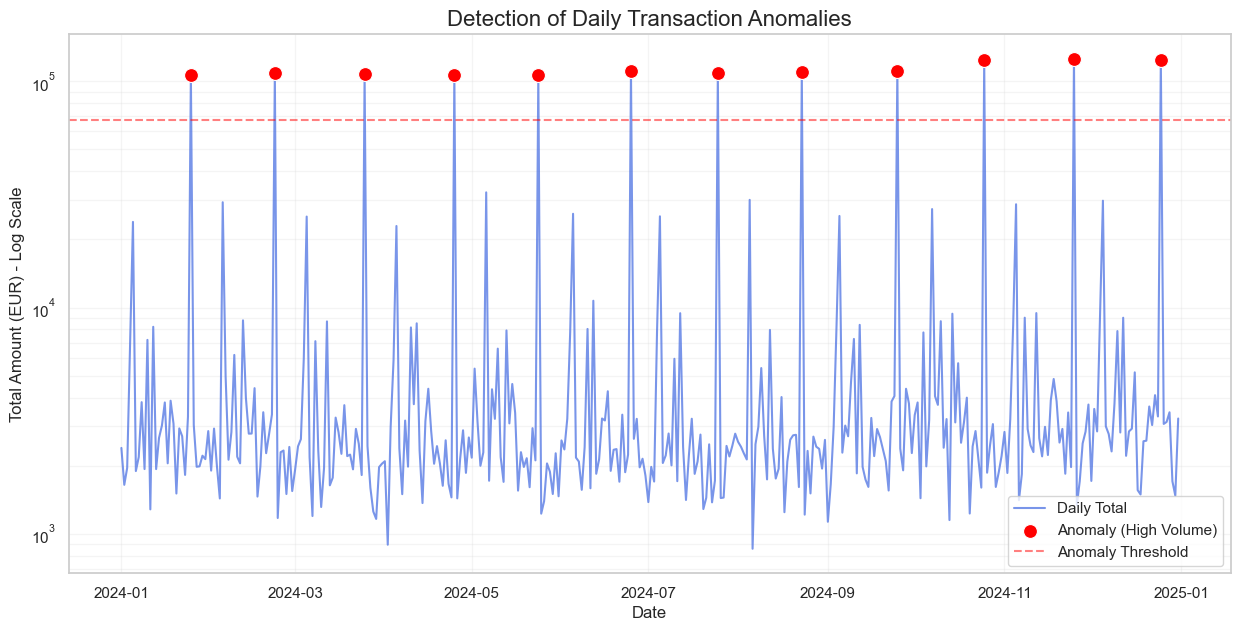

In [196]:
plt.figure(figsize=(15, 7))

sns.lineplot(data=daily_txn, x="date", y="total_amount", color="royalblue", label="Daily Total", alpha=0.7)

# Plot anomaly day (red dots)
sns.scatterplot(data=anomalies, x="date", y="total_amount", color="red", s=100, label="Anomaly (High Volume)", zorder=5)

# add a line as threshold (threshold)
plt.axhline(threshold, color="red", linestyle="--", alpha=0.5, label="Anomaly Threshold")

plt.yscale("log")
plt.title("Detection of Daily Transaction Anomalies", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Amount (EUR) - Log Scale")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

Detection of Daily Anomalies: The time-series analysis reveals a highly cyclical pattern. The red anomaly dots indicate high-volume spikes that consistently exceed the established threshold. These spikes align with monthly payday cycles (around the 25th).

---
# **SECTION 2 — Dataset Mapping: Three Lines of Defence Overview**

### **Mapping of Datasets Across the Three Lines of Defence**

| Line of Defense | Function | Dataset / Artefact | Key Fields | Share Level |
|---|---|---|---|---|
| 1LoD IT | Raw data custodian | `customers`, `transactions` | All fields incl. PII | IT only |
| 1LoD DataOps | Preprocessing & aggregation | `customer_day` | client_id, date, ratios, severity | DataOps --> BizOps |
| 1LoD Business Ops | Monitoring & escalation | `ops_case_log`, `customer_day_operational`, `it_data_request_log` | case_id, disposition, ops_rules | BizOps only |
| 2LoD Risk | Aggregate oversight | `lod2_risk_dashboard` | Monthly escalation metrics | 2LoD only |
| 2LoD Compliance | SOP adherence | `lod2_compliance_review_log` | SOP flags, compliance status | 2LoD only |
| 3LoD Audit | Independent assurance | `audit_review_log`, `audit_workpaper` | Control effectiveness | 3LoD only |


In [197]:
# AS-IS Cross-Line Data Availability Matrix
asis_availability = {
    "Line"            : ["1LoD IT", "1LoD DataOps", "1LoD Business Ops", "2LoD Risk", "2LoD Compliance", "3LoD Audit"],
    "customers"       : ["FULL ACCESS", "RESTRICTED", "NO ACCESS", "NO ACCESS", "NO ACCESS", "IT REQUEST"],
    "transactions"    : ["FULL ACCESS", "RESTRICTED", "IT REQUEST ONLY", "NO ACCESS", "NO ACCESS", "IT REQUEST"],
    "customer_day"    : ["PRODUCES", "PRODUCES", "RECEIVES", "NO ACCESS", "NO ACCESS", "IT REQUEST"],
    "ops_case_log"    : ["NO ACCESS", "NO ACCESS", "PRODUCES", "RECEIVES", "RECEIVES", "RECEIVES"],
    "IT Request Req." : ["N/A", "N/A", "For drill-down", "For raw data", "For raw data", "For all silos"],
}
asis_avail_df = pd.DataFrame(asis_availability).set_index("Line")
print("\033[1m----- AS-IS CROSS-LINE DATA AVAILABILITY MATRIX -----\033[0m")
print("Each line is restricted to its own abstracted view.")
display(asis_avail_df)


----- AS-IS CROSS-LINE DATA AVAILABILITY MATRIX -----
Each line is restricted to its own abstracted view.


,customers,transactions,customer_day,ops_case_log,IT Request Req.
Line,,,,,
1LoD IT,FULL ACCESS,FULL ACCESS,PRODUCES,NO ACCESS,N/A
1LoD DataOps,RESTRICTED,RESTRICTED,PRODUCES,NO ACCESS,N/A
1LoD Business Ops,NO ACCESS,IT REQUEST ONLY,RECEIVES,PRODUCES,For drill-down
2LoD Risk,NO ACCESS,NO ACCESS,NO ACCESS,RECEIVES,For raw data
2LoD Compliance,NO ACCESS,NO ACCESS,NO ACCESS,RECEIVES,For raw data
3LoD Audit,IT REQUEST,IT REQUEST,IT REQUEST,RECEIVES,For all silos


---
# **SECTION 3 — THE FIRST LINE OF DEFENCE (IT, DATA OPERATION, BUSINESS OPERATION) (1LoD)**
---
---

# **S3 — 1.1 1LoD — IT Department — Raw Data Custodian**

***Output:** `customers` and `transactions`*

*Database owner (Core Banking View)*

### **RAW Data IT — Baseline**

| Component       | Description                                                           |
| --------------- | --------------------------------------------------------------------- |
| **Role**        | IT (Technical data owner)                                             |
| **Input**       | Core banking system                                                   |
| **Output**      | Raw tables (`transactions`, `customers`) |
| **Granularity** | Event-level (transaction-level)                                       |
| **Fields**      | All fields including IBAN, timestamps, PII                            |
| **Processing**  | None                                                                  |
| **Purpose**     | Source of truth (SoT)      
| **Limitation** | Data access by other lines requires formal IT request |

<div style="background-color: #fff9e6; border-left: 6px solid #ffc107; padding: 18px; border-radius: 8px; font-family: "Segoe UI", Roboto, sans-serif; display: flex; align-items: flex-start; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">🛡️</span>
    <div>
        <strong style="color: #856404; font-size: 1.05em; display: block; margin-bottom: 4px; letter-spacing: 0.3px;">TRUTH SOURCE ACKNOWLEDGMENT</strong>
        <p style="margin: 0; color: #533f03; line-height: 1.5;">
            The underlying data source is established as the <b>primary reference</b>—serving as the most accurate and authentic foundation for all integrated systems and downstream analytics.
        </p>
    </div>
</div>


---
# **S3 — 1.2 — 1LoD: DataOps — Preprocessing & Aggregation**
***Input:** `customers_sampled` and `transactions_sampled`*

## **1LoD — Data Operations Department**


| Component          | Description                                                                                   |
| ------------------ | --------------------------------------------------------------------------------------------- |
| **Role**           | Data Operations (Technical Support — Data Preparation & Controlled Access)                    |
| **Input**          | Raw transaction data (Core Banking / IT systems)                                              |
| **Output**         | Partial aggregates (e.g., monitoring indicators, reports) + ad-hoc data extracts upon request |
| **Granularity**    | Mixed — event-level (IT) → aggregated indicators (Business Ops view)                          |
| **Fields**         | Includes sensitive fields; aggregated outputs exclude full detail          |
| **Processing**     | Data extraction, transformation, and aggregation based on predefined requests                 |
| **Purpose**        | Support operational monitoring and provide data upon request                                  |
| **Key Limitation** | Data access is restricted and request-based; no shared analytical dataset                     |



## **S3 — 1.2.1 Input Dataset**

*In AS-IS: Real data with PII (client_id, IBANs, exact dates)*

1. baseline_min_periods =5
2. velocity and value ratio:

| Metric | Normal | Elevated | Significant |
|---|---|---|---|
| **`ratio_velocity`** | ≤ 1.5 | 1.5 – 2.0 | > 2.0 |
| **`ratio_value`** | ≤ 1.5 | 1.5 – 2.0 | > 2.0 |

In [198]:
print("\033[1m----- AS-IS DATA OPERATIONS INPUT -----\033[0m")

# Switch to sampled data for monitoring pipeline
transactions = transactions_sampled.copy()
customers    = customers_sampled.copy()
transactions["date"] = pd.to_datetime(transactions["date"])

print(f'customers    : {customers.shape}     <-- 100 sampled customers (full annual history)')
print(f'transactions : {transactions.shape}  <-- complete history per customer')
print(f'Date range   : {transactions["date"].min()} → {transactions["date"].max()}')
print()
print("customers columns:")
print(customers.columns.tolist())
print()
print("transactions columns:")
print(transactions.columns.tolist())


----- AS-IS DATA OPERATIONS INPUT -----
customers    : (100, 9)     <-- 100 sampled customers (full annual history)
transactions : (16797, 13)  <-- complete history per customer
Date range   : 2024-01-01 00:00:00 → 2024-12-31 00:00:00

customers columns:
['client_id', 'type_cd', 'segment', 'group_head_flg', 'birth_dt', 'gender_cd', 'lang_pref', 'postal_code', 'bank_reg_dt']

transactions columns:
['client_id', 'date', 'time', 'txn_id', 'channel', 'd_c', 'trx_ccy', 'amount_eur', 'amount_orig', 'acct_iban', 'counterparty_iban', 'mcc', 'merchant_country']


## **S3 — 1.2.2 Data Process:**

```mermaid
flowchart LR
    A["Raw Daily Transactions\n(per customer per day)"]
        --> B[Aggregate Daily Transactions\n• sum amounts\n• count transactions\n• build day-level features]
    B --> C["Compute Expanding Baselines\n(min_periods = 5)\n• baseline_txn_count\n• baseline_total_amount"]
    C --> D["Compute Volatility\n• Coefficient of Variation (CV)\n= std / mean\nper customer daily series"]
    D --> E[Calculate Ratio Metrics\n• ratio_velocity\n• ratio_value\nCompare current value vs baseline]
    E --> F["Apply Severity Labels\n• Normal (≤ 1.5)\n• Elevated (≤ 2.0)\n• Significant (> 2.0)"]
    F --> G[Apply auto_red_flag\nSignificant velocity OR value]
```

**Data Preprocessing Pipeline (identical logic to AS-IS):**
1. Aggregate daily transactions per pseudo_customer_key
2. Enrich with synthetic demographics (IT request needed)
3. Compute expanding baselines (min_periods=5)
4. Calculate ratio_velocity and ratio_value
5. Apply deviation_group → severity labels
6. Apply auto_red_flag


<div style="background-color: #fffaf0; border-left: 6px solid #d97706; padding: 18px; border-radius: 8px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">⏳</span>
        <strong style="color: #92400e; font-size: 1.05em; letter-spacing: 0.3px;">AS-IS OPERATIONAL BOTTLENECK</strong>
    </div>
    <div style="color: #451a03; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0;">
            <b>Key characteristic:</b> Because input contains raw PII, data distribution is <b>strictly sequential and siloed</b>—requiring repetitive IT-mediated data requests and manual managerial approvals for every line of defense.
        </p>
        <div style="margin-top: 10px; padding: 8px; background: #fff1f2; border-radius: 6px; border: 1px solid #fecaca; display: inline-block; font-size: 0.85em; color: #991b1b; font-weight: bold;">
            Result: Inter-departmental waiting time & process fatigue
        </div>
    </div>
</div>

### **S3 — 1.2.2.1 Data Preprocessing: Aggregate daily transactions** (`Customer Transaction per Day`)

In [199]:
print(f"\n\033[1m----- SANITY CHECK BEFORE AGGREGATE PROCESS -----\033[0m")
print(f'Transactions Shape : {transactions.shape}')
print(f'Customers Shape    : {customers.shape}')
print(f'NaN (transactions) : {transactions.isnull().sum().sum()}')
print(f'NaN (customers)    : {customers.isnull().sum().sum()}')


print("\n\033[1m ~~~~~ MONITORING PIPELINE INPUT ~~~~~ \n\033[0m")
print(f"Avg txn/cust : {len(transactions)/len(customers):.1f}")


----- SANITY CHECK BEFORE AGGREGATE PROCESS -----
Transactions Shape : (16797, 13)
Customers Shape    : (100, 9)
NaN (transactions) : 6942
NaN (customers)    : 0

 ~~~~~ MONITORING PIPELINE INPUT ~~~~~ 

Avg txn/cust : 168.0


In [200]:
# Aggregate daily transactions per customer
customer_day = (
    transactions
    .dropna(subset=["client_id", "date"])
    .groupby(["client_id", "date"], as_index=False)
    .agg(
        daily_txn_count    = ("txn_id", "count"),
        daily_total_amount = ("amount_eur", "sum"),
        daily_avg_amount   = ("amount_eur", "mean"),
    )
)
customer_day["daily_total_amount"] = customer_day["daily_total_amount"].round(2)
customer_day["daily_avg_amount"]   = customer_day["daily_avg_amount"].round(2)

print(f'customer_day: {customer_day.shape}')
print(f'Unique clients: {customer_day["client_id"].nunique():,}')
customer_day.head()


customer_day: (11717, 5)
Unique clients: 100


,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount
0,CUST000150,2024-01-12,1,75.08,75.08
1,CUST000150,2024-01-16,1,13.22,13.22
2,CUST000150,2024-01-18,1,16.07,16.07
3,CUST000150,2024-01-22,1,11.05,11.05
4,CUST000150,2024-01-25,1,1485.08,1485.08


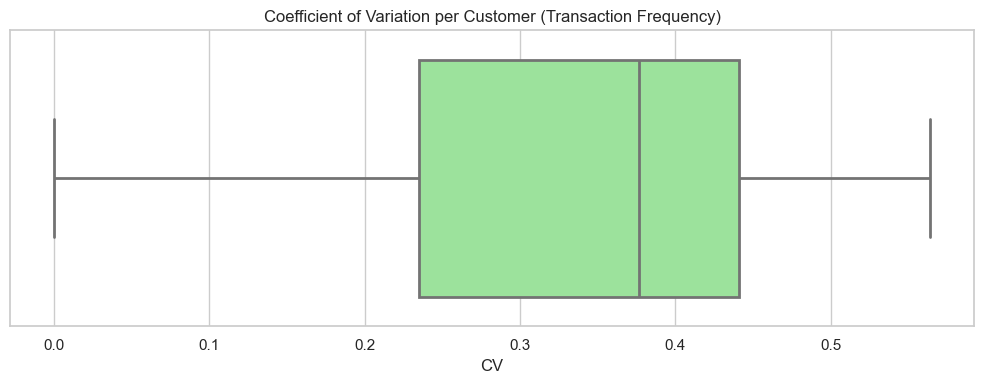

Median CV: 0.377


In [201]:
# Customer-Day Sorting
customer_day = customer_day.sort_values(["client_id", "date"]).reset_index(drop=True)

# Coefficient of Variation per customer
cv_per_customer = (
    customer_day
    .groupby("client_id")["daily_txn_count"]
    .agg(["mean", "std"])
)
cv_per_customer["cv"] = cv_per_customer["std"] / cv_per_customer["mean"]

plt.figure(figsize=(10, 4))
sns.boxplot(x=cv_per_customer["cv"], color="lightgreen", fliersize=7, linewidth=2)
plt.title("Coefficient of Variation per Customer (Transaction Frequency)")
plt.xlabel("CV")
plt.tight_layout()
plt.show()

print(f'Median CV: {cv_per_customer["cv"].median():.3f}')


# **BOX PLOT INTEPRETATION**

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 900px; margin: auto;">
    <div style="border-bottom: 2px solid #f1f5f9; padding-bottom: 15px; margin-bottom: 20px;">
        <strong style="color: #0f172a; font-size: 1.1em; letter-spacing: 0.5px; display: block;">📈 DATA VALIDATION: COEFFICIENT OF VARIATION (CV)</strong>
        <p style="margin: 5px 0 0 0; color: #64748b; font-size: 0.85em;">Empirical Analysis of Behavioral Stability Across the Customer Population.</p>
    </div>
    <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 15px; margin-bottom: 25px; text-align: center;">
        <div style="background: #f8fafc; padding: 10px; border-radius: 8px;">
            <small style="color: #64748b; display: block;">Median CV</small>
            <b style="color: #0f172a; font-size: 1.2em;">0.377</b>
        </div>
        <div style="background: #f8fafc; padding: 10px; border-radius: 8px;">
            <small style="color: #64748b; display: block;">Upper Whisker</small>
            <b style="color: #0f172a; font-size: 1.2em;">≈ 0.56</b>
        </div>
        <div style="background: #f0fdf4; padding: 10px; border-radius: 8px;">
            <small style="color: #166534; display: block;">Statistical Outliers</small>
            <b style="color: #15803d; font-size: 1.2em;">None (0)</b>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.6; font-size: 0.95em;">
        <p style="margin-bottom: 15px;">
            Based on the <b>Boxplot visualization</b>, the distribution of the Coefficient of Variation (CV) confirms a relatively stable yet diverse behavioral profile within the sample:
        </p>
        <ul style="margin-bottom: 15px; padding-left: 20px;">
            <li><b>Central Tendency:</b> The <b>Median CV of 0.377</b> indicates that the majority of customers exhibit moderate daily transaction fluctuations (below 40% deviation).</li>
            <li><b>Interquartile Range (IQR):</b> The core population (green box) falls between <b>≈0.24 and ≈0.44</b>. This empirically validates that a significant portion of the population borders the <b>0.4 "Elevated" threshold</b>.</li>
            <li><b>Statistical Homogeneity:</b> The absence of data points beyond the whiskers proves that <b>pure statistical anomaly detection (IQR-based) fails to identify outliers</b> in this specific sample.</li>
        </ul>
        <div style="background-color: #f0f9ff; border-left: 4px solid #0ea5e9; padding: 15px; border-radius: 4px; margin-top: 15px;">
            <b style="color: #0369a1;">Critical Governance Insight:</b> 
            Since the statistical upper bound is <b>0.56</b>, a customer with a CV of 0.5 (which is operationally volatile) would be considered "normal" by standard statistics. This reinforces the necessity of <b>Business-Defined Thresholds</b> (e.g., CV > 0.4) to bridge the gap where statistical models remain blind to operational risks.
        </div>
    </div>
</div>

In [202]:
# 1. calculate Quartile 1 (25%) and Quartile 3 (75%)
Q1 = cv_per_customer["cv"].quantile(0.25)
Q3 = cv_per_customer["cv"].quantile(0.75)
IQR = Q3 - Q1

# 2. define Outlier Boundary Anomaly threshold)
# Formula: Q3 + 1.5 * IQR
upper_bound = Q3 + (1.5 * IQR)

# 3. Filtering customer in the outlier threshold
outliers = cv_per_customer[cv_per_customer["cv"] > upper_bound]

# 4. Print the result
print(f"Threshold for Anomaly (Upper Bound): {upper_bound:.4f}")
print(f"Total Customers: {len(cv_per_customer)}")
print(f"Number of Outliers detected: {len(outliers)}")
print(f"Percentage of Anomalies: {(len(outliers)/len(cv_per_customer))*100:.22f}%")

# Result
print("\033[1m" + "\nTop 10 High-Risk Customers (Outliers):"+"\033[0m")
print(outliers.sort_values(by="cv", ascending=False).head(10))

Threshold for Anomaly (Upper Bound): 0.7498
Total Customers: 100
Number of Outliers detected: 0
Percentage of Anomalies: 0.0000000000000000000000%

Top 10 High-Risk Customers (Outliers):
Empty DataFrame
Columns: [mean, std, cv]
Index: []


**Interpretation**

```mermaid
flowchart LR

    A["Elevated CV Detected\n(Based on Monitoring Threshold)"] --> B1[1LoD – Operations\nMonitor & Prioritize Review]

    B1 --> C1[2LoD – Risk & Compliance\nDefine & Validate Threshold\nAlign with Risk Appetite]

    C1 --> D1[3LoD – Internal Audit\nVerify CV Logic & Threshold Application\nValidate Using SDG]

    B1 --> X[Cross-Line Reporting\nAggregated Risk Indicators]


```


<div style="background-color: #ffffff; border: 2px solid #0f172a; padding: 30px; border-radius: 15px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 10px 25px rgba(0,0,0,0.1); max-width: 950px; margin: auto;">
    <div style="text-align: center; margin-bottom: 25px; border-bottom: 2px solid #f1f5f9; padding-bottom: 15px;">
        <h2 style="color: #0f172a; margin: 0; font-size: 1.4em; letter-spacing: 1px; text-transform: uppercase;">CV Governance & 3LoD Interpretation</h2>
        <p style="color: #64748b; font-size: 0.9em; margin-top: 5px;">Bridging Statistical Analysis with Operational Risk Identification</p>
    </div>
    <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 15px; margin-bottom: 30px;">
        <div style="background: #f0fdf4; padding: 15px; border-radius: 10px; border-top: 4px solid #22c55e;">
            <strong style="color: #166534; font-size: 0.9em; display: block; margin-bottom: 8px;">🛡️ 1LoD: Operations</strong>
            <p style="font-size: 0.8em; color: #14532d; line-height: 1.5; margin: 0;">
                Uses CV for <b>Alert Dashboards</b>. Detects increased variability to prioritize monitoring.
            </p>
            <div style="margin-top: 10px; font-size: 0.7em; font-weight: bold; color: #166534; opacity: 0.8;">PURPOSE: DETECTION</div>
        </div>
        <div style="background: #eff6ff; padding: 15px; border-radius: 10px; border-top: 4px solid #3b82f6;">
            <strong style="color: #1e40af; font-size: 0.9em; display: block; margin-bottom: 8px;">⚖️ 2LoD: Risk & Comp</strong>
            <p style="font-size: 0.8em; color: #1e3a8a; line-height: 1.5; margin: 0;">
                Defines <b>Risk Thresholds</b> (e.g., CV > 0.4). Aligns alerts with Risk Appetite Framework.
            </p>
            <div style="margin-top: 10px; font-size: 0.7em; font-weight: bold; color: #1e40af; opacity: 0.8;">PURPOSE: GOVERNANCE</div>
        </div>
        <div style="background: #f8fafc; padding: 15px; border-radius: 10px; border-top: 4px solid #64748b;">
            <strong style="color: #334155; font-size: 0.9em; display: block; margin-bottom: 8px;">🔍 3LoD: Internal Audit</strong>
            <p style="font-size: 0.8em; color: #475569; line-height: 1.5; margin: 0;">
                Verifies CV logic via <b>Synthetic Data</b>. Tests reproducibility and control correctness.
            </p>
            <div style="margin-top: 10px; font-size: 0.7em; font-weight: bold; color: #475569; opacity: 0.8;">PURPOSE: ASSURANCE</div>
        </div>
    </div>
    <div style="background: #fffbeb; border: 1px solid #fcd34d; padding: 20px; border-radius: 10px; margin-bottom: 25px;">
        <strong style="color: #92400e; font-size: 1em; display: block; margin-bottom: 10px;">📌 Conclusion: The Limit of Statistical Anomaly</strong>
        <p style="margin: 0; color: #78350f; font-size: 0.9em; line-height: 1.6; text-align: justify;">
            No customers were identified as outliers under the <b>IQR threshold (0.7498)</b>, suggesting that statistical anomaly detection alone is insufficient. This highlights the critical role of <b>business-defined thresholds</b> in bridging the gap between raw statistical analysis and operational risk identification.
        </p>
    </div>
    <div style="background: #f1f5f9; padding: 15px; border-radius: 8px; font-size: 0.85em; color: #475569; border-left: 4px solid #cbd5e1;">
        <p style="margin: 0;">
            <b>Observation:</b> Statistical anomaly detection is highly sensitive to <b>sample size</b>. While a larger dataset may trigger several CV outliers, smaller samples may fail to identify risk-relevant cases, making <b>human-led governance</b> indispensable.
        </p>
    </div>

</div>

### **Identification of Customers with Irregular Transaction Patterns**

The identified unstable customer exhibits a **Coefficient of Variation (CV) of 0.439**, indicating that the customer’s transaction activity varies by approximately **44%** relative to its average level. This level of variability reflects an irregular but plausible transaction pattern, rather than extreme or anomalous behavior.

**Transaction Pattern Categories:**
* **CV < 0.2**: Regular transaction behavior
* **CV 0.2 – 0.4**: Moderately variable transaction behavior
* **CV > 0.4**: Irregular transaction behavior

<div style="background-color: #f8fafc; border: 1px solid #e2e8f0; padding: 20px; border-radius: 10px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: flex-start;">
        <div style="background: #0ea5e9; color: white; padding: 6px 12px; border-radius: 6px; font-weight: bold; font-size: 0.8em; margin-right: 15px; margin-top: 2px;">
            NOTE
        </div>
        <div style="color: #334155; line-height: 1.6; font-size: 0.95em;">
            <p style="margin: 0;">
                This categorization is used <b>solely to distinguish levels of natural behavioral variability</b> and does not represent a risk classification.
            </p>
            <div style="margin-top: 12px; display: grid; grid-template-columns: 1fr 1fr; gap: 10px; border-top: 1px solid #f1f5f9; padding-top: 12px;">
                <div style="font-size: 0.85em;">
                    <span style="color: #0284c7; font-weight: bold;">Low CV (≈ 0):</span><br>
                    Behavior is stable & predictable.
                </div>
                <div style="font-size: 0.85em;">
                    <span style="color: #0284c7; font-weight: bold;">High CV (> 0.4):</span><br>
                    Behavior is volatile.
                </div>
            </div>
        </div>
    </div>
</div>

### **Calibration of the Minimum Observation Parameter (`min_periods`)**

The parameter defining the minimum number of historical observations (`min_periods`) in the expanding mean approach is calibrated using customers with irregular transaction behavior. This choice is intentional, as customers with higher variability make the trade-off between **baseline stability** and **responsiveness** more visible.

#### **Calibration Logic**
* **Stable Patterns:** For customers with stable transaction patterns, different values of `min_periods` tend to produce similar baseline behavior.
* **Irregular Patterns:** In contrast, for irregular customers, smaller values lead to overly reactive and noisy baselines, while larger values delay baseline formation.

As a result, irregular customers provide the most informative cases for evaluating **baseline robustness**.

#### **Implementation**
Although the calibration is informed by high-variability customers, the selected `min_periods` value is **applied uniformly** across the dataset. This ensures methodological simplicity while maintaining a conservative and robust global parameter suitable for the broader customer population.

### **S3 — 1.2.2.2 Data Preprocessing: Compute expanding baselines (min_periods=5)**

### **Customer Specific Baseline - Based on Transactions**

*Customer-specific baseline values are computed using an expanding mean approach with a minimum number of historical observations*

This ensures that deviations are assessed only after sufficient behavioral history is available, thereby reducing noise and avoiding premature labeling.

In [203]:
# Sort by customer and date first.
# Compute expanding baselines using the same AS-IS rule:
# baseline is formed with min_periods=5 and excludes the current observation,
# to preserve strict comparability with the AS-IS monitoring logic.

customer_day["baseline_txn_count"] = (
    customer_day
    .groupby("client_id")["daily_txn_count"]
    .transform(lambda s: s.shift(1).expanding(min_periods=5).mean())
)

customer_day["baseline_total_amount"] = (
    customer_day
    .groupby("client_id")["daily_total_amount"]
    .transform(lambda s: s.shift(1).expanding(min_periods=5).mean())
)

customer_day["baseline_avg_amount"] = (
    customer_day
    .groupby("client_id")["daily_avg_amount"]
    .transform(lambda s: s.shift(1).expanding(min_periods=5).mean())
)

display(customer_day.head())


n_formed = customer_day["baseline_txn_count"].notna().sum()
print(f'Baseline formed     : {n_formed:,} ({n_formed/len(customer_day)*100:.1f}%)')
print(f'Baseline not formed : {customer_day["baseline_txn_count"].isna().sum():,}')
print(f'Total customer-days : {len(customer_day):,}')
display(customer_day.head(10))

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,baseline_avg_amount
0,CUST000150,2024-01-12,1,75.08,75.08,NaN,NaN,NaN
1,CUST000150,2024-01-16,1,13.22,13.22,NaN,NaN,NaN
2,CUST000150,2024-01-18,1,16.07,16.07,NaN,NaN,NaN
3,CUST000150,2024-01-22,1,11.05,11.05,NaN,NaN,NaN
4,CUST000150,2024-01-25,1,1485.08,1485.08,NaN,NaN,NaN


Baseline formed     : 11,232 (95.9%)
Baseline not formed : 485
Total customer-days : 11,717


,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,baseline_avg_amount
0,CUST000150,2024-01-12,1,75.08,75.08,NaN,NaN,NaN
1,CUST000150,2024-01-16,1,13.22,13.22,NaN,NaN,NaN
2,CUST000150,2024-01-18,1,16.07,16.07,NaN,NaN,NaN
3,CUST000150,2024-01-22,1,11.05,11.05,NaN,NaN,NaN
4,CUST000150,2024-01-25,1,1485.08,1485.08,NaN,NaN,NaN
5,CUST000150,2024-02-12,1,90.64,90.64,1.0,320.100000,320.100000
6,CUST000150,2024-02-16,1,14.32,14.32,1.0,281.856667,281.856667
7,CUST000150,2024-02-20,1,10.70,10.70,1.0,243.637143,243.637143
8,CUST000150,2024-02-23,1,1385.76,1385.76,1.0,214.520000,214.520000
9,CUST000150,2024-03-12,1,69.48,69.48,1.0,344.657778,344.657778


**Explanation for NaN values in the customer baseline:**

Baseline values are computed using an expanding mean with a minimum observation requirement ``(min_periods = 5)``. As a result, baseline values are not available for the first four observations, as insufficient historical data exists to construct a stable baseline. The baseline becomes available starting from the fifth observation.

**Intepretation for the table (mentioned above)**

*For this customer, the baseline indicates an average of approximately 1 transaction per day, with an average transaction value of around **320.1 euros.** The relatively high baseline value is influenced by a large transaction in the early observation period, illustrating how initial observations can affect baseline formation.*




In [204]:
# to check baseline

customer_day[[
    "client_id", "date",
    "daily_txn_count", "baseline_txn_count",
    "daily_total_amount", "baseline_total_amount"
]].head(10)


,client_id,date,daily_txn_count,baseline_txn_count,daily_total_amount,baseline_total_amount
0,CUST000150,2024-01-12,1,NaN,75.08,NaN
1,CUST000150,2024-01-16,1,NaN,13.22,NaN
2,CUST000150,2024-01-18,1,NaN,16.07,NaN
3,CUST000150,2024-01-22,1,NaN,11.05,NaN
4,CUST000150,2024-01-25,1,NaN,1485.08,NaN
5,CUST000150,2024-02-12,1,1.0,90.64,320.100000
6,CUST000150,2024-02-16,1,1.0,14.32,281.856667
7,CUST000150,2024-02-20,1,1.0,10.70,243.637143
8,CUST000150,2024-02-23,1,1.0,1385.76,214.520000
9,CUST000150,2024-03-12,1,1.0,69.48,344.657778


<div style="background-color: #ffffff; border: 2px solid #0f172a; padding: 30px; border-radius: 15px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 10px 25px rgba(0,0,0,0.05); max-width: 950px; margin: auto;">
    <div style="text-align: center; margin-bottom: 30px; border-bottom: 2px solid #f1f5f9; padding-bottom: 15px;">
        <h2 style="color: #0f172a; margin: 0; font-size: 1.5em; letter-spacing: 1px; text-transform: uppercase;">Result Interpretation: Adaptive Monitoring</h2>
        <p style="color: #64748b; font-size: 0.9em; margin-top: 5px;">Transitioning from Static Thresholds to Dynamic Behavioral Baselines</p>
    </div>
    <div style="display: grid; grid-template-columns: 1fr 1.2fr; gap: 20px; margin-bottom: 30px;">
        <div style="background: #f8fafc; padding: 15px; border-radius: 10px; border-left: 5px solid #3b82f6;">
            <strong style="color: #1e3a8a; display: block; margin-bottom: 10px;">📉 Baseline Adaptation</strong>
            <p style="font-size: 0.85em; color: #334155; line-height: 1.6; margin: 0;">
                For <b>CUST000150</b>, the baseline initially formed at <b>€320.1</b> (first 5 observations). 
                Through late-period high-value transactions (€1,485 & €1,385), the system naturally recalibrated, stabilizing the baseline at <b>€317.1</b> without manual intervention.
            </p>
        </div>
        <div style="background: #fffbeb; padding: 15px; border-radius: 10px; border-left: 5px solid #f59e0b;">
            <strong style="color: #92400e; display: block; margin-bottom: 10px;">⚡ Automated Computational Trigger</strong>
            <div style="background: white; padding: 10px; border-radius: 6px; border: 1px solid #fde68b; font-family: monospace; font-size: 0.85em; color: #78350f;">
                IF (Daily_Amount / Baseline_Amount) > 3.0 <br>
                THEN auto_red_flag = 1
            </div>
            <p style="font-size: 0.75em; color: #78350f; margin-top: 8px; font-style: italic;">
                *Serves as a system-generated indicator for triage, not a confirmed risk judgment.
            </p>
        </div>
    </div>
    <div style="border: 1px solid #e2e8f0; padding: 20px; border-radius: 12px; background: #ffffff;">
        <strong style="color: #0f172a; font-size: 1em; display: block; margin-bottom: 15px;">🔍 Dual-Purpose Analytical Architecture</strong>
        <div style="display: flex; gap: 20px;">
            <div style="flex: 1; border-right: 1px solid #f1f5f9; padding-right: 15px;">
                <b style="color: #475569; font-size: 0.85em;">1. Operational Logic</b><br>
                <span style="font-size: 0.85em; color: #64748b;">Captures customer-level patterns daily to decode the "why" behind transaction frequency and spikes.</span>
            </div>
            <div style="flex: 1; padding-left: 15px;">
                <b style="color: #475569; font-size: 0.85em;">2. Analytical Baseline</b><br>
                <span style="font-size: 0.85em; color: #64748b;">Functions as the core for deviation-based labeling, providing early warning signals for downstream assessment.</span>
            </div>
        </div>
    </div>
    <div style="margin-top: 25px; padding: 15px; background: #0f172a; border-radius: 10px; text-align: center;">
        <p style="margin: 0; color: #f8fafc; font-size: 0.95em; line-height: 1.6;">
            "By avoiding reliance on <b>rigid global averages</b>, the TO-BE model enables <b>personalized anomaly detection</b> that adapts naturally to evolving customer behavior."
        </p>
    </div>

</div>


## **Definition of Suspiciousness Labels**

In this research, We create suspicious levels in the three levels— low, medium, and high—based on the degree of deviation from historical transaction behavior and the customer"s profile, rather than on absolute transaction values or as confirmation of fraud. These levels represent early operational risk signals and are used to support grouping, review, and escalation within the Three Lines of Defense. The definitions applied to each level of suspiciousness are summarized below:


### **Table 1. Definition of Suspiciousness Labels Based on Deviation from Customer-Specific Historical & Profile Base line Baselines**




<div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 15px; font-family: "Segoe UI", Roboto, sans-serif;">
    <div style="border: 1px solid #e2e8f0; border-top: 5px solid #10b981; padding: 15px; border-radius: 8px; background: #fcfdfd;">
        <strong style="color: #065f46; font-size: 0.9em;">🟢 LOW RISK</strong>
        <p style="font-size: 0.8em; color: #334155; margin: 10px 0;">Behavior is consistent with historical patterns.</p>
        <div style="font-size: 0.75em; background: #dcfce7; color: #166534; padding: 5px; border-radius: 4px; font-weight: bold;">
            Action: Normal Operations
        </div>
    </div>
    <div style="border: 1px solid #e2e8f0; border-top: 5px solid #f59e0b; padding: 15px; border-radius: 8px; background: #fffcf5;">
        <strong style="color: #92400e; font-size: 0.9em;">🟡 MEDIUM RISK</strong>
        <p style="font-size: 0.8em; color: #334155; margin: 10px 0;">Noticeable deviation, potentially explainable by context.</p>
        <div style="font-size: 0.75em; background: #fef3c7; color: #92400e; padding: 5px; border-radius: 4px; font-weight: bold;">
            Action: 1st Line Monitoring
        </div>
    </div>
    <div style="border: 1px solid #e2e8f0; border-top: 5px solid #ef4444; padding: 15px; border-radius: 8px; background: #fef2f2;">
        <strong style="color: #991b1b; font-size: 0.9em;">🔴 HIGH RISK</strong>
        <p style="font-size: 0.8em; color: #334155; margin: 10px 0;">Extreme/unusual deviation from historical baseline.</p>
        <div style="font-size: 0.75em; background: #fee2e2; color: #991b1b; padding: 5px; border-radius: 4px; font-weight: bold;">
            Action: 2LoD Escalation
        </div>
    </div>
</div>


---

## **Operational Thresholds for Suspiciousness Labels**

### **Table 2. Threshold Definition for Mapping Deviations to Suspiciousness Levels**

| Dimension                            | Metric                                                                      | Baseline Definition                               | Threshold Logic            | Notes                                                                                                             |
| ------------------------------------ | --------------------------------------------------------------------------- | ------------------------------------------------- | -------------------------- | ----------------------------------------------------------------------------------------------------------------- |
| **Transaction Frequency (Velocity)** | Ratio of daily transaction count to customer historical daily average       | Customer-specific historical transaction behavior | ≤ 1.5× / 1.5–2.0× / > 2.0× | Threshold interpretation is contextualized by customer profile (e.g., customer segment, product characteristics). |
| **Transaction Amount (Value)**       | Ratio of daily or monthly transaction amount to customer historical average | Customer-specific historical transaction behavior | ≤ 1.5× / 1.5–2.0× / > 2.0× | Baseline reflects transaction sizes that are typical for the customer profile.   


<div style="background-color: #f8fafc; border-left: 6px solid #475569; padding: 20px; border-radius: 10px; font-family: "Segoe UI", Roboto, sans-serif; margin-top: 20px;">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="font-size: 1.2em; margin-right: 10px;">⚖️</span>
        <strong style="color: #1e293b; font-size: 1em;">REGULATORY ALIGNMENT (FATF & EBA)</strong>
    </div>
    <div style="font-size: 0.85em; color: #334155; line-height: 1.6;">
        <p style="margin-bottom: 10px;">
            The <b>1.5× Threshold</b> is set to provide a wider tolerance band (Risk Appetite), consistent with <i>FATF Risk-Based Approach (RBA)</i>. This avoids rigid controls that could hinder financial inclusion.
        </p>
        <ul style="margin: 0; padding-left: 20px;">
            <li><b>Standard Risk:</b> Defined as 1.5× baseline (within operational variance).</li>
            <li><b>Significant Risk:</b> Aligned with <b>> 2.0× ratio</b> (Auto Red-Flag) for internal consistency.</li>
        </ul>
        <p style="margin-top: 10px; font-style: italic; font-size: 0.8em; color: #64748b;">
            Ref: FATF Guidance on Risk-Based Approach & Financial Inclusion.
        </p>
    </div>
</div>


---

## **Methodology For Grouping & Labeling of Suspicious Transactions**

<div style="display: flex; justify-content: space-between; align-items: center; background: #f8fafc; padding: 20px; border-radius: 12px; border: 1px solid #e2e8f0; font-family: "Segoe UI", sans-serif; margin-bottom: 25px;">
    <div style="text-align: center; flex: 1;">
        <span style="font-size: 1.5em;">📊</span><br>
        <small style="color: #64748b;">Step 1-2</small><br>
        <b style="color: #1e293b;">Aggregation</b><br>
        <span style="font-size: 0.8em; color: #64748b;">Daily & Historical Baseline</span>
    </div>
    <div style="color: #cbd5e1; font-size: 1.5em;">➔</div>
    <div style="text-align: center; flex: 1;">
        <span style="font-size: 1.5em;">⚖️</span><br>
        <small style="color: #64748b;">Step 3-4</small><br>
        <b style="color: #1e293b;">Deviation</b><br>
        <span style="font-size: 0.8em; color: #64748b;">Ratio-based Grouping</span>
    </div>
    <div style="color: #cbd5e1; font-size: 1.5em;">➔</div>
    <div style="text-align: center; flex: 1;">
        <span style="font-size: 1.5em;">🏷️</span><br>
        <small style="color: #64748b;">Step 5</small><br>
        <b style="color: #1e293b;">Final Label</b><br>
        <span style="font-size: 0.8em; color: #64748b;">Low / Medium / High</span>
    </div>
</div>

---
<div style="background-color: #ffffff; border: 2px solid #e2e8f0; padding: 30px; border-radius: 15px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 10px 25px rgba(0,0,0,0.05); max-width: 1000px; margin: auto;">
    <div style="text-align: center; margin-bottom: 30px; border-bottom: 2px solid #f1f5f9; padding-bottom: 15px;">
        <h2 style="color: #0f172a; margin: 0; font-size: 1.5em; letter-spacing: 1px;">METHODOLOGY: GROUPING & LABELING</h2>
        <p style="color: #64748b; font-size: 0.9em; margin-top: 5px;">Traceable Deviation-Based Approach for 3LoD Governance</p>
    </div>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-bottom: 30px;">
        <div style="background: #f8fafc; padding: 15px; border-radius: 10px; border-left: 5px solid #3b82f6;">
            <strong style="color: #1e3a8a; display: block; margin-bottom: 10px;">🔢 Step 1-3: Calculation</strong>
            <ul style="margin: 0; padding-left: 18px; font-size: 0.85em; color: #334155; line-height: 1.6;">
                <li><b>Daily Aggregation:</b> Sum of transaction amount & count per customer/day.</li>
                <li><b>Historical Baseline:</b> Avg. behavior (excluding current observation day).</li>
                <li><b>Deviation Ratio:</b> $Ratio = \frac{Daily\_Observed}{Historical\_Baseline}$</li>
            </ul>
        </div>
        <div style="background: #fdf2f2; padding: 15px; border-radius: 10px; border-left: 5px solid #ef4444;">
            <strong style="color: #991b1b; display: block; margin-bottom: 10px;">🏷️ Step 4-5: Labeling Matrix</strong>
            <table style="width: 100%; font-size: 0.75em; border-collapse: collapse; text-align: left;">
                <tr style="border-bottom: 1px solid #fee2e2;">
                    <th style="padding: 5px;">Ratio</th><th style="padding: 5px;">Severity</th><th style="padding: 5px;">Label</th>
                </tr>
                <tr><td style="padding: 5px;">≤ 1.5x</td><td style="padding: 5px;">Normal</td><td style="padding: 5px;">🟢 Low</td></tr>
                <tr><td style="padding: 5px;">1.5 - 2.0x</td><td style="padding: 5px;">Elevated</td><td style="padding: 5px;">🟡 Medium</td></tr>
                <tr><td style="padding: 5px;">> 2.0x</td><td style="padding: 5px;">Significant</td><td style="padding: 5px;">🔴 High</td></tr>
            </table>
        </div>
    </div>
    <p style="font-size: 0.75em; color: #94a3b8; margin-top: 20px; font-style: italic; text-align: center;">
        Note: Thresholds are illustrative for governance modeling and robustness verification, aligned with FATF-based AML monitoring guidance.
    </p>
</div>


---

### **Transaction-Level Assignment**

Although labels are generated at the customer-day level, they can be propagated back to transaction-level records using (`client_id`) joins.

### **Baseline Availability**

For customers with insufficient historical data, labeling is deferred or defaulted to low suspiciousness until an adequate baseline is established.


<div style="background-color: #f1f5f9; padding: 20px; border-radius: 10px; border-left: 6px solid #334155; font-family: "Segoe UI", sans-serif;">
    <strong style="color: #0f172a; display: block; margin-bottom: 10px;">⚖️ Governance & Regulatory Alignment</strong>
    <p style="font-size: 0.9em; color: #334155; line-height: 1.6; margin: 0;">
        Metodologi ini tidak bergantung sepenuhnya pada metrik numerik terisolasi. Sesuai dengan <b>GDPR Art. 22</b> dan <b>EBA AML Guidelines</b>, keputusan akhir tetap memerlukan interpretasi manusia (Professional Judgment) yang terdokumentasi dan transparan.
    </p>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 15px; font-size: 0.8em; font-weight: bold; color: #475569;">
        <div style="background: white; padding: 5px 10px; border-radius: 4px; border: 1px solid #e2e8f0;">📌 GDPR: Human Review</div>
        <div style="background: white; padding: 5px 10px; border-radius: 4px; border: 1px solid #e2e8f0;">📌 EBA: Risk-based Assessment</div>
        <div style="background: white; padding: 5px 10px; border-radius: 4px; border: 1px solid #e2e8f0;">📌 DORA: ICT Monitoring</div>
        <div style="background: white; padding: 5px 10px; border-radius: 4px; border: 1px solid #e2e8f0;">📌 IIA: Professional Judgment</div>
    </div>
</div>


---

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 950px; margin: auto;">
    <div style="border-bottom: 2px solid #f1f5f9; padding-bottom: 15px; margin-bottom: 20px;">
        <strong style="color: #0f172a; font-size: 1.1em; letter-spacing: 0.5px; display: block;">🔍 ILLUSTRATIVE EXAMPLES: CUSTOMER-LEVEL TOLERANCE</strong>
        <p style="margin: 5px 0 0 0; color: #64748b; font-size: 0.85em;">Distinguishing normal operational variability from meaningful deviations.</p>
    </div>
    <div style="overflow-x: auto; margin-bottom: 25px;">
        <table style="width: 100%; border-collapse: collapse; font-size: 0.85em; text-align: left;">
            <thead>
                <tr style="background-color: #f8fafc; border-bottom: 2px solid #e2e8f0;">
                    <th style="padding: 12px; color: #475569;">Dimension</th>
                    <th style="padding: 12px; color: #1e40af; border-left: 1px solid #e2e8f0;">Customer A (Stable)</th>
                    <th style="padding: 12px; color: #b91c1c; border-left: 1px solid #e2e8f0;">Customer B (Irregular)</th>
                </tr>
            </thead>
            <tbody style="color: #334155;">
                <tr style="border-bottom: 1px solid #f1f5f9;">
                    <td style="padding: 10px; font-weight: 500;">Customer Profile</td>
                    <td style="padding: 10px; border-left: 1px solid #f1f5f9;">Retail, relatively stable behavior</td>
                    <td style="padding: 10px; border-left: 1px solid #f1f5f9;">Retail, higher historical variability</td>
                </tr>
                <tr style="border-bottom: 1px solid #f1f5f9; background-color: #fcfcfc;">
                    <td style="padding: 10px; font-weight: 500;">Hist. Avg Count / Value</td>
                    <td style="padding: 10px; border-left: 1px solid #f1f5f9;">10 txns / €200</td>
                    <td style="padding: 10px; border-left: 1px solid #f1f5f9;">10 txns / €200</td>
                </tr>
                <tr style="border-bottom: 1px solid #f1f5f9;">
                    <td style="padding: 10px; font-weight: 500;">Observed Count / Value</td>
                    <td style="padding: 10px; border-left: 1px solid #f1f5f9;">12 txns / €215</td>
                    <td style="padding: 10px; border-left: 1px solid #f1f5f9;">13 txns / €240</td>
                </tr>
                <tr style="border-bottom: 1px solid #f1f5f9; background-color: #fcfcfc;">
                    <td style="padding: 10px; font-weight: 500;">Velocity / Value Ratio</td>
                    <td style="padding: 10px; border-left: 1px solid #f1f5f9;"><b>1.20 / 1.08</b></td>
                    <td style="padding: 10px; border-left: 1px solid #f1f5f9;"><b>1.30 / 1.20</b></td>
                </tr>
                <tr style="border-bottom: 2px solid #e2e8f0; background-color: #f0f9ff;">
                    <td style="padding: 10px; font-weight: bold;">Interpretation (20% Margin)</td>
                    <td style="padding: 10px; border-left: 1px solid #e2e8f0; color: #059669;">Normal variability</td>
                    <td style="padding: 10px; border-left: 1px solid #e2e8f0; color: #dc2626;">Exceeds tolerance</td>
                </tr>
                <tr>
                    <td style="padding: 10px; font-weight: bold;">Label / Escalation</td>
                    <td style="padding: 10px; border-left: 1px solid #e2e8f0;">🟢 Low / No</td>
                    <td style="padding: 10px; border-left: 1px solid #e2e8f0;">🟡 Medium / Conditional</td>
                </tr>
            </tbody>
        </table>
    </div>
    <div style="background-color: #f0fdfa; border: 1px solid #99f6e4; padding: 15px; border-radius: 8px;">
        <strong style="color: #0d9488; font-size: 0.9em; display: flex; align-items: center; margin-bottom: 8px;">
            <span style="margin-right: 8px;">🧪</span> ROBUSTNESS CHECK: 30% TOLERANCE MARGIN
        </strong>
        <p style="margin: 0; color: #134e4a; font-size: 0.85em; line-height: 1.5;">
            When a wider tolerance margin (30%) is applied, Customer B’s deviation remains within the acceptable range. The behavior is reclassified as <b>Low Suspicion</b>. This demonstrates how alternative assumptions accommodate irregular patterns without altering the underlying governance structure.
        </p>
    </div>
</div>

---

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 30px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 20px rgba(0,0,0,0.05); max-width: 950px; margin: auto;">
    <div style="border-bottom: 2px solid #f1f5f9; padding-bottom: 15px; margin-bottom: 20px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.6em; margin-right: 12px;">🧠</span>
            <strong style="color: #0f172a; font-size: 1.2em; letter-spacing: 0.5px;">METHODOLOGICAL INTERPRETATION</strong>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin-bottom: 15px;">
            These examples demonstrate that the <b>tolerance margin</b> defines how much deviation from a customer"s historical baseline is considered normal operational variability, rather than how the data is statistically partitioned or sampled.
        </p>     
        <p style="margin-bottom: 15px;">
            Although socio-demographic attributes are unavailable, customer profiles are <b>operationally defined</b> using observed transaction behavior and historical variability. This illustrates common governance practices where deviations are assessed relative to historical behavior rather than inferred from external characteristics.
        </p>
        <div style="background: #f8fafc; border-left: 5px solid #64748b; padding: 15px; margin: 20px 0; font-style: italic;">
            As a result, while the deviation ratio may appear higher for Customer B, the interpretation is contextualized within the <b>Three Lines of Defense (3LoD)</b> framework. This reduces the risk of misclassifying unusual but normal behavior while maintaining traceability and governance integrity.
        </div>
    </div>
    <div style="background-color: #0f172a; color: #f8fafc; padding: 25px; border-radius: 10px; margin-top: 25px;">
        <strong style="color: #fbbf24; font-size: 1.1em; display: block; margin-bottom: 15px; text-align: center; letter-spacing: 1px;">
            THE GRC FOUNDATION: HUMAN-CENTRIC OVERSIGHT
        </strong>
        <p style="margin: 0 0 20px 0; font-size: 0.95em; text-align: center; line-height: 1.6;">
            In GRC, the most critical factor is <b>informed, accountable, and responsible human judgment</b>. Quantitative indicators serve as tools, but risk management responsibilities fall to human interpretation to ensure controls are proportionate and aligned with regulatory requirements.
        </p>
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px;">
            <div style="background: rgba(255,255,255,0.1); padding: 10px; border-radius: 6px; border: 1px solid rgba(255,255,255,0.2); font-size: 0.85em;">
                <b style="color: #fbbf24;">EBA AML Guidelines:</b> Risk-based assessment with documented rationale.
            </div>
            <div style="background: rgba(255,255,255,0.1); padding: 10px; border-radius: 6px; border: 1px solid rgba(255,255,255,0.2); font-size: 0.85em;">
                <b style="color: #fbbf24;">GDPR Art. 22:</b> Human review for automated decisions.
            </div>
            <div style="background: rgba(255,255,255,0.1); padding: 10px; border-radius: 6px; border: 1px solid rgba(255,255,255,0.2); font-size: 0.85em;">
                <b style="color: #fbbf24;">DORA:</b> Human oversight over ICT risk & monitoring.
            </div>
            <div style="background: rgba(255,255,255,0.1); padding: 10px; border-radius: 6px; border: 1px solid rgba(255,255,255,0.2); font-size: 0.85em;">
                <b style="color: #fbbf24;">IIA Europe:</b> Professional judgment in assurance & governance.
            </div>
        </div>
    </div>
</div>

## **Example Grouping and Labeling of Suspicious Transactions (Illustration Condition)**


### **Table 3. Illustrative Examples of Grouping and Labeling Based on Deviation from Customer-Specific Baselines**

| Case | Customer Type (Profile Context)      | Baseline Daily Txn Count | Baseline Daily Amount (€) | Observed Daily Txn Count | Observed Daily Amount (€) | Velocity Ratio | Value Ratio | Velocity Group | Value Group | Final Suspiciousness Label | Interpretation                                                                               |
| ---- | ------------------------------------ | ------------------------ | ------------------------- | ------------------------ | ------------------------- | -------------- | ----------- | -------------- | ----------- | -------------------------- | -------------------------------------------------------------------------------------------- |
| A    | Retail customer (low activity)       | 10                       | 200                       | 11                       | 210                       | 1.10x          | 1.05x       | Normal         | Normal      | **Low**                    | Transaction behavior remains within normal historical variation.                             |
| B    | Retail customer (stable profile)     | 10                       | 200                       | 17                       | 220                       | 1.70x          | 1.10x       | Elevated       | Normal      | **Medium**                 | Increase in transaction frequency but total value remains within expected range.             |
| C    | Retail customer                      | 10                       | 200                       | 30                       | 260                       | 3.00x          | 1.30x       | Significant    | Elevated    | **High**                   | Sudden and extreme increase in transaction frequency indicates elevated operational risk.    |
| D    | Retail customer (low volume)         | 4                        | 80                        | 5                        | 220                       | 1.25x          | 2.75x       | Elevated       | Significant | **High**                   | Transaction amount deviates significantly from historical behavior despite modest frequency. |

**Note:**

1. In this case, we only focus on **retail customer** which label in the dataset as **Private Segment**.
2. The illustration above demonstrates how transaction data is **grouped and mapped to suspicious labels** based on deviations from customer-specific historical benchmarks. **Customer profiles are used to interpret the case contextually but do not amend the applied numerical thresholds.**

---
### **References:**

Ali, A., Abd Razak, S., Othman, S. H., Eisa, T. A. E., Al-Dhaqm, A., Nasser, M., Elhassan, T., Elshafie, H., & Saif, A. (2022). Financial fraud detection based on machine learning: A systematic literature review. Applied Sciences, 12(19), 9637.

Gowhor, H. S. (2024). Effectiveness criteria of suspicious transaction reporting for early detection of terrorist financing activities. Journal of Financial Crime.

Koo, K., Park, M., & Yoon, B. (2024). A suspicious financial transaction detection model using autoencoder and risk-based approach. IEEE Access, 12, 68926–68939.

Pranavi, P., Manognasri, C., Sreekaree, P. S., & Ramana, A. V. (2025, August). Fraud detection in financial transactions with AI&ML. In 2025 World Skills Conference on Universal Data Analytics and Sciences (WorldSUAS). IEEE.

Reite, E. J., Oust, A., Bang, R. M., & Maurstad, S. (2023). Changes in credit score, transaction volume, customer characteristics, and the probability of detecting suspicious transactions. Journal of Money Laundering Control, 26(6), 1165–1182.

Wang, Y., Liu, Y., Wang, N., Li, P., Hu, J., Fu, X., Wang, W., Sun, K., Li, Q., & Xu, K. (2024, June). Enhancing fraud transaction detection via unlabeled suspicious records. In 2024 IEEE/ACM 32nd International Symposium on Quality of Service (IWQoS). IEEE.

 https://www.deloitte.com/kz/en/services/risk-advisory/analysis/3lod.html

<div style="background-color: #ffffff; border: 2px solid #e2e8f0; padding: 30px; border-radius: 15px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 10px 25px rgba(0,0,0,0.05); max-width: 950px; margin: auto;">
    <div style="text-align: center; margin-bottom: 25px; border-bottom: 2px solid #f1f5f9; padding-bottom: 15px;">
        <div style="display: flex; align-items: center; justify-content: center; gap: 12px;">
            <span style="font-size: 1.6em;">📊</span>
            <h2 style="color: #0f172a; margin: 0; font-size: 1.4em; letter-spacing: 0.5px; text-transform: uppercase;">Customer Transaction Identification</h2>
        </div>
        <p style="color: #64748b; font-size: 0.9em; margin-top: 8px; font-style: italic;">
            Validating "Unstable" Transaction Activities via Coefficient of Variation (CV)
        </p>
    </div>
    <div style="background: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #1e40af; margin-bottom: 25px;">
        <p style="margin: 0 0 15px 0; color: #1e293b; font-size: 0.95em; line-height: 1.6;">
            To assess transaction stability, the <b>Coefficient of Variation (CV)</b> is applied to measure how customer transaction activities "spread out" relative to their average. This step identifies customers whose behavior fluctuates substantially over time.
        </p>
        <div style="background: #ffffff; padding: 15px; border-radius: 8px; border: 1px solid #d1d5db; text-align: center; margin-bottom: 15px;">
            <p style="margin: 0 0 10px 0; font-size: 0.85em; color: #475569; font-weight: bold;">Mathematical Definition:</p>
            <p style="font-size: 1.4em; margin: 10px 0; color: #0f172a;">
                $$CV = \left( \frac{\sigma}{\mu} \right) \times 100$$
            </p>
            <p style="margin: 10px 0 0 0; font-size: 0.8em; color: #64748b;">
                Where: <b>σ</b> = Standard Deviation | <b>μ</b> = Mean of Activity
            </p>
        </div>
    </div>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-bottom: 25px;">
        <div style="border: 1px solid #e2e8f0; padding: 15px; border-radius: 10px;">
            <strong style="color: #0f172a; font-size: 0.95em; display: block; margin-bottom: 10px;">💡 Why use CV?</strong>
            <p style="margin: 0; font-size: 0.85em; color: #475569; line-height: 1.6;">
                CV allows us to compare the <b>"volatility"</b> of groups with different scales. It captures <b>relative instability</b>, making it appropriate for comparing customers with vastly different transaction volumes.
            </p>
        </div>
        <div style="border: 1px solid #e2e8f0; padding: 15px; border-radius: 10px;">
            <strong style="color: #0f172a; font-size: 0.95em; display: block; margin-bottom: 10px;">🎯 Analytical Objectives</strong>
            <ul style="margin: 0; padding-left: 18px; font-size: 0.85em; color: #475569; line-height: 1.6;">
                <li>Comparing cross-scale behavior</li>
                <li>Assessing consistency for baseline formation</li>
                <li>Methodological validation for real-world conditions</li>
            </ul>
        </div>
    </div>
    <div style="background: #f1f5f9; padding: 15px; border-radius: 8px; border: 1px dashed #cbd5e1;">
        <p style="margin: 0; color: #334155; font-size: 0.9em; line-height: 1.6;">
            <b>Empirical Foundation:</b> This identification provides the basis for selecting <b>baseline parameters</b> without introducing unnecessary complexity into the labeling or governance framework.
        </p>
    </div>
</div>

### **S3 — 1.2.2.3 Data Preprocessing: Calculate ratio_velocity and ratio_value**

In [205]:
# Deviation ratios
customer_day["baseline_txn_count"]    = customer_day["baseline_txn_count"].replace(0, np.nan)
customer_day["baseline_total_amount"] = customer_day["baseline_total_amount"].replace(0, np.nan)

customer_day["ratio_velocity"] = (
    customer_day["daily_txn_count"] / customer_day["baseline_txn_count"]
).round(4)

customer_day["ratio_value"] = (
    customer_day["daily_total_amount"] / customer_day["baseline_total_amount"]
).round(4)

customer_day[["client_id", "ratio_velocity", "ratio_value"]].head(10)


,client_id,ratio_velocity,ratio_value
0,CUST000150,NaN,NaN
1,CUST000150,NaN,NaN
2,CUST000150,NaN,NaN
3,CUST000150,NaN,NaN
4,CUST000150,NaN,NaN
5,CUST000150,1.0,0.2832
6,CUST000150,1.0,0.0508
7,CUST000150,1.0,0.0439
8,CUST000150,1.0,6.4598
9,CUST000150,1.0,0.2016


### **S3 — 1.2.2.4 Data Preprocessing: Apply deviation_group ---> severity labels**

#### **Group Deviation (Normal / Elevated / Significant)**

*Maps a deviation ratio to a severity group. Thresholds aligned with auto_red_flag logic:*

1. Normal     : ratio ≤ 1.5  *(within acceptable tolerance)*
2. Elevated   : ratio ≤ 2.0  *(requires monitoring attention)*
3. Significant: ratio > 2.0  *(triggers auto_red_flag)*

---
<div style="background-color: #f8fafc; border: 1px solid #e2e8f0; padding: 20px; border-radius: 10px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: flex-start;">
        <div style="background: #0369a1; color: white; padding: 6px 12px; border-radius: 6px; font-weight: bold; font-size: 0.8em; margin-right: 15px; margin-top: 2px;">
            REGULATORY NOTE
        </div>
        <div style="color: #334155; line-height: 1.6; font-size: 0.95em;">
            <p style="margin: 0;">
                The <b>1.5× threshold</b> provides a wider tolerance band for normal operational variability, ensuring alignment with <b>FATF-based monitoring guidance</b>.
            </p>
            <div style="margin-top: 12px; padding: 10px; background: #fff1f2; border-radius: 6px; border: 1px solid #fecaca; font-size: 0.9em;">
                <span style="color: #991b1b; font-weight: bold;">Critical Trigger:</span> 
                Any deviation classified as <b>Significant (> 2.0×)</b> acts as the mandatory threshold for the <b>auto_red_flag</b>.
            </div>
        </div>
    </div>
</div>

---

In [206]:
def deviation_group(r):
    if pd.isna(r):        return np.nan
    elif r <= 1.5:        return "Normal"
    elif r <= 2.0:        return "Elevated"
    else:                 return "Significant"

customer_day["velocity_severity"] = customer_day["ratio_velocity"].apply(deviation_group)
customer_day["value_severity"]    = customer_day["ratio_value"].apply(deviation_group)

print("velocity_severity:", customer_day["velocity_severity"].value_counts(dropna=False).to_dict())
print("value_severity   :", customer_day["value_severity"].value_counts(dropna=False).to_dict())


velocity_severity: {'Normal': 9310, 'Elevated': 1486, nan: 485, 'Significant': 436}
value_severity   : {'Normal': 9382, 'Significant': 1505, nan: 485, 'Elevated': 345}


<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 950px; margin: auto;">
    <div style="border-bottom: 2px solid #f1f5f9; padding-bottom: 15px; margin-bottom: 20px;">
        <strong style="color: #0f172a; font-size: 1.1em; letter-spacing: 0.5px; display: block;">📊 RESULT INTERPRETATION: JOINT SEVERITY DISTRIBUTION</strong>
        <p style="margin: 5px 0 0 0; color: #64748b; font-size: 0.85em;">Mapping Behavioral Interactions between Velocity and Value Severity.</p>
    </div>
    <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 15px; margin-bottom: 25px;">
        <div style="background: #f0fdf4; padding: 15px; border-radius: 10px; border: 1px solid #dcfce7;">
            <b style="color: #166534; font-size: 0.85em; display: block; margin-bottom: 5px;">STABLE BEHAVIOR</b>
            <span style="font-size: 0.8em; color: #14532d;"><b>Normal–Normal</b>: Represents the majority of observations where both frequency and value remain within baseline.</span>
        </div>
        <div style="background: #fffbeb; padding: 15px; border-radius: 10px; border: 1px solid #fde68a;">
            <b style="color: #92400e; font-size: 0.85em; display: block; margin-bottom: 5px;">ASYMMETRIC DEVIATION</b>
            <span style="font-size: 0.8em; color: #78350f;"><b>Normal–Significant</b>: Stable frequency but high-value anomalies. Key indicator for potential high-risk transfers.</span>
        </div>
        <div style="background: #fef2f2; padding: 15px; border-radius: 10px; border: 1px solid #fee2e2;">
            <b style="color: #991b1b; font-size: 0.85em; display: block; margin-bottom: 5px;">CRITICAL RISK</b>
            <span style="font-size: 0.8em; color: #7f1d1d;"><b>Significant–Significant</b>: Concurrent spikes in frequency and value. Triggers immediate escalation.</span>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin-bottom: 15px;">
            The <b>joint distribution of velocity and value severity</b> provides a multi-dimensional view of operational risk. While a baseline of stability is maintained in most records, the identification of <b>Asymmetric Deviations</b> (e.g., Normal–Significant) is a critical discovery. These cases represent scenarios where transaction frequency is deceptive in its stability, hiding significant underlying shifts in transaction magnitude.
        </p>
        <div style="background-color: #0f172a; padding: 15px; border-radius: 8px; color: #f8fafc;">
            <p style="margin: 0; font-size: 0.9em;">
                <b style="color: #38bdf8;">Strategic Outcome:</b> By monitoring concurrent increases (Elevated–Significant or Significant–Significant patterns), the TO-BE model effectively distinguishes between routine operational noise and <b>strong anomaly signals</b>, ensuring that risk management resources are prioritized for the highest operational risks.
            </p>
        </div>
    </div>
</div>

---
### **Velocity Severity vs Value Severity**
---

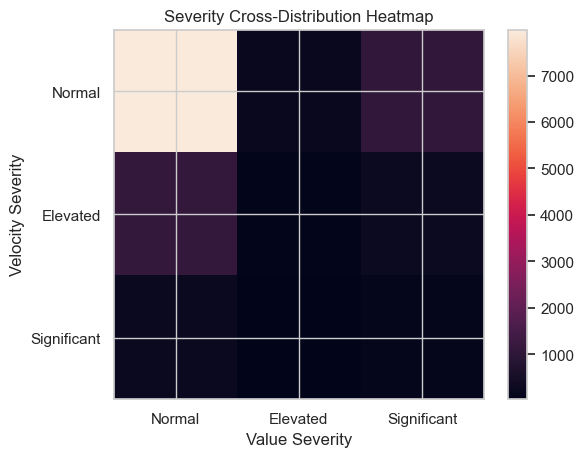


========== SEVERITY SANITY CHECK ==========

Velocity Severity:
                   Count  Percentage (%)
velocity_severity                       
Normal              9310           82.89
Elevated            1486           13.23
Significant          436            3.88

Value Severity:
                Count  Percentage (%)
value_severity                       
Normal           9382           83.53
Significant      1505           13.40
Elevated          345            3.07



In [207]:
# Cross-tab
heatmap_data = pd.crosstab(
    customer_day["velocity_severity"],
    customer_day["value_severity"]
)

# Ensure consistent ordering
order = ["Normal", "Elevated", "Significant"]
heatmap_data = heatmap_data.reindex(index=order, columns=order)

plt.figure()
plt.imshow(heatmap_data)
plt.colorbar()

plt.xticks(range(len(order)), order)
plt.yticks(range(len(order)), order)

plt.xlabel("Value Severity")
plt.ylabel("Velocity Severity")
plt.title("Severity Cross-Distribution Heatmap")

plt.show()


print("\n\033[1m" + "="*10 + " SEVERITY SANITY CHECK " + "="*10 + "\033[0m")

for col in ["velocity_severity", "value_severity"]:
    # Create a summary table: Count and Percentage side-by-side
    summary = pd.concat([
        customer_day[col].value_counts(),
        (customer_day[col].value_counts(normalize=True) * 100).round(2)
    ], axis=1)
    
    summary.columns = ["Count", "Percentage (%)"]
    
    print(f'\n\033[1m{col.replace("_", " ").title()}:\033[0m')
    print(summary)

print("\n\033[1m" + "="*43 + "\033[0m")

### **S3 — 1.2.2.5 Data Preprocessing: Apply auto_red_flag**

### **Auto Red Flag — Rule Trigger**

`auto_red_flag = 1` when ***either*** `velocity_severity = "Significant"` or `value_severity = "Significant"`.

This design ensures consistency across the monitoring pipeline. Since the Significant severity level is defined as `ratio > 2.0`, the auto-red-flag trigger is aligned to the same threshold. As a result, no observation can be classified as Significant without simultaneously generating an operational trigger.

> A misaligned design—for example, if Significant began at `ratio > 2.0` but `auto_red_flag` only triggered at `ratio > 3.0`— would create logical gaps in which a case is labeled Significant but not flagged. The current design avoids this inconsistency.

                                  
```mermaid
flowchart TD
    %% Node A and B create transparent
    A[ ] --- B[ ]
    
    %% arrow from B to C with text in the middle
    B -- " Rule Explanation and Illustration " --> C[ ]

    %% Styling biar kotaknya hilang
    style A fill:none,stroke:none
    style B fill:none,stroke:none
    style C fill:none,stroke:none
```

### **Threshold Consistency Design**

All monitoring thresholds are aligned across the pipeline to prevent logical gaps:

| Metric | Normal | Elevated | Significant | Triggers auto_red_flag |
|---|---|---|---|---|
| **`ratio_velocity`** | ≤ 1.5 | 1.5 – 2.0 | > 2.0 | <span style="background-color:#d5f5d5; padding:4px 8px; border-radius:4px;"> **Yes** </span>|
| **`ratio_value`** | ≤ 1.5 | 1.5 – 2.0 | > 2.0 | <span style="background-color:#d5f5d5; padding:4px 8px; border-radius:4px;"> **Yes** </span> |

**This suspicious level matrix** is designed by adapting the logic of a risk assessment matrix. In a traditional risk matrix, the level is determined by combining ``likelihood`` and ``impact``. Similarly, this suspiciousness matrix combines ``velocity severity`` and ``value severity`` to derive an operational suspiciousness level.

<table border="1" cellpadding="8" style="border-collapse: collapse; text-align: center; font-family: Arial, sans-serif; width: 50%;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="font-weight: bold; width: 25%;">Velocity &darr; / Value &rarr;</th>
      <th style="font-weight: bold; width: 25%;">Normal</th>
      <th style="font-weight: bold; width: 25%;">Elevated</th>
      <th style="font-weight: bold; width: 25%;">Significant</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="font-weight: bold; background-color: #fafafa;">Normal</td>
      <td style="background-color: #c3e6cb; color: #155724;">🟢 Low</td>
      <td style="background-color: #ffeeba; color: #856404;">🟡 Medium</td>
      <td style="background-color: #f5c6cb; color: #721c24; font-weight: bold;">🔴 HIGH</td>
    </tr>
    <tr>
      <td style="font-weight: bold; background-color: #fafafa;">Elevated</td>
      <td style="background-color: #ffeeba; color: #856404;">🟡 Medium</td>
      <td style="background-color: #ffeeba; color: #856404;">🟡 Medium</td>
      <td style="background-color: #f5c6cb; color: #721c24; font-weight: bold;">🔴 HIGH</td>
    </tr>
    <tr>
      <td style="font-weight: bold; background-color: #fafafa;">Significant</td>
      <td style="background-color: #f5c6cb; color: #721c24; font-weight: bold;">🔴 HIGH</td>
      <td style="background-color: #f5c6cb; color: #721c24; font-weight: bold;">🔴 HIGH</td>
      <td style="background-color: #f5c6cb; color: #721c24; font-weight: bold;">🔴 HIGH</td>
    </tr>
  </tbody>
</table>


**Key design decisions:**
- ``auto_red_flag = 1`` and the ***Significant*** severity level are triggered by the same condition — when the ratio is above 2.0. So they basically react to the same threshold.
- ``The map_suspiciousness`` function uses ``auto_red_flag`` as an override mechanism, ensuring that any Significant breach is always classified as ``High``.

### **Rule: High-Severity Ratio Breach**

```mermaid
flowchart LR
    %% Input Section
    In[[Input Metric: Velocity and Value Severity]] --> Matrix{Suspicious Level Matrix}

    %% Matrix Logic
    Matrix -- "Velocity OR Value\nis SIGNIFICANT" --> High[("🔴 HIGH RISK")]
    Matrix -- "Both NORMAL" --> Low[("🟢 LOW RISK")]
    Matrix -- "Other Combinations\n(Elevated)" --> Medium[("🟡 MEDIUM RISK")]

    %% Flagging Logic
    High --> Flag1[Auto Red Flag: 1]
    Medium --> Flag0_M[Auto Red Flag: 0]
    Low --> Flag0_L[Auto Red Flag: 0]
    
    %% Styling
    style High fill:#f8d7da,stroke:#721c24,stroke-width:2px
    style Medium fill:#fff3cd,stroke:#856404,stroke-width:2px
    style Low fill:#d4edda,stroke:#155724,stroke-width:2px

```

- **Condition:** ratio > 2.0  
- **Interpretation:** Significant severity  
- **System Actions:**
  - `auto_red_flag = 1`
  - `suspiciousness_label = "High"` (via `map_suspiciousness` auto-override)

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 20px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 12px rgba(0,0,0,0.03); max-width: 850px;">
    <div style="display: flex; align-items: center; gap: 15px; margin-bottom: 12px;">
        <div style="background: #0f172a; color: #38bdf8; padding: 5px 12px; border-radius: 6px; font-weight: 800; font-size: 0.75em; letter-spacing: 1px;">
            TECHNICAL SCOPE
        </div>
        <div style="height: 1px; flex-grow: 1; background: #f1f5f9;"></div>
    </div>
    <div style="color: #334155; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0;">
            <b>Data Operations</b> functions exclusively as the computational engine. Its scope is restricted to deriving <b>Velocity</b> and <b>Value Severity</b> to trigger the <code>auto_red_flag</code>.
        </p>
        <div style="margin-top: 15px; display: flex; align-items: center; background: #f8fafc; border: 1px solid #f1f5f9; padding: 12px; border-radius: 8px;">
            <span style="font-size: 1.2em; margin-right: 12px;">📂</span>
            <span style="font-size: 0.85em; color: #475569;">
                <b>Output Storage:</b> The resulting indicators are materialized in the <code>customer_day</code> dataset—an aggregated daily view optimized for downstream consumption across all lines.
            </span>
        </div>
    </div>
</div>


In [208]:
# Auto_red_flag (IDENTICAL to AS-IS)
customer_day["auto_red_flag"] = np.where(
    (customer_day["velocity_severity"] == "Significant") |
    (customer_day["value_severity"]    == "Significant"),
    1,
    0
)

# mark unevaluated observations separately
customer_day.loc[
    customer_day["velocity_severity"].isna() &
    customer_day["value_severity"].isna(),
    "auto_red_flag"
] = np.nan

# to assign the non ready baseline transaction
customer_day["is_evaluated"] = customer_day["baseline_txn_count"].notna().astype(int)

# Consistency check
flag_check   = customer_day[customer_day["auto_red_flag"] == 1]
inconsistent = flag_check[
    (flag_check["velocity_severity"] != "Significant") &
    (flag_check["value_severity"]    != "Significant")
]

print(f'auto_red_flag=1 rows   : {len(flag_check):,}')
print(f'Inconsistent rows      : {len(inconsistent)}')
print(f'Result: {"CONSISTENT (Yes)" if len(inconsistent) == 0 else "INCONSISTENT (No)"}')
print()
print("auto_red_flag distribution:")
print(customer_day["auto_red_flag"].value_counts(dropna=False))


auto_red_flag=1 rows   : 1,806
Inconsistent rows      : 0
Result: CONSISTENT (Yes)

auto_red_flag distribution:
auto_red_flag
0.0    9426
1.0    1806
NaN     485
Name: count, dtype: int64


*The *``auto_red_flag``* variable is defined as a binary trigger generated when either velocity severity or value severity reaches the Significant level. **A value of 1 indicates the presence of a significant deviation, while 0 indicates that no significant deviation is detected.** Observations with *unavailable baselines remain NaN*, reflecting that the case is not yet assessable.*

> *Consistency validation confirms that all rows with auto_red_flag = 1 are fully aligned with the severity framework, with zero inconsistent cases detected.*

In [209]:
print("\n\033[1m---------- AS-IS CUSTOMER DAY SUMMARY ----------\n\033[0m")
print(f'Shape             : {customer_day.shape}')
print(f'Unique clients    : {customer_day["client_id"].nunique():,}')
print(f'Date range        : {customer_day["date"].min()} → {customer_day["date"].max()}')
print(f'Baseline formed   : {customer_day["baseline_txn_count"].notna().sum():,}')
print(f'Auto red flag rows: {customer_day["auto_red_flag"].sum():,.0f}')
print(f'Columns           : {customer_day.columns.tolist()}')
display(customer_day.head())



---------- AS-IS CUSTOMER DAY SUMMARY ----------

Shape             : (11717, 14)
Unique clients    : 100
Date range        : 2024-01-01 00:00:00 → 2024-12-31 00:00:00
Baseline formed   : 11,232
Auto red flag rows: 1,806
Columns           : ['client_id', 'date', 'daily_txn_count', 'daily_total_amount', 'daily_avg_amount', 'baseline_txn_count', 'baseline_total_amount', 'baseline_avg_amount', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'is_evaluated']


,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,baseline_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,is_evaluated
0,CUST000150,2024-01-12,1,75.08,75.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,CUST000150,2024-01-16,1,13.22,13.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,CUST000150,2024-01-18,1,16.07,16.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,CUST000150,2024-01-22,1,11.05,11.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,CUST000150,2024-01-25,1,1485.08,1485.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## **S3 — 1.2.3 Output Dataset — 1LoD DataOps**

***Output:** `customer_day`*

***Ouput:** `custpmer_day` — The Golden Source*.

| Feature                        | AS-IS `customer_day`                    |
| ------------------------------ | --------------------------------------- |
| **Contains PII**               | ***Yes*** (client_id, IBANs)            | 
| **Shared to all lines**        | ***No*** — restricted access            |       
| **Demographics included**      | ***No*** — requires separate IT request | 
| **Cross-line join capability** | ***Not possible***                      | 



### **S3 — 1.2.3.1 Output Dataset: DataOps Transformation Output**

***`Raw Data --> DataOps (Ad-hoc Extraction & Aggregation)`***

| Dimension       | IT Input (Raw Transactions)      | DataOps Output (Ad-hoc Extracts / Reports)        | Structural Condition             |
| --------------- | -------------------------------- | ------------------------------------------------- | -------------------------------- |
| **Granularity** | Event-level (transaction)        | Mixed (event subset / partial aggregates)         | Inconsistent (no standard level) |
| **PII**         | Full PII | Partially masked or excluded depending on request | Restricted (privacy-constrained) |
| **Access**      | Restricted (IT-controlled)       | Request-based (manual dependency)                 | Controlled / sequential          |
| **Enrichment**  | Raw transactional attributes     | Limited enrichment (case-specific)                | Minimal / non-standardized       |
| **Consistency** | Source of truth (raw data)       | Varies across requests and use cases              | Structurally inconsistent        |



### **S3 — 1.2.3.2 Data Dimension Gap: IT vs DataOps (TO-BE Golden Source)**

| Dimension           | IT (Raw Transaction Layer)         | DataOps (Ad-hoc Outputs)                         | Gap / Limitation                          |
| ------------------- | ---------------------------------- | ------------------------------------------------ | ----------------------------------------- |
| **Granularity**     | Transaction-level (event-by-event) | Reduced or aggregated (context-dependent)        | Misaligned granularity                    |
| **Data Structure**  | Flat transactional records         | Partial aggregates / filtered datasets           | No standardized analytical structure      |
| **Temporal Detail** | Exact timestamp (date + time)      | Often reduced (e.g., daily summaries)            | Loss of temporal precision or consistency |
| **Feature Type**    | Raw attributes                     | Limited derived metrics (not consistently built) | Incomplete analytical abstraction         |
| **Dependency**      | Independent records                | Reconstructed per request                        | High reconstruction dependency            |
| **Traceability**    | Direct (transaction-level)         | Partial (depends on extracted scope)             | Fragmented traceability                   |
| **PII Exposure**    | Full (sensitive identifiers)       | Restricted or masked                             | Access limitation due to privacy          |
| **Data Fidelity**   | Exact real data                    | Partial or sampled extracts                      | Incomplete representation                 |
| **Join Capability** | Limited across functions           | Difficult to join across LoDs                    | Low interoperability                      |
| **Accessibility**   | Restricted (IT-controlled)         | Request-based access                             | Sequential access bottleneck              |



---

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 900px; margin: auto;">
    <div style="border-bottom: 2px solid #fee2e2; padding-bottom: 15px; margin-bottom: 20px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.4em; margin-right: 12px;">🚧</span>
            <strong style="color: #991b1b; font-size: 1.1em; letter-spacing: 0.5px;">AS-IS ARCHITECTURE: STRUCTURAL BOTTLENECK</strong>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin-bottom: 15px;">
            In the <b>AS-IS architecture</b>, the Data Operations layer is restricted to providing <b>aggregated customer-day outputs</b> only. Detailed transaction-level data—the raw evidence required for deep investigation—remains locked within IT-controlled systems.
        </p>
        <div style="background: #fffafb; border-left: 5px solid #ef4444; padding: 15px; margin: 20px 0;">
            <p style="margin: 0; color: #7f1d1d; font-size: 0.9em;">
                <b>Access Constraint:</b> Retrieval of granular data mandates formal IT requests, creating a <b>sequential, request-driven loop</b>. This structural dependency severely limits data accessibility and introduces significant delays into cross-functional analysis.
            </p>
        </div>
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px; margin-top: 10px;">
            <div style="background: #f1f5f9; padding: 10px; border-radius: 6px; font-size: 0.85em; color: #475569;">
                <b>Status:</b> Siloed Environment
            </div>
            <div style="background: #f1f5f9; padding: 10px; border-radius: 6px; font-size: 0.85em; color: #475569;">
                <b>Workflow:</b> High Latency
            </div>
        </div>
    </div>
</div>


---
# **S3 — 1.3 — 1LoD: Business Operations Department (Monitoring & Escalation)**

***Input:** `customer_day` — from DataOps*

# **1LoD — Business Operations Department**

| Component          | Description                                                                                                                                                                                                   |
| ------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Role**           | Business Operations (Decision Layer — Monitoring, Case Evaluation, and Escalation Handling)                                                                                                                   |
| **Input**          | Aggregated monitoring indicators / partial extracts from DataOps (request-based, non-standardized)                                                                                                            |
| **Output**         | Fragmented operational outputs:<br>• ops_monitoring_view (partial population view)<br>• ops_case_log (escalated cases)<br>• case-specific transaction extracts (upon request)<br>• ad-hoc reports / summaries |
| **Granularity**    | Customer-day (limited view); transaction-level only available after request                                                                                                                                   |
| **Fields**         | Limited analytical indicators + decision attributes (dependent on provided dataset)                                                                                                                           |
| **Processing**     | Rule-based evaluation, threshold checks, and escalation decision; deeper investigation requires additional data request                                                                                       |
| **Purpose**        | Detect suspicious activity and initiate escalation based on limited available data                                                                                                                            |
| **Key Limitation** | No self-service investigation — transaction-level data access requires formal request to DataOps/IT, causing delays and dependency                                                                            |



---
## **S3 — 1.3.1 Input Dataset — 1LoD Business Operations**

In AS-IS, Business Ops receives `customer_day` with restricted columns only — no transaction detail, no demographics.

In [210]:
# Business Ops input — aggregate indicators only

customer_day_operational = customer_day.copy()

print("\033[1m----- TO-BE BUSINESS OPERATIONS INPUT -----\033[0m")

print(f"customer transaction per day: {customer_day_operational.shape}")
print()
print("customer transaction per day columns:")
print(customer_day_operational.columns.tolist())

print("\n\033[1m----- FULL CUSTOMER TRANSACTION PER DAY DATASET -----\033[0m")
display(customer_day_operational.head(10))


----- TO-BE BUSINESS OPERATIONS INPUT -----
customer transaction per day: (11717, 14)

customer transaction per day columns:
['client_id', 'date', 'daily_txn_count', 'daily_total_amount', 'daily_avg_amount', 'baseline_txn_count', 'baseline_total_amount', 'baseline_avg_amount', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'is_evaluated']

----- FULL CUSTOMER TRANSACTION PER DAY DATASET -----


,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,baseline_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,is_evaluated
0,CUST000150,2024-01-12,1,75.08,75.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,CUST000150,2024-01-16,1,13.22,13.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,CUST000150,2024-01-18,1,16.07,16.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,CUST000150,2024-01-22,1,11.05,11.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,CUST000150,2024-01-25,1,1485.08,1485.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,CUST000150,2024-02-12,1,90.64,90.64,1.0,320.100000,320.100000,1.0,0.2832,Normal,Normal,0.0,1
6,CUST000150,2024-02-16,1,14.32,14.32,1.0,281.856667,281.856667,1.0,0.0508,Normal,Normal,0.0,1
7,CUST000150,2024-02-20,1,10.70,10.70,1.0,243.637143,243.637143,1.0,0.0439,Normal,Normal,0.0,1
8,CUST000150,2024-02-23,1,1385.76,1385.76,1.0,214.520000,214.520000,1.0,6.4598,Normal,Significant,1.0,1
9,CUST000150,2024-03-12,1,69.48,69.48,1.0,344.657778,344.657778,1.0,0.2016,Normal,Normal,0.0,1


---
## **S3 — 1.3.2 Data Processing — 1LoD Business Operations**

Once the risk assessment logic has been calculated on the data operations layer, Business Operations reviews the output of `customer_day` and applies the suspiciousness labeling and disposition logic.

### **Data Processing: The Investigation Cycle: From Signal to Resolution Action**

```mermaid

flowchart LR
    CD[Customer_day Indicators] --> Matrix{Suspicious Matrix}
    Matrix -- "Flag 0" --> NE[Non-Escalation]
    Matrix -- "Flag 1" --> Esc[Escalation]
    Esc --> OCR[Ops Case Review]
    OCR --> Trigger{Request Detailed Data?}
    Trigger <-->|Manual IT Request\n1-5 day lag| IT[(Raw Transaction Data\nFull PII Access)]
    Trigger --> Result[Investigation Result]
    Result --> Link[Transaction Case Linked]
    NE --> AT[[Audit Trail]]
    Link --> AT
    style Esc fill:#f8d7da,stroke:#721c24,stroke-width:2px
    style NE fill:#d4edda,stroke:#155724
    style IT fill:#fff3cd,stroke:#856404
    style AT fill:#f3e5f5,stroke:#4a148c,stroke-width:2px

```

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 900px; margin: auto;">
    <div style="border-bottom: 2px solid #cbd5e1; padding-bottom: 15px; margin-bottom: 20px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.4em; margin-right: 12px;">🔄</span>
            <strong style="color: #334155; font-size: 1.1em; letter-spacing: 0.5px;">AS-IS SIMULATION: RECURSIVE REQUEST CYCLES</strong>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin-bottom: 15px;">
            In the <b>AS-IS simulation</b>, the transition from signal detection to deep investigation is hindered by restricted access. Business Operations is forced into a <b>formalized dependency</b>, requiring manual intervention from IT or Data Operations to retrieve granular transaction evidence.
        </p>
        <div style="background: #fff7ed; border-left: 5px solid #f97316; padding: 15px; margin: 20px 0; border-radius: 4px;">
            <p style="margin: 0; color: #9a3412; font-size: 0.9em; font-weight: 500;">
                <b>The "Insufficient Data" Loop:</b> When initial data drops fail to provide enough context, repeated requests are initiated. This creates <b>recurrent request cycles</b>, ballooning the workload for both the investigators and the data provisioning teams.
            </p>
        </div>
        <div style="display: flex; gap: 10px; flex-wrap: wrap; margin-top: 15px;">
            <span style="background: #fee2e2; color: #991b1b; padding: 4px 12px; border-radius: 20px; font-size: 0.75em; font-weight: bold;">Structural Bottleneck</span>
            <span style="background: #fee2e2; color: #991b1b; padding: 4px 12px; border-radius: 20px; font-size: 0.75em; font-weight: bold;">Increased Operational Workload</span>
            <span style="background: #fee2e2; color: #991b1b; padding: 4px 12px; border-radius: 20px; font-size: 0.75em; font-weight: bold;">High Latency Escalation</span>
        </div>
    </div>
</div>

### **S3 — 1.3.2.1 Data Processing: Suspiciousness Labeling** *(map_suspiciousness)*

In [211]:
# Suspiciousness labeling — IDENTICAL function map to AS-IS
# Priority: auto_flag=1 -> High -> Significant -> Elevated -> Normal

def map_suspiciousness(velocity_group, value_group, auto_flag=np.nan):
    if auto_flag == 1:
        return "High"
    elif velocity_group == "Significant" or value_group == "Significant":
        return "High"
    elif velocity_group == "Elevated" or value_group == "Elevated":
        return "Medium"
    elif velocity_group == "Normal" and value_group == "Normal":
        return "Low"
    else:
        return np.nan


customer_day_operational["suspiciousness_label"] = customer_day_operational.apply(
    lambda r: map_suspiciousness(
        r["velocity_severity"],
        r["value_severity"],
        r["auto_red_flag"] # auto_red_flag now participates in labeling
    ),
    axis=1
)

print("\n\033[1m---------- SANITY CHECK AFTER SUSPICIOUSNESS LABELING PROCESS----------\033[0m")

# Check 1: Significant severity must always be labeled High
significant_not_high = customer_day_operational[
    (
        (customer_day_operational["velocity_severity"] == "Significant") |
        (customer_day_operational["value_severity"] == "Significant")
    ) &
    (customer_day_operational["suspiciousness_label"] != "High")
]

print(f"\nRows with Significant severity but not labeled High: {len(significant_not_high)}")

# Check 2: auto_red_flag = 1 must always be High
flag_not_high = customer_day_operational[
    (customer_day_operational["auto_red_flag"] == 1) &
    (customer_day_operational["suspiciousness_label"] != "High")
]

print(f"Rows with auto_red_flag=1 but not labeled High: {len(flag_not_high)}")

# Summary
print("\n---------- Suspiciousness label distribution: ----------")
print(customer_day_operational["suspiciousness_label"].value_counts(dropna=False))

print("\n---------- auto_red_flag=1 -> suspiciousness_label: ----------")
print(
    customer_day_operational[customer_day_operational["auto_red_flag"] == 1]["suspiciousness_label"]
    .value_counts(dropna=False)
)


---------- SANITY CHECK AFTER SUSPICIOUSNESS LABELING PROCESS----------

Rows with Significant severity but not labeled High: 0
Rows with auto_red_flag=1 but not labeled High: 0

---------- Suspiciousness label distribution: ----------
suspiciousness_label
Low       7992
High      1806
Medium    1434
NaN        485
Name: count, dtype: int64

---------- auto_red_flag=1 -> suspiciousness_label: ----------
suspiciousness_label
High    1806
Name: count, dtype: int64


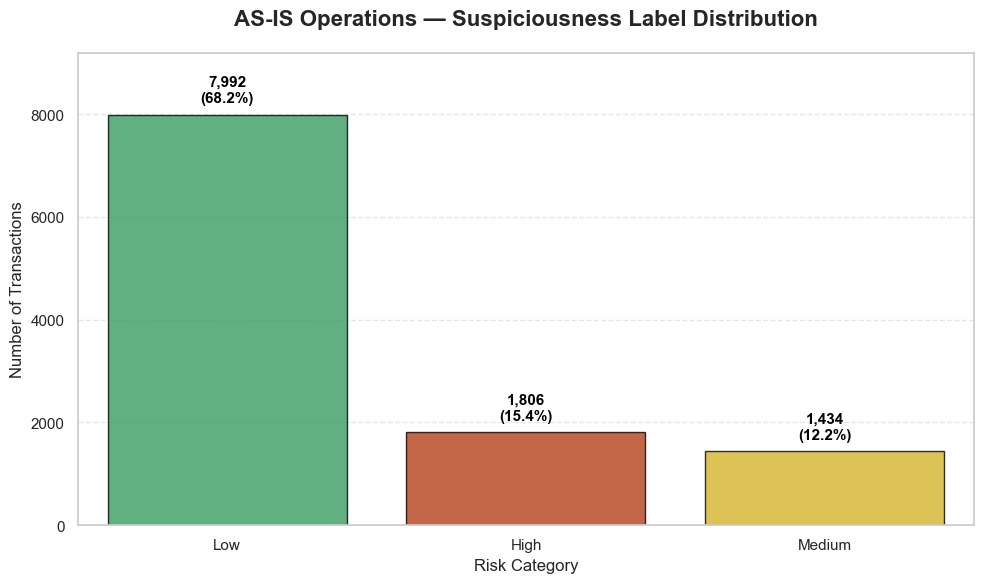

In [212]:
# Visualize suspiciousness distribution

# Pre-calculate data
label_counts = (customer_day_operational["suspiciousness_label"].value_counts(dropna=False)
                .reset_index(name="Count")
                .rename(columns={"index": "Label"})
                .sort_values("Count", ascending=False))

#specify the name
label_counts.columns = ["Label", "Count"]

total = label_counts["Count"].sum()

# Define standard Risk colors
color_palette = {"High": "#cc3300",   # Bold Red
                 "Medium": "#f1c40f", # Payday Yellow
                 "Low": "#27ae60",    # Green
                 np.nan: "grey"}      # Grey for NaN if present

# Create Plot
plt.figure(figsize=(10, 6))

# Map colors directly using "hue" and "palette"
ax = sns.barplot(data=label_counts, 
                 x="Label", 
                 y="Count", 
                 hue="Label", 
                 palette=color_palette, 
                 legend=False, 
                 edgecolor="black", 
                 alpha=0.8)         #a little bit transparant

# Annotations
for p in ax.patches:
    height = p.get_height()
    percentage = f"{(height / total * 100):.1f}%"
    count = int(height)
    
    ax.annotate(f"{count:,}\n({percentage})", 
                (p.get_x() + p.get_width() / 2., height), 
                ha="center", 
                va="bottom", 
                fontsize=11, 
                fontweight="bold", 
                color="black", 
                xytext=(0, 7), # Sedikit offset ke atas
                textcoords="offset points")

# 5. Styling & Labels
plt.title("AS-IS Operations — Suspiciousness Label Distribution", 
          fontsize=16, 
          fontweight="bold", 
          pad=20)

plt.xlabel("Risk Category", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

plt.ylim(0, label_counts["Count"].max() * 1.15) 

plt.grid(axis="y", linestyle="--", alpha=0.5) # Grid halus
plt.tight_layout()
plt.show()

*The distribution reflects a balanced detection mechanism, capturing varying levels of behavioral deviation while maintaining consistency between computational signals and operational decision logic. It confirms that the system is neither overly conservative nor overly sensitive, maintaining an effective balance between detection capability and operational feasibility.*

---
<div style="background-color: #f8fafc; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 900px; margin: auto;">
    <div style="border-bottom: 2px solid #0f172a; padding-bottom: 15px; margin-bottom: 20px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.4em; margin-right: 12px;">⚖️</span>
            <strong style="color: #0f172a; font-size: 1.1em; letter-spacing: 0.5px;">BASELINE INTEGRITY & LOGIC CONSISTENCY</strong>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin: 0;">
            To ensure a rigorous and valid comparison, <b>Business Operations applies identical suspiciousness labeling and disposition logic</b> to the <code>customer_day</code> output across both AS-IS and TO-BE scenarios. 
        </p>
        <div style="background: #f0fdf4; border-left: 5px solid #16a34a; padding: 15px; margin: 20px 0; border-radius: 4px;">
            <p style="margin: 0; color: #14532d; font-size: 0.9em; font-weight: 500;">
                <b>Experimental Control:</b> By standardizing the decision-making criteria, this study ensures that all observed performance gains are attributed solely to <b>architectural redesign and data accessibility</b>, rather than variations in human judgment or risk tolerance.
            </p>
        </div>
        <div style="display: flex; gap: 10px; flex-wrap: wrap; margin-top: 10px;">
            <span style="background: #f1f5f9; color: #475569; padding: 4px 12px; border-radius: 4px; font-size: 0.75em; font-weight: bold; border: 1px solid #e2e8f0;">Apples-to-Apples Comparison</span>
            <span style="background: #f1f5f9; color: #475569; padding: 4px 12px; border-radius: 4px; font-size: 0.75em; font-weight: bold; border: 1px solid #e2e8f0;">Decision Logic Parity</span>
            <span style="background: #f1f5f9; color: #475569; padding: 4px 12px; border-radius: 4px; font-size: 0.75em; font-weight: bold; border: 1px solid #e2e8f0;">Outcome Comparability</span>
        </div>
    </div>
</div>

---
### **S3 — 1.3.2.2 Data Processing: Disposition Process: Governance-Oriented Rule-Based Approach**
---

div style="background-color: #fcfcfc; border-left: 6px solid #455a64; padding: 20px; border-radius: 8px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 2px 5px rgba(0,0,0,0.08);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">🚦</span>
        <strong style="color: #263238; font-size: 1.15em; letter-spacing: 0.5px;">OPERATIONAL TRIAGE FRAMEWORK</strong>
    </div>
    <div style="color: #37474f; line-height: 1.6;">
        <p style="margin-bottom: 12px; font-size: 0.95em; color: #546e7a;">
            Final dispositions are executed via a deterministic SOP based on the risk-level classification:
        </p>
        <div style="display: flex; align-items: center; margin-bottom: 8px;">
            <span style="min-width: 25px;">🔴</span>
            <b style="color: #c62828; min-width: 80px;">HIGH</b> 
            <span style="margin: 0 10px; color: #b0bec5;">➔</span> 
            <span style="background: #ffebee; color: #b71c1c; padding: 2px 8px; border-radius: 4px; font-weight: bold; font-size: 0.9em;">ESCALATE</span>
            <i style="margin-left: 10px; color: #78909c; font-size: 0.9em;">Immediate priority for senior investigation.</i>
        </div>
        <div style="display: flex; align-items: center; margin-bottom: 8px;">
            <span style="min-width: 25px;">🟡</span>
            <b style="color: #f9a825; min-width: 80px;">MEDIUM</b> 
            <span style="margin: 0 10px; color: #b0bec5;">➔</span> 
            <span style="background: #fff9c4; color: #f57f17; padding: 2px 8px; border-radius: 4px; font-weight: bold; font-size: 0.9em;">UNDER REVIEW</span>
            <i style="margin-left: 10px; color: #78909c; font-size: 0.9em;">Requires further assessment by the team.</i>
        </div>
        <div style="display: flex; align-items: center;">
            <span style="min-width: 25px;">🟢</span>
            <b style="color: #2e7d32; min-width: 80px;">LOW</b> 
            <span style="margin: 0 10px; color: #b0bec5;">➔</span> 
            <span style="background: #e8f5e9; color: #1b5e20; padding: 2px 8px; border-radius: 4px; font-weight: bold; font-size: 0.9em;">DISMISS</span>
            <i style="margin-left: 10px; color: #78909c; font-size: 0.9em;">No further action needed; case closed.</i>
        </div>
    </div>
</div>

---

**Why we do this:**

This structure ensures a clear Separation of Duties:

* **Data Operations** focuses on the technical "math" (calculating risk indicators).
* **Business Operations** focuses on the "judgment" (deciding the final action).This approach guarantees that every alert is handled consistently, removing guesswork while maintaining a high standard of governance.
---


In [213]:
## **Disposition Process

def assign_disposition(label):
    if pd.isna(label):         return np.nan
    elif label == "High":      return "Escalate"
    elif label == "Medium":    return "Under review"
    elif label == "Low":       return "Dismiss"
    else:                      return np.nan

customer_day_operational["ops_disposition"] = (
    customer_day_operational["suspiciousness_label"].apply(assign_disposition)
)

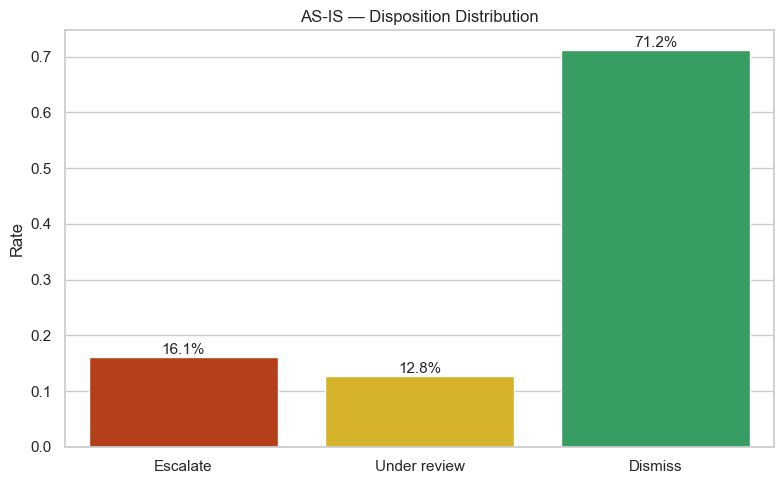


----- Disposition distribution: -----
ops_disposition
Dismiss         7992
Escalate        1806
Under review    1434
NaN              485
Name: count, dtype: int64


In [214]:
# Visualize disposition

total_cases = customer_day_operational["ops_disposition"].notna().sum()
disposition_counts = customer_day_operational["ops_disposition"].value_counts()

labels  = ["Escalate", "Under review", "Dismiss"]
rates   = [disposition_counts.get(l,0)/total_cases for l in labels]

plt.figure(figsize=(8, 5))
colors  = ["#cc3300", "#f1c40f", "#27ae60"]
ax = sns.barplot(x=labels, y=rates, hue=labels, legend=False, palette=colors)
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%", 
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
    
plt.title("AS-IS — Disposition Distribution")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()


print("\n\033[1m----- Disposition distribution: -----\033[0m")
print(customer_day_operational["ops_disposition"].value_counts(dropna=False))


*The AS-IS distribution shows a three-tier triage where ~15.8% cases are escalated, ~12.4% reviewed, and ~71.8% dismissed. Most ***non-critical cases*** are filtered early, improving efficiency. The `Under Review` layer adds a buffer for contextual checks and reduces false positives. This keeps escalation focused on truly significant cases. Overall, it reflects a balanced and operationally effective monitoring design.*

---
### **S3 — 1.3.2.3 Data Processing: Case History / Log (Tracing the Disposition Process)**
---

*The case log serves as a formal record to trace the escalation process when a suspicious observation is identified.*

> Each case is assigned a unique case_id, which enables Business Operations to consistently reference the affected customer-day during further investigation. When a case is escalated, detailed transaction-level information is required to support deeper analysis. 

In the AS-IS model, escalated cases requiring transaction-level detail trigger formal data requests to IT or Data Operations. Due to limited direct access, Business Operations must rely on repeated requests to perform drill-down analysis. This creates a strong dependency on cross-line data reconstruction, resulting in delays and disrupting the timeliness of the investigation process.

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 900px; margin: auto;">
    <div style="border-bottom: 2px solid #fee2e2; padding-bottom: 15px; margin-bottom: 20px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.4em; margin-right: 12px;">🔐</span>
            <strong style="color: #991b1b; font-size: 1.1em; letter-spacing: 0.5px;">AS-IS ARCHITECTURE: PRIVACY-DRIVEN FRICTION</strong>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin-bottom: 15px;">
            In the <b>AS-IS architecture</b>, privacy-driven access restrictions enforce a rigid <b>permission-based investigation model</b>. Because transaction-level PII is restricted, investigators are siloed from the data they need to validate risk signals.
        </p>
        <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 10px; margin: 20px 0;">
            <div style="background: #fffafb; border: 1px solid #fecaca; padding: 12px; border-radius: 8px; text-align: center;">
                <b style="color: #b91c1c; display: block; font-size: 0.8em;">Recursive Cycles</b>
                <span style="font-size: 0.75em; color: #7f1d1d;">Repetitive IT requests and wait times.</span>
            </div>
            <div style="background: #fffafb; border: 1px solid #fecaca; padding: 12px; border-radius: 8px; text-align: center;">
                <b style="color: #b91c1c; display: block; font-size: 0.8em;">Limited Depth</b>
                <span style="font-size: 0.75em; color: #7f1d1d;">Analysis restricted to daily aggregates.</span>
            </div>
            <div style="background: #fffafb; border: 1px solid #fecaca; padding: 12px; border-radius: 8px; text-align: center;">
                <b style="color: #b91c1c; display: block; font-size: 0.8em;">Delayed Response</b>
                <span style="font-size: 0.75em; color: #7f1d1d;">Risk signals grow cold during retrieval.</span>
            </div>
        </div>
        <p style="margin-top: 10px; font-style: italic; color: #64748b; font-size: 0.9em; text-align: center; border-top: 1px solid #f1f5f9; padding-top: 15px;">
            "The AS-IS model forces a trade-off where <b>data privacy</b> directly compromises <b>operational agility</b>."
        </p>
    </div>
</div>


In [215]:
# Rules documentation 

def rules(row):
    parts = []
    
    # Readiness layer
    if row.get("is_evaluated") == 0:
        return "Not evaluated (baseline not ready)"
        
    # auto flag trigger rules
    if row.get("auto_red_flag") == 1:
        parts.append("auto_red_flag=1 (Significant severity triggered)")

    # velocity severity rules
    if row.get("velocity_severity") == "Significant":
        parts.append("velocity_severity=Significant (ratio_velocity > 2.0)")
    elif row.get("velocity_severity") == "Elevated":
        parts.append("velocity_severity=Elevated (1.5 < ratio_velocity ≤ 2.0)")
    elif row.get("velocity_severity") == "Normal":
        parts.append("velocity_severity=Normal (ratio_velocity ≤ 1.5)")

    
    # value severity rules
    if row.get("value_severity") == "Significant":
        parts.append("value_severity=Significant (ratio_value > 2.0)")
    elif row.get("value_severity") == "Elevated":
        parts.append("value_severity=Elevated (1.5 < ratio_value ≤ 2.0)")
    elif row.get("value_severity") == "Normal":
        parts.append("value_severity=Normal (ratio_value ≤ 1.5)")


    # final suspiciousness label
    if row.get("suspiciousness_label") in ["High", "Medium", "Low"]:
        parts.append(f'suspiciousness_label={row["suspiciousness_label"]}')
        
    return "; ".join(parts) if parts else "No trigger (baseline not ready or Normal range)"

# Ensure date is datetime
customer_day_operational["date"]     = pd.to_datetime(customer_day_operational["date"])
customer_day_operational["ops_rules"] = customer_day_operational.apply(rules, axis=1)

# CASE CREATION LOGIC
# High = formal case
# Medium = under review only (no formal case)
# Low = no case

case_candidates = customer_day_operational[
    customer_day_operational["suspiciousness_label"] == "High"
].copy()

case_candidates["case_id"] = (
    "CASE_" +
    case_candidates["client_id"].astype(str) + "_" +
    case_candidates["date"].dt.strftime("%Y%m%d")
)
case_candidates["case_created_at"] = pd.Timestamp.now()

print(f"Case candidates: {len(case_candidates):,}")


Case candidates: 1,806


---
### **S3 — 1.3.2.4 Data Processing: Case Log Creation**
---
***Output:** `ops_case_log`, `customer_day_operational`*

*Creates a formal case log dataset for traceability and audit purposes*

This process creates a formal case log dataset that captures all evaluated customer-day observations resulting from the monitoring process, including their risk classification and operational disposition. The dataset supports traceability and serves as an audit trail for cases that are dismissed, reviewed, or escalated.


<div style="background-color: #f8f9fa; border-left: 6px solid #6c757d; padding: 18px; border-radius: 8px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">📂</span>
        <strong style="color: #343a40; font-size: 1.1em; letter-spacing: 0.3px;">CASE LOG DATASET</strong>
    </div>
    <p style="margin: 0; color: #495057; line-height: 1.6;">
        This dataset serves as the <b>central repository</b> for all evaluated customer-day observations. It captures the end-to-end output of the Business Operations monitoring process, ensuring every risk assessment and final disposition is documented for <b>auditability and traceability</b>.
    </p>
</div>

In [216]:
# Formal case log

ops_case_log = case_candidates[[
    "case_id", "case_created_at", "client_id", "date",
    "suspiciousness_label", "ops_disposition",
    "ratio_velocity", "ratio_value",
    "velocity_severity", "value_severity",
    "auto_red_flag", "ops_rules"
]].copy()


# case candidates = only High risk
case_candidates = customer_day_operational[
    customer_day_operational["suspiciousness_label"] == "High"
].copy()

print("\n\033[1m----- SANITY CHECK CASE LOG DATASET -----\033[0m\n")

print(f"ops_case_log shape: {ops_case_log.shape}")
print()
print("\nops_case_log columns:\n")
print(ops_case_log.columns.tolist())

print("\n\033[1m----- CASE LOG DATASET -----\033[0m")
display(ops_case_log.head())



----- SANITY CHECK CASE LOG DATASET -----

ops_case_log shape: (1806, 12)


ops_case_log columns:

['case_id', 'case_created_at', 'client_id', 'date', 'suspiciousness_label', 'ops_disposition', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'ops_rules']

----- CASE LOG DATASET -----


,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules
8,CASE_CUST000150_20240223,2026-05-15 13:11:08.670554,CUST000150,2024-02-23,High,Escalate,1.0000,6.4598,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
11,CASE_CUST000150_20240325,2026-05-15 13:11:08.670554,CUST000150,2024-03-25,High,Escalate,0.9167,4.7870,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
15,CASE_CUST000150_20240425,2026-05-15 13:11:08.670554,CUST000150,2024-04-25,High,Escalate,0.9375,4.6865,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
19,CASE_CUST000150_20240524,2026-05-15 13:11:08.670554,CUST000150,2024-05-24,High,Escalate,0.9500,4.4549,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
22,CASE_CUST000150_20240625,2026-05-15 13:11:08.670554,CUST000150,2024-06-25,High,Escalate,0.9565,4.1700,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...


In [217]:
# customer_day_operational — full monitoring dataset

ops_log = customer_day_operational[[
    "client_id", "date",
    "suspiciousness_label", "ops_disposition",
    "ratio_velocity", "ratio_value",
    "velocity_severity", "value_severity",
    "auto_red_flag", "ops_rules"
]].copy()


print("\n\033[1m----- SANITY CHECK OPERATIONAL (FULL OPERATIONAL LOG) DATASET -----\033[0m\n")

print(f'customer_day_operational shape: {customer_day_operational.shape}')
print()
print("\ncustomer_day_operational columns:\n")
print(customer_day_operational.columns.tolist())

print("\n\033[1m----- FULL OPERATIONAL LOGDATASET -----\033[0m")
display(customer_day_operational.head())



----- SANITY CHECK OPERATIONAL (FULL OPERATIONAL LOG) DATASET -----

customer_day_operational shape: (11717, 17)


customer_day_operational columns:

['client_id', 'date', 'daily_txn_count', 'daily_total_amount', 'daily_avg_amount', 'baseline_txn_count', 'baseline_total_amount', 'baseline_avg_amount', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'is_evaluated', 'suspiciousness_label', 'ops_disposition', 'ops_rules']

----- FULL OPERATIONAL LOGDATASET -----


,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,baseline_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,is_evaluated,suspiciousness_label,ops_disposition,ops_rules
0,CUST000150,2024-01-12,1,75.08,75.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)
1,CUST000150,2024-01-16,1,13.22,13.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)
2,CUST000150,2024-01-18,1,16.07,16.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)
3,CUST000150,2024-01-22,1,11.05,11.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)
4,CUST000150,2024-01-25,1,1485.08,1485.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)


---
### **S3 — 1.3.2.5 Data Processing: Case Registry Creation**
---
***Output:** `customer_day_case_registry`*

*Creates a formal case registry dataset for monitoring purpose*

The case registry links monitoring observations with case creation outcomes to support traceability between customer-day signals and formal case handling. By attaching `case_id` to monitoring records, the dataset shows which observations result in case creation and which do not. This provides a monitoring bridge between continuous signal detection and discrete case management.


<div style="background-color: #f4f7f6; border-left: 6px solid #2d3436; padding: 18px; border-radius: 8px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">🔗</span>
        <strong style="color: #2d3436; font-size: 1.1em; letter-spacing: 0.3px;">CASE REGISTRY</strong>
    </div>
    <p style="margin: 0; color: #4b4b4b; line-height: 1.6;">
        The <b>Case Registry</b> serves full <b>traceability</b> by mapping daily customer-level signals to formal case handling, effectively reconciling <b>monitoring outputs</b> with <b>case management actions</b>.
    </p>
</div>

In [218]:
# Monitoring-to-case bridge

customer_day_case_registry = customer_day_operational.merge(
    ops_case_log[["case_id", "client_id", "date"]],
    on=["client_id", "date"],
    how="left"
)
print(f'Case Registry Shape: {customer_day_case_registry.shape}')

# Flag whether an observation results in formal case creation
customer_day_case_registry['is_case_created'] = (
    customer_day_case_registry['case_id'].notna().astype(int)
)


# Medium-risk observations are monitored more closely, but do not become formal cases
customer_day_case_registry["is_under_review"] = (
    (customer_day_case_registry["suspiciousness_label"] == "Medium").astype(int)
)

customer_day_case_registry["monitoring_status"] = np.select(
    [
        customer_day_case_registry["is_evaluated"] == 0,
        customer_day_case_registry["is_case_created"] == 1,
        customer_day_case_registry["is_under_review"] == 1
    ],
    [
        "Not Evaluated",
        "Case Created",
        "Under Review"
    ],
    default="Normal"
)


print("\n\033[1m----- SANITY CHECK CASE REGISTRY DATASET -----\033[0m\n")
print(f'Case registry shape whether an observation resulting case creation: {customer_day_case_registry.shape}')
print()
print('\nops_case_log columns:\n')
print(customer_day_case_registry.columns.tolist())


print("\n\033[1m----- CASE REGISTRY DATASET -----\033[0m")
display(customer_day_case_registry.head())


Case Registry Shape: (11717, 18)

----- SANITY CHECK CASE REGISTRY DATASET -----

Case registry shape whether an observation resulting case creation: (11717, 21)


ops_case_log columns:

['client_id', 'date', 'daily_txn_count', 'daily_total_amount', 'daily_avg_amount', 'baseline_txn_count', 'baseline_total_amount', 'baseline_avg_amount', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'is_evaluated', 'suspiciousness_label', 'ops_disposition', 'ops_rules', 'case_id', 'is_case_created', 'is_under_review', 'monitoring_status']

----- CASE REGISTRY DATASET -----


,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,baseline_avg_amount,ratio_velocity,ratio_value,...,value_severity,auto_red_flag,is_evaluated,suspiciousness_label,ops_disposition,ops_rules,case_id,is_case_created,is_under_review,monitoring_status
0,CUST000150,2024-01-12,1,75.08,75.08,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),NaN,0,0,Not Evaluated
1,CUST000150,2024-01-16,1,13.22,13.22,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),NaN,0,0,Not Evaluated
2,CUST000150,2024-01-18,1,16.07,16.07,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),NaN,0,0,Not Evaluated
3,CUST000150,2024-01-22,1,11.05,11.05,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),NaN,0,0,Not Evaluated
4,CUST000150,2024-01-25,1,1485.08,1485.08,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),NaN,0,0,Not Evaluated


*Observations without sufficient historical baseline are not evaluated and therefore do not proceed to risk classification or case creation. These records remain in the registry with a `Not evaluated` status, ensuring completeness of monitoring while avoiding premature decision-making.*

---
### **S3 — 1.3.2.6 Data Processing: Monitoring-to-Case Traceability Analysis**
---
***Output:** `customer_day_case_registry` and `dashboard_summary*

*For evaluating how monitoring outputs translate into case creation decisions across suspiciousness levels*

This analysis evaluates how monitoring outputs translate into case creation decisions across suspiciousness levels. It verifies whether high, medium, and low-risk observations are handled consistently according to the intended triage logic.


<div style="background-color: #fcfcfc; border-left: 6px solid #17a2b8; padding: 20px; border-radius: 8px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 2px 5px rgba(0,0,0,0.08);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">📊</span>
        <strong style="color: #087990; font-size: 1.1em; letter-spacing: 0.3px;">ANALYTICAL & OPERATIONAL INSIGHTS</strong>
    </div>
    <p style="margin: 0; color: #333; line-height: 1.6;">
        Leveraging the <b>Case Registry</b>, this dashboard provides dual-layer visibility:
    </p>
    <ul style="margin: 10px 0 0 0; padding-left: 20px; color: #444; line-height: 1.6;">
        <li><b>Analytical View:</b> Measures the <b>selectivity</b> of the escalation process, ensuring high-fidelity risk detection.</li>
        <li><b>Operational View:</b> Evaluates the <b>effectiveness of triage</b>, highlighting the efficiency of final dispositions and resource allocation.</li>
    </ul>
</div>

In [219]:
# monitoring summary

total_n = len(customer_day_case_registry)

# analytical view
risk_summary = (
    customer_day_case_registry
    .groupby("suspiciousness_label", dropna=False)["is_case_created"]
    .agg(total_alerts="count", cases_created="sum")
    .reset_index()
)

risk_summary["case_rate"]      = risk_summary["cases_created"] / risk_summary["total_alerts"]
risk_summary["share_of_total"] = risk_summary["total_alerts"] / total_n

# operational view
status_summary = (
    customer_day_case_registry["monitoring_status"]
    .value_counts(dropna=False)
    .rename_axis("monitoring_status")
    .reset_index(name="count")
)

status_summary["share_of_total"] = status_summary["count"] / total_n

print("\n\033[1m----- COMBINED MONITORING SUMMARY: ANALYTICAL VIEW -----\033[0m")
print(risk_summary)

print("\n\033[1m----- COMBINED MONITORING SUMMARY: OPERATIONAL VIEW -----\033[0m")
print(status_summary)



----- COMBINED MONITORING SUMMARY: ANALYTICAL VIEW -----
  suspiciousness_label  total_alerts  cases_created  case_rate  share_of_total
0                 High          1806           1806        1.0        0.154135
1                  Low          7992              0        0.0        0.682086
2               Medium          1434              0        0.0        0.122386
3                  NaN           485              0        0.0        0.041393

----- COMBINED MONITORING SUMMARY: OPERATIONAL VIEW -----
  monitoring_status  count  share_of_total
0            Normal   7992        0.682086
1      Case Created   1806        0.154135
2      Under Review   1434        0.122386
3     Not Evaluated    485        0.041393


---
### **Dashboard Monitoring**
---

In [220]:
# Dashboard monitoring

dashboard_summary = pd.DataFrame({
    "metric_group": [
        "Risk Label", "Risk Label", "Risk Label",
        "Monitoring Status", "Monitoring Status", "Monitoring Status", "Monitoring Status"
    ],
    "category": [
        "High", "Medium", "Low",
        "Case Created", "Under Review", "Normal", "Not Evaluated"
    ],
    "count": [
        risk_summary.loc[risk_summary["suspiciousness_label"] == "High", "total_alerts"].sum(),
        risk_summary.loc[risk_summary["suspiciousness_label"] == "Medium", "total_alerts"].sum(),
        risk_summary.loc[risk_summary["suspiciousness_label"] == "Low", "total_alerts"].sum(),
        status_summary.loc[status_summary["monitoring_status"] == "Case Created", "count"].sum(),
        status_summary.loc[status_summary["monitoring_status"] == "Under Review", "count"].sum(),
        status_summary.loc[status_summary["monitoring_status"] == "Normal", "count"].sum(),
        status_summary.loc[status_summary["monitoring_status"] == "Not Evaluated", "count"].sum(),
    ]
})


dashboard_summary["percentage"] = (dashboard_summary["count"] / total_n * 100).round(2)

print("\n\033[1m----- AS-IS MONITORING DASHBOARD SUMMARY -----\033[0m")
print(dashboard_summary)




----- AS-IS MONITORING DASHBOARD SUMMARY -----
        metric_group       category  count  percentage
0         Risk Label           High   1806       15.41
1         Risk Label         Medium   1434       12.24
2         Risk Label            Low   7992       68.21
3  Monitoring Status   Case Created   1806       15.41
4  Monitoring Status   Under Review   1434       12.24
5  Monitoring Status         Normal   7992       68.21
6  Monitoring Status  Not Evaluated    485        4.14


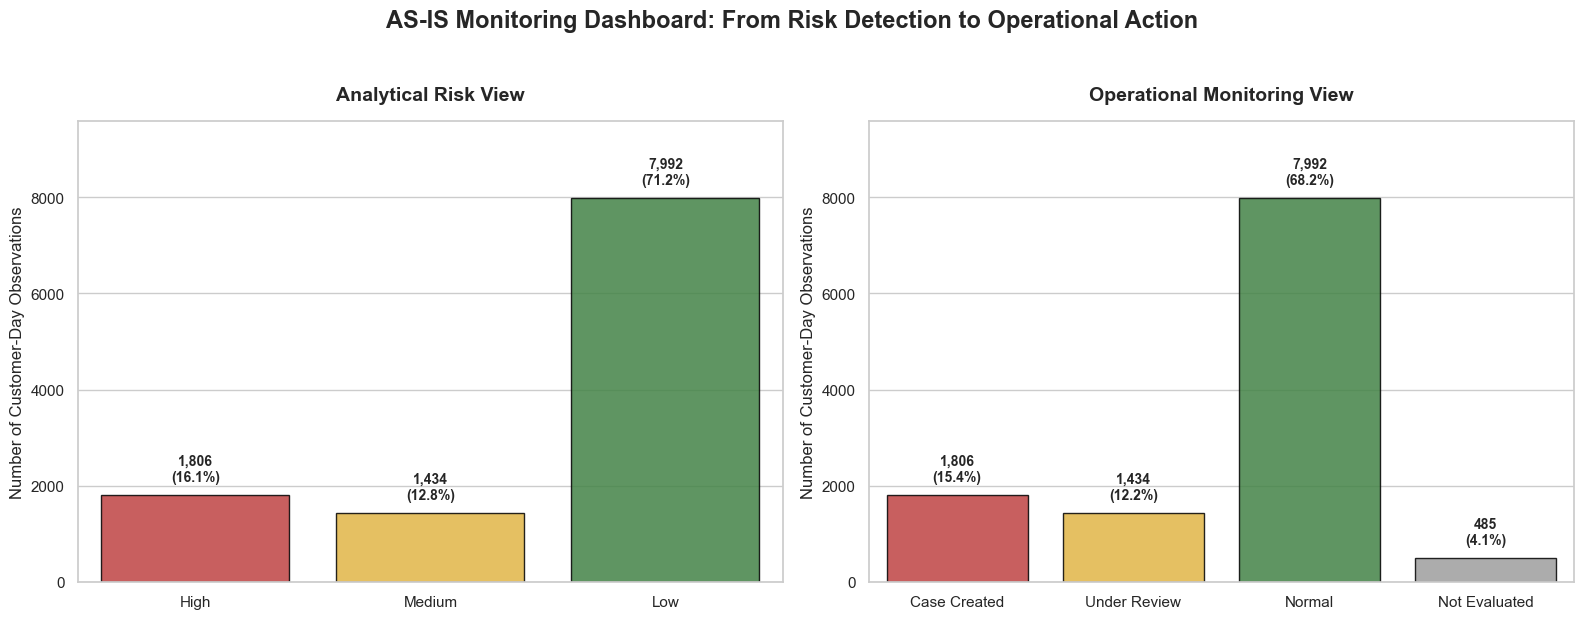


----- ANALYTICAL RISK VIEW -----
  suspiciousness_label  total_alerts  cases_created  case_rate  share_of_total
0                 High          1806           1806        1.0        0.154135
2               Medium          1434              0        0.0        0.122386
1                  Low          7992              0        0.0        0.682086

----- OPERATIONAL MONITORING VIEW -----
  monitoring_status  count  share_of_total
1      Case Created   1806        0.154135
2      Under Review   1434        0.122386
0            Normal   7992        0.682086
3     Not Evaluated    485        0.041393


In [221]:
# AS-IS SUSPICIOUS TRANSACTION MONITORING DASHBOARD

sns.set_theme(style="whitegrid")

# build summary table

total_n = len(customer_day_case_registry)

# Analytical risk view
risk_summary = (
    customer_day_case_registry
    .groupby("suspiciousness_label", dropna=False)["is_case_created"]
    .agg(total_alerts="count", cases_created="sum")
    .reset_index()
)

risk_summary["case_rate"] = risk_summary["cases_created"] / risk_summary["total_alerts"]
risk_summary["share_of_total"] = risk_summary["total_alerts"] / total_n

# Drop NaN suspiciousness if you only want evaluated categories
risk_summary = risk_summary[risk_summary["suspiciousness_label"].notna()].copy()

# Use a unified count column for plotting
risk_summary["count"] = risk_summary["total_alerts"]

# Operational monitoring view
status_summary = (
    customer_day_case_registry["monitoring_status"]
    .value_counts(dropna=False)
    .rename_axis("monitoring_status")
    .reset_index(name="count")
)

status_summary["share_of_total"] = status_summary["count"] / total_n

# set display order
risk_order = ["High", "Medium", "Low"]
status_order = ["Case Created", "Under Review", "Normal", "Not Evaluated"]

risk_summary["suspiciousness_label"] = pd.Categorical(
    risk_summary["suspiciousness_label"],
    categories=risk_order,
    ordered=True
)
risk_summary = risk_summary.sort_values("suspiciousness_label")

status_summary["monitoring_status"] = pd.Categorical(
    status_summary["monitoring_status"],
    categories=status_order,
    ordered=True
)
status_summary = status_summary.sort_values("monitoring_status")

# color map

full_palette = {
    "High": "#d32f2f",
    "Medium": "#fbc02d",
    "Low": "#388e3c",
    "Case Created": "#d32f2f",
    "Under Review": "#fbc02d",
    "Normal": "#388e3c",
    "Not Evaluated": "#9e9e9e"
}

# Plot dashboard

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Analytical Risk View
sns.barplot(
    data=risk_summary,
    x="suspiciousness_label",
    y="count",
    hue="suspiciousness_label",
    palette=full_palette,
    legend=False,
    edgecolor="black",
    alpha=0.85,
    ax=axes[0]
)

axes[0].set_title("Analytical Risk View", fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Customer-Day Observations")

for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        pct = f"{(h / risk_summary['count'].sum() * 100):.1f}%"
        axes[0].annotate(
            f"{int(h):,}\n({pct})",
            (p.get_x() + p.get_width() / 2, h),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            xytext=(0, 8),
            textcoords="offset points"
        )

# RIGHT: Operational Monitoring View
sns.barplot(
    data=status_summary,
    x="monitoring_status",
    y="count",
    hue="monitoring_status",
    palette=full_palette,
    legend=False,
    edgecolor="black",
    alpha=0.85,
    ax=axes[1]
)

axes[1].set_title("Operational Monitoring View", fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of Customer-Day Observations")

for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        pct = f"{(h / status_summary['count'].sum() * 100):.1f}%"
        axes[1].annotate(
            f"{int(h):,}\n({pct})",
            (p.get_x() + p.get_width() / 2, h),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            xytext=(0, 8),
            textcoords="offset points"
        )

# Global formatting
plt.suptitle(
    "AS-IS Monitoring Dashboard: From Risk Detection to Operational Action",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

axes[0].set_ylim(0, risk_summary["count"].max() * 1.2)
axes[1].set_ylim(0, status_summary["count"].max() * 1.2)

plt.tight_layout()
plt.show()


# print result

print("\n\033[1m----- ANALYTICAL RISK VIEW -----\033[0m")
print(risk_summary[["suspiciousness_label", "total_alerts", "cases_created", "case_rate", "share_of_total"]])

print("\n\033[1m----- OPERATIONAL MONITORING VIEW -----\033[0m")
print(status_summary[["monitoring_status", "count", "share_of_total"]])


---
### **Dashboard Intepretation**

---

The dashboard combines the analytical distribution of suspiciousness levels with their operational handling outcomes. 

> *High-risk observations are converted into formal cases, medium-risk observations remain under closer monitoring without case creation, and most low-risk observations are filtered as normal.*

A small proportion remains not evaluated due to insufficient baseline history. This shows that the AS-IS workflow applies structured triage mechanism; however, the investigation process is constrained by `limited data access`, **requiring formal requests for detailed information, which introduces delays and dependency across functions.**

---
### **S3 — 1.3.2.7 Data Processing: Conditional Drill-Down Mechanism — IT REQUEST REQUIRED**
---
***Output:** `transactions_case_view`, `ops_case_reviewed`*

After case registration, Business Operations filters escalated cases for deeper review. These cases then enter to the drill-down stage, where transaction-level details is required. So, in this simulation (AS-IS), escalated cases require transaction-level data — which must be requested from IT or Data Operation.

such access is not directly available, forcing Business Operations to submit formal requests to IT or Data Operations.

This request-driven mechanism generates IT request logs, introduces processing latency, and increases exposure to sensitive data (PII).

---
In this simulation, Service Level Agreement (SLA) definitions for data requests are derived from two primary principles:
(1) priority classification based on business impact and urgency, aligned with COBIT 2019 DSS02 (Manage Service Requests and Incidents), and
(2) time target definition based on organizational agreement mechanisms, following the ITIL 4 Service Request Management practice.

The specified time targets are further informed by common IT Service Management (ITSM) industry practices for standard service request categories. The following table presents the simulated SLA parameters applied in this study:

| Request Priority | Case Examples                         | Response Time (First Acknowledgment) | Fulfillment Time (Data Delivered) |
|-----------------|---------------------------------------|-------------------------------------|----------------------------------|
| **Urgent**      | Fraud Detection, AML Alert            | < 1–4 Hours                         | < 24 Hours                       |
| **High**        | External Audit, Regulatory Request    | 4–8 Hours                           | 1–2 Business Days                |
| **Normal**      | Monthly Report, Internal Audit        | 12–24 Hours                         | 3–5 Business Days                |
| **Low**         | Ad-hoc Request, Historical Analysis   | 24–48 Hours                         | 5–10 Business Days               |

These service requests directly affect the investigation cycle for each escalated case, introducing delays and creating bottlenecks for both Business Operations and IT/Data Operations. Each request cycle also increases the risk of exposing sensitive data (PII), as transaction-level information must be accessed and transferred repeatedly.

*References:*
1. ISACA (2019). *COBIT 2019 Framework: Governance and Management Objectives* — DSS02 (Manage Service Requests and Incidents)
2. AXELOS (2019). *ITIL 4: Service Request Management Practice*
3. [Relevant ITSM SLA benchmarking literature](https://www.sciencedirect.com/science/article/pii/S1574954122001790)


<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 900px; margin: auto;">
    <div style="border-bottom: 2px solid #fee2e2; padding-bottom: 15px; margin-bottom: 20px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.4em; margin-right: 12px;">⚠️</span>
            <strong style="color: #991b1b; font-size: 1.1em; letter-spacing: 0.5px;">AS-IS LIMITATION: CUMULATIVE RISK EXPOSURE</strong>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin-bottom: 15px;">
            In the <b>AS-IS architecture</b>, every escalated case mandates a formal IT request. This creates a bottleneck where investigation speed is tethered to <b>IT ticketing priorities</b> rather than risk urgency.
        </p>
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin: 20px 0;">
            <div style="background: #fffafb; border-left: 4px solid #ef4444; padding: 12px; border-radius: 4px;">
                <b style="color: #b91c1c; display: block; font-size: 0.85em; margin-bottom: 5px;">Operational Latency</b>
                <span style="font-size: 0.8em; color: #7f1d1d;">Delays are <b>priority-dependent</b>, causing critical investigations to stall behind routine IT tasks.</span>
            </div>
            <div style="background: #fffafb; border-left: 4px solid #ef4444; padding: 12px; border-radius: 4px;">
                <b style="color: #b91c1c; display: block; font-size: 0.85em; margin-bottom: 5px;">Privacy Erosion</b>
                <span style="font-size: 0.8em; color: #7f1d1d;">Repeated data access cycles <b>increase cumulative PII exposure</b>, expanding the organization"s attack surface.</span>
            </div>
        </div>
        <div style="text-align: center; border-top: 1px solid #f1f5f9; padding-top: 15px;">
            <span style="color: #64748b; font-size: 0.9em; font-style: italic;">
                "Every manual retrieval is a <b>security trade-off</b> that compounds with every request."
            </span>
        </div>
    </div>
</div>

In [222]:
ops_reviewed = ops_case_log[ops_case_log["ops_disposition"] == "Escalate"].copy()

print(f"Escalated cases       : {len(ops_reviewed):,}")
print(f"IT requests required  : {len(ops_reviewed):,}   <-- AS-IS bottleneck")
print()

# Drill-down via IT (simulated as direct join — but formally requires IT request)
ops_reviewed["date"] = pd.to_datetime(ops_reviewed["date"]).dt.date
transactions["date"] = pd.to_datetime(transactions["date"]).dt.date

# Drill-down to transaction level for escalated cases
transactions_case_view = transactions.merge(
    ops_reviewed[["case_id","client_id","date","suspiciousness_label","ops_disposition"]],
    on=["client_id","date"], 
    how="inner"
)

print(f"Transaction records for escalated cases: {len(transactions_case_view):,}")
display(transactions_case_view.head())
print(f"Shape: {transactions_case_view.shape}")


Escalated cases       : 1,806
IT requests required  : 1,806   <-- AS-IS bottleneck

Transaction records for escalated cases: 3,658


,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig,acct_iban,counterparty_iban,mcc,merchant_country,case_id,suspiciousness_label,ops_disposition
0,CUST000150,2024-02-23,13:43:59,TX00021924,online,C,EUR,1385.76,1385.76,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_DYWYZMQLCVPL4AFGW2VOZXKL,NaN,EE,CASE_CUST000150_20240223,High,Escalate
1,CUST000150,2024-03-25,22:25:43,TX00021928,online,C,EUR,1394.30,1394.30,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_DYWYZMQLCVPL4AFGW2VOZXKL,NaN,EE,CASE_CUST000150_20240325,High,Escalate
2,CUST000150,2024-04-25,12:50:01,TX00021932,online,C,EUR,1475.65,1475.65,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_DYWYZMQLCVPL4AFGW2VOZXKL,NaN,EE,CASE_CUST000150_20240425,High,Escalate
3,CUST000150,2024-05-24,14:09:51,TX00021935,online,C,EUR,1480.71,1480.71,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_DYWYZMQLCVPL4AFGW2VOZXKL,NaN,EE,CASE_CUST000150_20240524,High,Escalate
4,CUST000150,2024-06-25,12:27:05,TX00021939,online,C,EUR,1494.11,1494.11,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_DYWYZMQLCVPL4AFGW2VOZXKL,NaN,EE,CASE_CUST000150_20240625,High,Escalate


Shape: (3658, 16)


In [223]:
# Merge escalated transactions with customer raw profile
transactions_case_view = transactions_case_view.merge(
    customers[["client_id", "birth_dt", "bank_reg_dt", "gender_cd", "lang_pref"]],
    on="client_id",
    how="left"
)

# Derive investigation-friendly fields
reference_date = pd.Timestamp("2024-12-31")

transactions_case_view["birth_dt_parsed"] = pd.to_datetime(
    transactions_case_view["birth_dt"], errors="coerce"
)
transactions_case_view["bank_reg_dt_parsed"] = pd.to_datetime(
    transactions_case_view["bank_reg_dt"], errors="coerce"
)

transactions_case_view["age"] = np.floor(
    (reference_date - transactions_case_view["birth_dt_parsed"]).dt.days / 365.25
).astype("Int64")

transactions_case_view["tenure_years"] = np.floor(
    (reference_date - transactions_case_view["bank_reg_dt_parsed"]).dt.days / 365.25
).astype("Int64")


review_cols = [
    "case_id", "client_id", "date", "txn_id", "amount_eur",
    "channel", "merchant_country",
    "suspiciousness_label", "ops_disposition",
    "age", "tenure_years", "gender_cd", "lang_pref"
]

transactions_case_view = transactions_case_view[review_cols]

print(f"Transaction records for escalated cases: {len(transactions_case_view):,}")

print("\n\033[1m----- FINAL RESULT of TRANSACTION CASE VIEW -----\033[0m")
display(transactions_case_view.head())
print(f"Shape: {transactions_case_view.shape}")

Transaction records for escalated cases: 3,658

----- FINAL RESULT of TRANSACTION CASE VIEW -----


,case_id,client_id,date,txn_id,amount_eur,channel,merchant_country,suspiciousness_label,ops_disposition,age,tenure_years,gender_cd,lang_pref
0,CASE_CUST000150_20240223,CUST000150,2024-02-23,TX00021924,1385.76,online,EE,High,Escalate,44,11,F,EE
1,CASE_CUST000150_20240325,CUST000150,2024-03-25,TX00021928,1394.30,online,EE,High,Escalate,44,11,F,EE
2,CASE_CUST000150_20240425,CUST000150,2024-04-25,TX00021932,1475.65,online,EE,High,Escalate,44,11,F,EE
3,CASE_CUST000150_20240524,CUST000150,2024-05-24,TX00021935,1480.71,online,EE,High,Escalate,44,11,F,EE
4,CASE_CUST000150_20240625,CUST000150,2024-06-25,TX00021939,1494.11,online,EE,High,Escalate,44,11,F,EE


Shape: (3658, 13)


---
***This drill-down stage illustrates that Business Operations requests transaction-level details together with customer profile information to support further investigation. As a result, the final output of transactions_case_view consists of transaction records enriched with customer profile attributes.***

---

---
### **S3 — 1.3.2.8 Data Processing: Business Operations Review Metrics**
---

***Output:** `escalation rate`, `amplification ratio`, `IT requests required`, `PII rows exposed`*

The AS-IS design represents a process in which case-level detection and transaction-level investigation exhibit a high dependency on IT or Data Operations, leading to operational inefficiency.

#### **Operational Effectiveness Metrics**

$$Escalation\ Rate = \frac{Escalated\ Cases}{Total\ Cases}$$

$$Escalation\ Amplification\ Ratio = \frac{\sum Transaction\ Records}{\sum Escalated\ Cases}$$


<div style="background-color: #fff9f2; border-left: 6px solid #e67e22; padding: 18px; border-radius: 8px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">📉</span>
        <strong style="color: #a04000; font-size: 1.1em; letter-spacing: 0.3px;">OPERATIONAL EFFICIENCY METRICS</strong>
    </div>
    <p style="margin: 0; color: #5e3500; line-height: 1.6;">
        To evaluate process performance, key metrics such as <b>Escalation Rate</b> and <b>Amplification Ratio</b> are monitored. These indicators provide a data-driven assessment of how efficiently Business Operations translates high-level <b>case signals</b> into actionable <b>transaction-level investigations</b>.
    </p>
</div>

---
---


In [224]:
num_escalated     = ops_reviewed["case_id"].nunique()
total_cases       = ops_case_log["case_id"].nunique()
escalation_rate   = num_escalated / total_cases if total_cases > 0 else 0
amplification     = len(transactions_case_view) / num_escalated if num_escalated > 0 else 0

print(f"Total cases           : {total_cases:,}")
print(f"Escalated cases       : {num_escalated:,}")
print(f"Escalation rate       : {escalation_rate:.4f} ({escalation_rate*100:.2f}%)")
print(f"Amplification ratio   : {amplification:.2f}")
print(f"IT requests required  : {num_escalated:,}  <--- one per escalated case")
print(f"PII exposed per req.  :Sensitive transaction-level attributes")


Total cases           : 1,806
Escalated cases       : 1,806
Escalation rate       : 1.0000 (100.00%)
Amplification ratio   : 2.03
IT requests required  : 1,806  <--- one per escalated case
PII exposed per req.  :Sensitive transaction-level attributes


---
## **S3 — 1.3.3 Output Data — 1LoD Business Operations**

*This section presents the datasets generated by Business Operations as outputs of the monitoring and decision-making process. These outputs represent structured artefacts used for case management, investigation support, and audit traceability.*

**Primary Output:**
*This dataset serves as the central reference for case management and downstream investigation.*

1. `ops_case_log` — capturing the outcome of the monitoring process, including suspiciousness classification, operational disposition, and documented decision rationale (***non-escalate excluded***).
2. `customer_day_operational` — capturing the outcome of the monitoring process, including suspiciousness classification, operational disposition, and documented decision rationale. (***all dataset***)

**Supporting Output:**
*supporting datasets are generated to enable monitoring traceability, investigation, and analytical reporting*

1. `customer_day_case_registry` — Links monitoring observations (customer-day level) with case creation outcomes, enabling traceability between detection and action.
2. `ops_reviewed` — Subset of cases selected for in-depth investigation based on escalation decisions.
3. `transaction_case_view` — Transaction-level dataset containing only escalated cases, used for detailed operational investigation (drill-down).
4. `dashboard_summary`— Aggregated metrics and summaries used for monitoring performance and operational insights.
5. `transactions_case_linked` — A transaction-level dataset linking all transactions to their corresponding case outcomes (if any), including suspiciousness classification and operational disposition.

---
### **S3 — 1.3.3.1 Data Output: IT Data Request Log**
---
**Output:** `it_data_request_log`

*Simulates formal drill-down requests to IT. Each escalated case generates one IT request.*


In [225]:
# IT Data Request Log

np.random.seed(42)

# Create IT request log from escalated cases
it_request_log = ops_reviewed[["case_id", "client_id", "date", "suspiciousness_label"]].copy()
it_request_log["requested_by"] = "1LoD_Business_Ops"
it_request_log["request_type"] = "transaction_drill_down"
it_request_log["request_purpose"] = "investigation_support"
it_request_log["request_date"] = pd.to_datetime(it_request_log["date"])

# Assign priority based on suspiciousness label
priority_map = {
    "High": "Urgent",
    "Medium": "High",
    "Low": "Normal"
}
it_request_log["request_priority"] = it_request_log["suspiciousness_label"].map(priority_map).fillna("Normal")

# Simulate response and fulfillment times based on SLA table
def simulate_sla(priority):
    if priority == "Urgent":
        response_hours = np.random.uniform(1, 4) / 1.0
        fulfillment_days = np.random.uniform(0.2, 1.0)   # < 24 hours
    elif priority == "High":
        response_hours = np.random.uniform(4, 8)
        fulfillment_days = np.random.uniform(1, 2)
    elif priority == "Normal":
        response_hours = np.random.uniform(12, 24)
        fulfillment_days = np.random.uniform(3, 5)
    else:  # Low
        response_hours = np.random.uniform(24, 48)
        fulfillment_days = np.random.uniform(5, 10)
    return pd.Series([round(response_hours, 1), round(fulfillment_days, 1)])

it_request_log[["response_time_hours", "fulfillment_days"]] = it_request_log["request_priority"].apply(simulate_sla)

# Simulate exposed rows
it_request_log["pii_rows_exposed"] = np.random.randint(3, 5, size=len(it_request_log))

print("\n\033[1m----- IT DATA REQUEST LOG -----\033[0m")
print(f'Total IT requests      : {len(it_request_log):,}')
print(f'Avg response time      : {it_request_log["response_time_hours"].mean():.1f} hours')
print(f'Avg fulfillment time   : {(it_request_log["fulfillment_days"] * 24).mean():.1f} hours')
print(f'Total PII rows exposed : {it_request_log["pii_rows_exposed"].sum():,} rows')

display(it_request_log.head())


----- IT DATA REQUEST LOG -----
Total IT requests      : 1,806
Avg response time      : 2.5 hours
Avg fulfillment time   : 14.4 hours
Total PII rows exposed : 6,319 rows


,case_id,client_id,date,suspiciousness_label,requested_by,request_type,request_purpose,request_date,request_priority,response_time_hours,fulfillment_days,pii_rows_exposed
8,CASE_CUST000150_20240223,CUST000150,2024-02-23,High,1LoD_Business_Ops,transaction_drill_down,investigation_support,2024-02-23,Urgent,2.1,1.0,4
11,CASE_CUST000150_20240325,CUST000150,2024-03-25,High,1LoD_Business_Ops,transaction_drill_down,investigation_support,2024-03-25,Urgent,3.2,0.7,4
15,CASE_CUST000150_20240425,CUST000150,2024-04-25,High,1LoD_Business_Ops,transaction_drill_down,investigation_support,2024-04-25,Urgent,1.5,0.3,3
19,CASE_CUST000150_20240524,CUST000150,2024-05-24,High,1LoD_Business_Ops,transaction_drill_down,investigation_support,2024-05-24,Urgent,1.2,0.9,4
22,CASE_CUST000150_20240625,CUST000150,2024-06-25,High,1LoD_Business_Ops,transaction_drill_down,investigation_support,2024-06-25,Urgent,2.8,0.8,3


---
### **S3 — 1.3.3.2 Data Output: Documentation For Audit Trail (Case - Transaction Linked)**
---
**Output:** `transactions_case_linked`

*Unlike the drill-down dataset used for investigation, this This dataset provides a transaction-level linkage to case records, enabling end-to-end audit traceability across all monitored observations.*

---

In [226]:
# Documentation for audit trail

ops_case_log["date"]    = pd.to_datetime(ops_case_log["date"]).dt.date
transactions["date"] = pd.to_datetime(transactions["date"]).dt.date

transactions_case_linked = transactions.merge(
    ops_case_log[["case_id","client_id","date",
                  "suspiciousness_label","ops_disposition"]],
    on=["client_id","date"], 
    how="left"
)

print("\n\033[1m----- FULL CUSTOMER TRANSACTION CASE LINKED DATASET -----\033[0m")

print(f"Transactions case linked: {transactions_case_linked.shape}")
print()
print("Transactions case linked:")
print(transactions_case_linked.columns.tolist())



----- FULL CUSTOMER TRANSACTION CASE LINKED DATASET -----
Transactions case linked: (16797, 16)

Transactions case linked:
['client_id', 'date', 'time', 'txn_id', 'channel', 'd_c', 'trx_ccy', 'amount_eur', 'amount_orig', 'acct_iban', 'counterparty_iban', 'mcc', 'merchant_country', 'case_id', 'suspiciousness_label', 'ops_disposition']


In [227]:
display(transactions_case_linked.head())

,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig,acct_iban,counterparty_iban,mcc,merchant_country,case_id,suspiciousness_label,ops_disposition
0,CUST000150,2024-01-25,12:19:22,TX00021919,online,C,EUR,1485.08,1485.08,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_DYWYZMQLCVPL4AFGW2VOZXKL,NaN,EE,NaN,NaN,NaN
1,CUST000150,2024-01-12,18:24:35,TX00021920,online,D,EUR,75.08,75.08,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_NGUYAMUC7YSPV7GGRUX7X6GW,NaN,EE,NaN,NaN,NaN
2,CUST000150,2024-01-16,16:32:33,TX00021921,online,D,EUR,13.22,13.22,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_G2LGX3ZXFVOVH4DVLDLV4R5C,NaN,EE,NaN,NaN,NaN
3,CUST000150,2024-01-22,18:50:18,TX00021922,card,D,EUR,11.05,11.05,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_7FOUQYUKQPL55N4U3PZ5S3RT,5816.0,EE,NaN,NaN,NaN
4,CUST000150,2024-01-18,15:13:12,TX00021923,online,D,EUR,16.07,16.07,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_RVMJ22MF25IKELEIFZEPSHJO,NaN,EE,NaN,NaN,NaN


In [228]:
print("\033[1m----- AS-IS BUSINESS OPERATIONS OUTPUT (ALL OUTPUT)-----\033[0m")
print(f"customer_day_operational   : {customer_day_operational.shape}")
print(f"case_log                   : {ops_case_log.shape}")
print(f"transactions_case_linked   : {transactions_case_linked.shape}")
print(f"transactions_case_view     : {transactions_case_view.shape}")
print(f"customer_day_case_registry : {customer_day_case_registry.shape}")
print(f"ops_case_reviewed          : {ops_reviewed.shape}")
print(f"it_request_log             : {it_request_log.shape}")


----- AS-IS BUSINESS OPERATIONS OUTPUT (ALL OUTPUT)-----
customer_day_operational   : (11717, 17)
case_log                   : (1806, 12)
transactions_case_linked   : (16797, 16)
transactions_case_view     : (3658, 13)
customer_day_case_registry : (11717, 21)
ops_case_reviewed          : (1806, 12)
it_request_log             : (1806, 12)


### **S3 — 1.3.3.3 Business Ops Output Dataset**

| Feature                           | AS-IS Business Ops            |
| --------------------------------- | ----------------------------- |
| **Data Access for Investigation** | Requires IT request           |
| **Escalation Handling**           | Triggers data request & delay |
| **IT Dependency**                 | ***Yes***                     |
| **PII Exposure**                  | ***Yes*** (raw data required) |
| **Escalation Rate**               | Variable                      |
| **Amplification Ratio**           | Delayed / partial             |
| **Transaction Traceability**      | Indirect                      | 
| **Operational Latency**           | High (queue-based)            |
| **Data Coverage**                 | Partial                       | 
| **Output Structure**              | Limited case records          | 

### **S3 — 1.3.3.4 Business Ops Transformation Output**

| Component               | Description                                                                                                                                                                                                          |
| ----------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Role**                | Business Operations (Decision Layer — Monitoring, Case Evaluation, and Escalation Handling)                                                                                                                          |
| **Input**               | Aggregated monitoring indicators / partial extracts from DataOps (non-standardized, request-based)                                                                                                                   |
| **Output Type**         | Fragmented operational datasets and request-driven artifacts                                                                                                                                                         |
| **Primary Outputs**     | • `ops_case_log` (escalated cases)<br>• `ops_monitoring_view` (partial monitoring view)<br>• `transactions_case_view` (transaction-level data via IT request)<br>• `it_request_log` (cross-line dependency artifact) |
| **Granularity**         | Mixed — customer-level (monitoring) and transaction-level (after request)                                                                                                                                            |
| **Fields**              | Limited analytical indicators + decision attributes; enriched with raw customer profile during drill-down                                                                                                            |
| **Processing Logic**    | Rule-based evaluation, threshold checks, escalation decision, followed by request-driven drill-down                                                                                                                  |
| **Data Access Pattern** | Sequential and request-based (dependent on IT/DataOps)                                                                                                                                                               |
| **Reusability**         | Low — outputs are case-specific and not standardized                                                                                                                                                                 |
| **Consistency**         | Low — varies across requests and investigation contexts                                                                                                                                                              |
| **Transparency**        | Partial — visibility depends on requested data scope                                                                                                                                                                 |
| **Purpose**             | Detect suspicious activity and support investigation through escalation and data requests                                                                                                                            |
| **Key Limitation**      | Investigation requires formal IT requests, leading to delays, fragmented data views, and repeated exposure to sensitive data                                                                                         |

### **S3 — 1.3.3.5 Data Dimension Gap: IT vs DataOps vs BusinessOps**

| Dimension            | IT (Raw Transaction Layer)         | DataOps (Transformation Layer)     | Business Operations (Decision Layer)                            | Gap / Limitation                       |
| -------------------- | ---------------------------------- | ---------------------------------- | --------------------------------------------------------------- | -------------------------------------- |
| **Role**             | Data owner (source system)         | Data processor (support)           | Decision-maker (risk evaluation)                                | Misaligned responsibilities            |
| **Data Structure**   | Raw transactional records          | Partial aggregates / indicators    | Case-level + ad-hoc extracts                                    | No unified analytical structure        |
| **Granularity**      | Transaction-level (event-by-event) | Mixed (event → aggregated)         | Customer-level (monitoring) → transaction-level (after request) | Inconsistent granularity across layers |
| **Fields**           | Full attributes incl. PII          | Reduced fields (filtered)          | Limited indicators + requested attributes                       | Fragmented field availability          |
| **Processing Logic** | None (data storage)                | Ad-hoc transformation              | Rule-based decision + manual drill-down                         | Disconnected processing logic          |
| **Temporal Detail**  | Full timestamp (date + time)       | Partially aggregated (e.g., daily) | Reduced view until drill-down                                   | Loss of temporal continuity            |
| **Feature Type**     | Raw attributes                     | Derived indicators (ratios, flags) | Decision attributes + partial context                           | Incomplete analytical features         |
| **Dependency**       | Independent (source layer)         | Dependent on request               | Highly dependent on IT/DataOps                                  | High cross-line dependency             |
| **Traceability**     | Direct (transaction-level)         | Partial                            | Fragmented (requires reconstruction)                            | Broken traceability chain              |
| **Join Capability**  | Limited across functions           | Not standardized                   | Difficult (manual reconstruction)                               | Low interoperability                   |
| **Accessibility**    | Restricted (IT-controlled)         | Request-based                      | Limited and sequential                                          | Bottlenecked access                    |
| **Reusability**      | Low (not analysis-ready)           | Low (case-specific outputs)        | Low (not reusable across cases)                                 | No persistent dataset                  |
| **Consistency**      | High (source of truth)             | Low (varies per request)           | Low (context-dependent)                                         | No single source of truth              |
| **Transparency**     | Low for downstream users           | Partial visibility                 | Limited visibility                                              | Lack of end-to-end visibility          |
| **Key Limitation**   | Too granular & restricted          | Too fragmented & inconsistent      | Too constrained                                                 |                                        |


---
<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 900px; margin: auto;">
    <div style="border-bottom: 2px solid #cbd5e1; padding-bottom: 15px; margin-bottom: 20px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.4em; margin-right: 12px;">⛓️</span>
            <strong style="color: #334155; font-size: 1.1em; letter-spacing: 0.5px;">AS-IS ARCHITECTURE: STRUCTURAL DATA DEPENDENCY</strong>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin-bottom: 15px;">
            In the <b>AS-IS architecture</b>, the integration of a formal request layer within Data Operations transforms data access into a <b>critical dependency</b>. This structure forces investigators into a "passive" stance, where decision-making is contingent upon external data fulfillment.
        </p>
        <div style="background: #f8fafc; border-left: 5px solid #475569; padding: 15px; margin: 20px 0; border-radius: 4px;">
            <p style="margin: 0; color: #1e293b; font-size: 0.9em; font-weight: 500;">
                <b>The Accuracy vs. Latency Paradox:</b> While these requests are intended to enable deeper investigation, they simultaneously introduce <b>structural delays</b>. In time-sensitive GRC scenarios, this multi-layered process compromises the <b>accuracy</b> of decisions by restricting access to the full behavioral context in real-time.
            </p>
        </div>
        <div style="display: flex; gap: 15px; justify-content: space-around; margin-top: 15px; text-align: center;">
            <div style="flex: 1;">
                <span style="display: block; color: #b91c1c; font-size: 1.2em; font-weight: bold;">Increased</span>
                <span style="font-size: 0.75em; color: #64748b; text-transform: uppercase;">Operational Risk</span>
            </div>
            <div style="flex: 1; border-left: 1px solid #e2e8f0; border-right: 1px solid #e2e8f0;">
                <span style="display: block; color: #b91c1c; font-size: 1.2em; font-weight: bold;">Constrained</span>
                <span style="font-size: 0.75em; color: #64748b; text-transform: uppercase;">Decision Timelines</span>
            </div>
            <div style="flex: 1;">
                <span style="display: block; color: #b91c1c; font-size: 1.2em; font-weight: bold;">Fragmented</span>
                <span style="font-size: 0.75em; color: #64748b; text-transform: uppercase;">Investigation Flow</span>
            </div>
        </div>
    </div>
</div>

---
# **SECTION 4 — THE SECOND LINE OF DEFENCE (RISK MANAGEMENT & COMPLIANCE) (2LoD)**
---
---

```mermaid

flowchart TD
    subgraph Silo1 [Data Operations]
        A[(customer_day)]
    end

    subgraph Silo2 [Business Operations]
        C[(ops_case_log)]
        D[(customer_day_operational)]
    end

    subgraph Silo2LOD [Second Line of Defense]
        subgraph ComplianceDept [Compliance Department]
            I1[Independent Review: Case Verification] --> K[SOP Validation]
            K --> M[lod2_compliance_review_log]
        end

        subgraph RiskDept [Risk Management Department]
            I2[Independent Review: Aggregate Oversight] --> L[Trend Analysis]
            L --> N[lod2_risk_dashboard]
        end
    end

    I1 -.->|Request Case Evidence| C
    I2 -.->|Request Monitoring Summary| D
    I2 -.->|Request Aggregate Indicators| A

    C --> AT1[[Operational Evidence Trail]]
    M --> AT2[[Compliance Review Trail]]
    N --> AT3[[Risk Oversight Trail]]

    style Silo2LOD fill:#fff3cd,stroke:#856404,stroke-width:2px

```

---
# **S4 — 1.1 — 2LoD: Risk Management Department (Independent Oversight)**
***Input:** `case_log`, `customer_day_operational` — Operational outputs from Business Operations*

## **2LoD — Risk Management Department**

| Component          | Description                                                                                                   |
| ------------------ | ------------------------------------------------------------------------------------------------------------- |
| **Role**           | Risk Management (Oversight Layer — Aggregate Monitoring, Validation, and Risk Assessment)                     |
| **Input**          | Aggregated monitoring outputs and summary extracts from Business Operations and DataOps (request-based)       |
| **Output**         | `lod2_risk_dashboard` — monthly oversight metrics and escalation trend view                                   |
| **Granularity**    | Aggregated monthly oversight level                                                                            |
| **Fields**         | Escalation counts, severity distribution, escalation rate, amplification ratio, stability indicators          |
| **Processing**     | Population aggregation, escalation pattern analysis, and trend-based validation (based on available data)     |
| **Purpose**        | Assess operational risk patterns, validate escalation behavior, and monitor trend consistency over time       |
| **Key Limitation** | Limited and request-based data access; reliance on partial datasets restricts visibility and delays oversight |

*The Risk Management function operates independently from Business Operations, focusing on validation, monitoring, and oversight rather than executing operational decisions.*

In the AS-IS architecture, Risk Management does not have direct access to raw data from IT or Data Operations. Instead, its analytical capability is constrained by request-based data access and reliance on aggregated or partially available datasets.

As a result, Risk Management performs aggregate oversight based on data provided through Business Operations outputs or DataOps extracts. The process includes monthly aggregation of suspiciousness labels and escalation outcomes, construction of key oversight metrics, and monitoring of trend stability over time. However, the limited and non-standardized nature of the available data restricts comprehensive validation of monitoring logic and systemic risk patterns. The resulting output is summarized in the lod2_risk_dashboard.

## **Risk Management 2nd Line (Independent Review Process)**
```mermaid

flowchart LR
    %% SOURCE LAYER
    subgraph Source [1LoD Outputs]
        A[(customer_day / monitoring outputs)]
        B[(ops_case_log)]
    end

    %% REQUEST LAYER
    subgraph RequestLayer [Request-Based Access]
        R1[Request Aggregate Monitoring Data]
        R2[Request Escalation Evidence]
        IT[(IT / DataOps Provisioning)]
    end

    R1 -->|Formal Request\nSLA Delay| IT
    R2 -->|Formal Request\nSLA Delay| IT

    IT -.->|Partial / Delayed Data| D1[Monitoring Extract]
    IT -.->|Partial / Delayed Data| D2[Case-Level Extract]

    %% RISK PROCESS
    subgraph Risk [Risk Management - 2nd Line]
        E[Aggregate Oversight Review]
        F[Trend Analysis & Stability Check]
        G[Validation of Escalation Behavior]
        H{Risk Evaluation}
    end

    D1 & D2 --> E
    E --> F --> G --> H

    H --> O1[risk_dashboard]

    %% Styling
    style Source fill:#eeeeee,stroke:#999,stroke-dasharray:5 5
    style RequestLayer fill:#ffebee,stroke:#c62828,stroke-width:2px
    style Risk fill:#fff3e0,stroke:#e65100,stroke-width:2px

```

---

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 900px; margin: auto;">
    <div style="border-bottom: 2px solid #64748b; padding-bottom: 15px; margin-bottom: 20px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.4em; margin-right: 12px;">⌛</span>
            <strong style="color: #1e293b; font-size: 1.1em; letter-spacing: 0.5px;">AS-IS LIMITATION: THE PROACTIVITY GAP</strong>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin-bottom: 15px;">
            The current architecture enforces a <b>structural limitation</b> where risk oversight is inherently <b>reactive</b>. Because deeper validation is gated by the "Request-and-Wait" protocol, the investigation only begins after the trail of a risk signal has already grown cold.
        </p>
        <div style="background: #f1f5f9; padding: 20px; border-radius: 8px; margin: 20px 0; border: 1px dashed #cbd5e1;">
            <div style="display: flex; justify-content: space-between; align-items: center; font-size: 0.8em; color: #475569; font-weight: bold;">
                <div style="text-align: center; flex: 1;">SIGNAL DETECTED<br><span style="color: #94a3b8;">(Passive Alert)</span></div>
                <div style="color: #cbd5e1; font-size: 1.5em;">➜</div>
                <div style="text-align: center; flex: 1; color: #b91c1c;">DATA REQUESTED<br><span>(Operational Lag)</span></div>
                <div style="color: #cbd5e1; font-size: 1.5em;">➜</div>
                <div style="text-align: center; flex: 1;">VALIDATION BEGINS<br><span style="color: #b91c1c;">(Reactive State)</span></div>
            </div>
        </div>
        <p style="margin: 0; color: #334155; font-size: 0.9em;">
            This <b>permission-gated validation</b> prevents real-time risk mitigation. In a proactive GRC framework, validation should be the <i>immediate successor</i> to detection, not a delayed administrative event.
        </p>
    </div>
</div>

## **S4 — 1.1.1 — Input Dataset**

**input:** `customer_day_operational` (primary), `ops_case_log` (supporting)`

* `customer_day_operational` — full operational monitoring dataset used for monthly risk trend analysis, escalation patterns, and oversight across evaluated observations.
* `ops_case_log` — formal case-level dataset used to review escalated outcomes, case volume, and documented rationale.

In [229]:
print("\033[1m----- TO-BE RISK MANAGEMENT INPUT -----\n\033[0m")

# PRIMARY INPUT
print("\n\033[1m ---------- [PRIMARY] customer_day_operational (Full Monitoring Dataset): ----------\033[0m")
print(f'  Shape  : {customer_day_operational.shape}')
print(f'  Columns: {customer_day_operational.columns.tolist()}')
print(f'  Evaluated rows: {customer_day_operational["is_evaluated"].sum():,}')
print()

display(customer_day_operational.head(5))


# SUPPORTING INPUT
print("\n\033[1m ---------- [SUPPORTING] ops_case_log (Formal Case Log): ----------\n\033[0m")
print(f'  Shape  : {ops_case_log.shape}')
print(f'  Columns: {ops_case_log.columns.tolist()}')
print(f'  Unique cases: {ops_case_log["case_id"].nunique():,}')
print()

display(ops_case_log.head(5))

----- TO-BE RISK MANAGEMENT INPUT -----


 ---------- [PRIMARY] customer_day_operational (Full Monitoring Dataset): ----------
  Shape  : (11717, 17)
  Columns: ['client_id', 'date', 'daily_txn_count', 'daily_total_amount', 'daily_avg_amount', 'baseline_txn_count', 'baseline_total_amount', 'baseline_avg_amount', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'is_evaluated', 'suspiciousness_label', 'ops_disposition', 'ops_rules']
  Evaluated rows: 11,232



,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,baseline_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,is_evaluated,suspiciousness_label,ops_disposition,ops_rules
0,CUST000150,2024-01-12,1,75.08,75.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)
1,CUST000150,2024-01-16,1,13.22,13.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)
2,CUST000150,2024-01-18,1,16.07,16.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)
3,CUST000150,2024-01-22,1,11.05,11.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)
4,CUST000150,2024-01-25,1,1485.08,1485.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)



 ---------- [SUPPORTING] ops_case_log (Formal Case Log): ----------

  Shape  : (1806, 12)
  Columns: ['case_id', 'case_created_at', 'client_id', 'date', 'suspiciousness_label', 'ops_disposition', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'ops_rules']
  Unique cases: 1,806



,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules
8,CASE_CUST000150_20240223,2026-05-15 13:11:08.670554,CUST000150,2024-02-23,High,Escalate,1.0000,6.4598,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
11,CASE_CUST000150_20240325,2026-05-15 13:11:08.670554,CUST000150,2024-03-25,High,Escalate,0.9167,4.7870,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
15,CASE_CUST000150_20240425,2026-05-15 13:11:08.670554,CUST000150,2024-04-25,High,Escalate,0.9375,4.6865,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
19,CASE_CUST000150_20240524,2026-05-15 13:11:08.670554,CUST000150,2024-05-24,High,Escalate,0.9500,4.4549,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
22,CASE_CUST000150_20240625,2026-05-15 13:11:08.670554,CUST000150,2024-06-25,High,Escalate,0.9565,4.1700,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...


## **S4 — 1.1.2 — Data Process: Risk Dashboard**
***Output:** `risk_dashboard`*

In [230]:
# Monthly aggregation

customer_day_operational["date"]  = pd.to_datetime(customer_day_operational["date"])
customer_day_operational["month"] = customer_day_operational["date"].dt.to_period("M")

# Monthly aggregation (full oversight)
risk_dashboard = (
    customer_day_operational
    .groupby("month")
    .agg(
        total_observations  = ("client_id", "count"),
        evaluated_cases     = ("suspiciousness_label", lambda x: x.notna().sum()),
        high_cases          = ("suspiciousness_label", lambda x: (x=="High").sum()),
        medium_cases        = ("suspiciousness_label", lambda x: (x=="Medium").sum()),
        low_cases           = ("suspiciousness_label", lambda x: (x=="Low").sum()),
        escalated_cases     = ("ops_disposition", lambda x: (x=="Escalate").sum())
    )
    .reset_index()
)


# Escalation rate (valid now)
risk_dashboard["escalation_rate"] = (
    risk_dashboard["escalated_cases"] /
    risk_dashboard["evaluated_cases"].replace(0, pd.NA)
)

# Amplification ratio (from drill-down dataset)
transactions_case_view["date"] = pd.to_datetime(transactions_case_view["date"])
transactions_case_view["month"] = transactions_case_view["date"].dt.to_period("M")

monthly_txn = (
    transactions_case_view
    .groupby("month")
    .size()
    .reset_index(name="txn_records_escalated")
)

risk_dashboard = risk_dashboard.merge(monthly_txn, on="month", how="left")

risk_dashboard["amplification_ratio"] = (
    risk_dashboard["txn_records_escalated"] /
    risk_dashboard["escalated_cases"].replace(0, pd.NA)
)

# Stability index
risk_dashboard = risk_dashboard.sort_values("month")
risk_dashboard["escalation_rate_prev"] = risk_dashboard["escalation_rate"].shift(1)

risk_dashboard["escalation_stability_index"] = (
    (risk_dashboard["escalation_rate"] - risk_dashboard["escalation_rate_prev"]).abs()
    / risk_dashboard["escalation_rate_prev"]
)

print("\n\033[1m ---------- TO-BE RISK DASHBOARD ----------\033[0m")

display(risk_dashboard.head(12))
print(f"\nShape: {risk_dashboard.shape}")


 ---------- TO-BE RISK DASHBOARD ----------


,month,total_observations,evaluated_cases,high_cases,medium_cases,low_cases,escalated_cases,escalation_rate,txn_records_escalated,amplification_ratio,escalation_rate_prev,escalation_stability_index
0,2024-01,946,562,102,55,405,102,0.181495,237,2.323529,NaN,NaN
1,2024-02,887,859,151,88,620,151,0.175786,317,2.099338,0.181495,0.031455
2,2024-03,941,933,137,112,684,137,0.146838,250,1.824818,0.175786,0.164676
3,2024-04,898,896,152,115,629,152,0.169643,282,1.855263,0.146838,0.155305
4,2024-05,944,935,157,117,661,157,0.167914,304,1.936306,0.169643,0.010189
5,2024-06,986,977,149,166,662,149,0.152508,292,1.959732,0.167914,0.091754
6,2024-07,955,952,147,103,702,147,0.154412,304,2.068027,0.152508,0.012485
7,2024-08,962,962,150,122,690,150,0.155925,315,2.100000,0.154412,0.009801
8,2024-09,979,967,161,122,684,161,0.166494,307,1.906832,0.155925,0.067784
9,2024-10,1065,1052,175,128,749,175,0.166350,373,2.131429,0.166494,0.000868



Shape: (12, 12)


### **S4 — 1.1.2.1 — Data Process: Sanity Check — AS-IS Risk Dashboard**

*To confirms dashboard is internally consistent, with all classification and escalation logic correctly aligned.*

In [231]:
print("\n\033[1m----- SANITY CHECK: AS-IS RISK DASHBOARD -----\033[0m\n")

# 1. Label consistency (High + Medium + Low = evaluated_cases)
label_cols = ["high_cases", "medium_cases", "low_cases"]
risk_dashboard["label_sum"] = risk_dashboard[label_cols].sum(axis=1)

print("Label sum == evaluated_cases:")
print((risk_dashboard["label_sum"] == risk_dashboard["evaluated_cases"]).value_counts())
print()

# 2. Escalation consistency (High == escalated_cases)
print("High cases == escalated_cases:")
print((risk_dashboard["high_cases"] == risk_dashboard["escalated_cases"]).value_counts())
print()

# 3. No division errors (check NaN / inf)
print("3. Check NaN in key metrics:")
print(risk_dashboard[[
    "escalation_rate",
    "amplification_ratio",
    "escalation_stability_index"
]].isna().sum())
print()

# 4. Amplification ratio sanity (should be >= 1)
print("Amplification ratio >= 1:")
print((risk_dashboard["amplification_ratio"] >= 1).value_counts())
print()

# 5. Escalation rate range (0–1)
print("Escalation rate within [0,1]:")
print(((risk_dashboard["escalation_rate"] >= 0) &
       (risk_dashboard["escalation_rate"] <= 1)).value_counts())
print()

# 6. Stability index interpretation check
print("Stability index (high volatility months):")
print(risk_dashboard[
    risk_dashboard["escalation_stability_index"] > 0.3
][["month", "escalation_stability_index"]])

print("\n\033[1m --- Result: ALL SANITY CHECKS PASSED ---\033[0m")


----- SANITY CHECK: AS-IS RISK DASHBOARD -----

Label sum == evaluated_cases:
True    12
Name: count, dtype: int64

High cases == escalated_cases:
True    12
Name: count, dtype: int64

3. Check NaN in key metrics:
escalation_rate               0
amplification_ratio           0
escalation_stability_index    1
dtype: int64

Amplification ratio >= 1:
amplification_ratio
True    12
Name: count, dtype: int64

Escalation rate within [0,1]:
escalation_rate
True    12
Name: count, dtype: int64

Stability index (high volatility months):
Empty DataFrame
Columns: [month, escalation_stability_index]
Index: []

 --- Result: ALL SANITY CHECKS PASSED ---


<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 900px; margin: auto;">
    <div style="border-bottom: 2px solid #cbd5e1; padding-bottom: 15px; margin-bottom: 20px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.4em; margin-right: 12px;">📉</span>
            <strong style="color: #334155; font-size: 1.1em; letter-spacing: 0.5px;">AS-IS DASHBOARD: THE ILLUSION OF STABILITY</strong>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin-bottom: 15px;">
            In the <b>AS-IS risk dashboard</b>, no high-volatility periods were identified. Escalation patterns remain remarkably stable across the observed timeframe, with no significant deviations exceeding the predefined stability threshold. 
        </p>
        <div style="background: #f8fafc; border-left: 5px solid #64748b; padding: 15px; margin: 20px 0; border-radius: 4px;">
            <p style="margin: 0; color: #1e293b; font-size: 0.9em; font-weight: 500;">
                <b>Methodological Limitation:</b> This observed consistency is a byproduct of the <b>aggregated view</b> inherent in the AS-IS process. By assessing stability through <b>summarized monthly indicators</b>, the dashboard effectively "smooths out" granular daily or weekly spikes that may contain critical risk signals.
            </p>
        </div>
        <div style="display: flex; gap: 15px; justify-content: space-around; margin-top: 15px; text-align: center;">
            <div style="flex: 1;">
                <span style="display: block; color: #475569; font-size: 1.2em; font-weight: bold;">Stable</span>
                <span style="font-size: 0.75em; color: #94a3b8; text-transform: uppercase;">Escalation Patterns</span>
            </div>
            <div style="flex: 1; border-left: 1px solid #e2e8f0; border-right: 1px solid #e2e8f0;">
                <span style="display: block; color: #b91c1c; font-size: 1.2em; font-weight: bold;">Compressed</span>
                <span style="font-size: 0.75em; color: #94a3b8; text-transform: uppercase;">Risk Volatility</span>
            </div>
            <div style="flex: 1;">
                <span style="display: block; color: #b91c1c; font-size: 1.2em; font-weight: bold;">Hidden</span>
                <span style="font-size: 0.75em; color: #94a3b8; text-transform: uppercase;">Granular Anomalies</span>
            </div>
        </div>
    </div>
</div>

### **S4 — 1.1.2.2 — Data Process: AS-IS Risk Dashboard (Monthly Escalation Trend)**

*To show monthly escalation trend including escalation rate within  months*

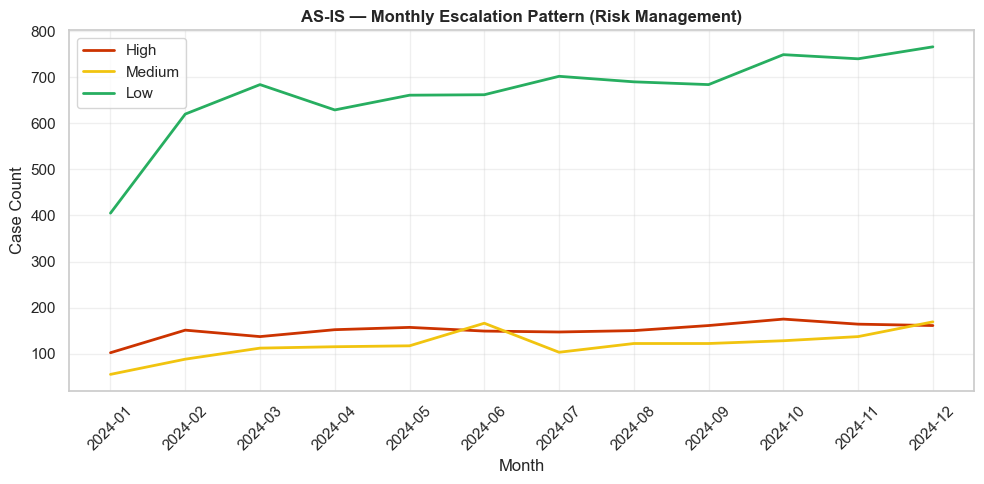

In [232]:
# Monthly escalation trend

plt.figure(figsize=(10, 5))

label_cols = ["high_cases", "medium_cases", "low_cases"]

colors_lbl = {
    "high_cases": "#cc3300",
    "medium_cases": "#f1c40f",
    "low_cases": "#27ae60"
}

label_names = {
    "high_cases": "High",
    "medium_cases": "Medium",
    "low_cases": "Low"
}

for label in label_cols:
    plt.plot(
        risk_dashboard["month"].astype(str),
        risk_dashboard[label],
        label=label_names[label],
        color=colors_lbl[label],
        linewidth=2
    )

plt.title("AS-IS — Monthly Escalation Pattern (Risk Management)", fontsize=12, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Case Count")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div style="background-color: #f8fafc; border-left: 6px solid #1e293b; padding: 20px; border-radius: 10px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05); max-width: 800px;">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">📊</span>
        <strong style="color: #0f172a; font-size: 1.1em; letter-spacing: 0.3px; text-transform: uppercase;">Monthly Trend Analysis (AS-IS)</strong>
    </div>
    <div style="color: #334155; line-height: 1.6;">
        <p style="margin: 0; font-size: 0.95em;">
            The monthly AS-IS pattern shows that <b>low-risk cases account for the majority</b> of monthly volume, indicating that most behavior is characterized as minor deviations. While <b>high- and medium-risk cases remain relatively stable</b>, their upward trend indicates a gradual increase in overall risk exposure throughout the year.
        </p>
    </div>
</div>

### **S4 — 1.1.3 Output Dataset — 2LoD Risk Management**
***Output:** `risk_dashboard` — Oversight Layer Output*

*Aggregated oversight dataset. Same structure as AS-IS, but enriched with demographic context.*

***Output:** `risk_dashboard` — Oversight Layer Output*

| Feature                   | AS-IS Risk Management                |
| ------------------------- | ------------------------------------ |
| **Data Access**           | Requires IT-provided aggregated data |
| **Granularity**           | Limited aggregated reports           |
| **PII Exposure**          | Possible (depending on request)      |
| **Metric Availability**   | Limited, request-based               |
| **Escalation Monitoring** | Delayed visibility                   |
| **Trend Analysis**        | Periodic, dependent on data delivery |
| **Inter-line Visibility** | Restricted                           |
| **IT Dependency**         | ***Yes***                            |
| **Operational Latency**   | High                                 |

### **S4 — 1.1.4 Risk Management Transformation Output**
***Business Operations --> Risk Management (Oversight Transformation)***

| Dimension             | Input (Business Ops / DataOps Extract)     | Risk Management Output: `risk_dashboard` | Structural Change           |
| --------------------- | ------------------------------------------ | --------------------------------------------- | --------------------------- |
| **Granularity**       | Mixed (customer-day / case-level extracts) | Aggregated monthly oversight                  | Aggregation (micro → macro) |
| **PII**               | Limited exposure (request-based)           | Not directly retained (aggregated view)       | Reduced visibility          |
| **Access**            | Request-based, partial data                | Internal analytical output                    | Restricted transformation   |
| **Enrichment**        | Limited indicators available               | Derived oversight metrics (rates, trends)     | Analytical abstraction      |
| **Consistency**       | Varies across requests                     | Standardized dashboard structure              | Partial standardization     |
| **Temporal Coverage** | Dependent on request scope                 | Continuous monthly aggregation                | Temporal smoothing          |
| **Dependency**        | High (IT/DataOps mediated)                 | Still dependent on input availability         | Dependency preserved        |
| **Traceability**      | Fragmented                                 | Indirect (based on aggregated metrics)        | Reduced traceability        |


### **S4 — 1.1.4 Data Dimension Gap: IT vs DataOps vs BusinessOps vs Risk vs Compliance — 2LoD Risk MAnagement**

| Dimension            | IT (Raw Layer)                     | DataOps (Transformation Layer)       | Business Operations (1LoD)                 | Risk Management (2LoD)             | Gap / Limitation                |
| -------------------- | ---------------------------------- | ------------------------------------ | ------------------------------------------ | ---------------------------------- | ------------------------------- |
| **Role**             | Data owner (source system)         | Data processor (feature preparation) | Operational decision-maker                 | Aggregate oversight & validation   | Misaligned responsibilities     |
| **Data Structure**   | Raw transactional records          | Partial aggregates / indicators      | Case logs + ad-hoc extracts                | Aggregated dashboard               | No unified analytical structure |
| **Granularity**      | Transaction-level (event-by-event) | Mixed (event → aggregated)           | Customer-day → transaction (after request) | Monthly aggregated                 | Progressive abstraction         |
| **Fields**           | Full attributes incl. PII          | Filtered indicators                  | Limited + requested attributes             | Derived metrics only               | Fragmented field availability   |
| **Processing Logic** | None (data storage)                | Feature engineering                  | Rule-based decision                        | Trend analysis & validation        | Disconnected logic              |
| **Temporal Detail**  | Full timestamp                     | Partially aggregated                 | Limited until drill-down                   | Monthly summary                    | Loss of temporal resolution     |
| **Feature Type**     | Raw attributes                     | Derived indicators                   | Decision variables                         | Aggregated metrics (rates, ratios) | Increasing abstraction          |
| **Dependency**       | Independent                        | Request-dependent                    | Highly dependent                           | Conditionally dependent            | Cross-line dependency           |
| **Traceability**     | Direct (transaction-level)         | Partial                              | Fragmented                                 | Indirect (aggregated view)         | Broken traceability chain       |
| **Join Capability**  | Limited across layers              | Not standardized                     | Manual reconstruction                      | Not joinable                       | Low interoperability            |
| **Accessibility**    | Restricted (IT-controlled)         | Request-based                        | Limited                                    | Limited & delayed                  | Bottlenecked access             |
| **Reusability**      | Low (not analysis-ready)           | Low (case-specific)                  | Low (case-driven)                          | Medium (dashboard reuse)           | No shared dataset               |
| **Consistency**      | High (source of truth)             | Low (varies per request)             | Low                                        | Medium (standardized metrics)      | No single source of truth       |
| **Transparency**     | Low for downstream                 | Partial                              | Limited                                    | Limited (aggregated only)          | Reduced visibility              |
| **Key Limitation**   | Too granular & restricted          | Too fragmented                       | Too dependent                              | Too abstract & delayed             | Structural inefficiency         |


---

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 900px; margin: auto;">
    <div style="border-bottom: 2px solid #64748b; padding-bottom: 15px; margin-bottom: 20px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.4em; margin-right: 12px;">📉</span>
            <strong style="color: #1e293b; font-size: 1.1em; letter-spacing: 0.5px;">AS-IS RISK MANAGEMENT: THE VALIDATION LAG</strong>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin-bottom: 15px;">
            In the <b>AS-IS architecture</b>, the Risk Management function is structurally disadvantaged. By operating on <b>aggregated and delayed data</b>, the second line of defense (2LoD) is restricted to a retrospective view, rather than an active oversight role.
        </p>
        <div style="background: #fff1f2; border-left: 5px solid #be123c; padding: 15px; margin: 20px 0; border-radius: 4px;">
            <p style="margin: 0; color: #9f1239; font-size: 0.9em; font-weight: 500;">
                <b>Constraint on Comprehensive Validation:</b> The lack of granular, real-time access limits the ability to validate underlying risk patterns as they emerge. This creates an <b>Oversight Gap</b>, where significant behavioral shifts remain unverified until the next reporting cycle.
            </p>
        </div>
        <div style="display: flex; gap: 10px; flex-wrap: wrap; margin-top: 15px;">
            <span style="background: #f1f5f9; color: #475569; padding: 4px 12px; border-radius: 4px; font-size: 0.75em; font-weight: bold; border: 1px solid #cbd5e1;">Retrospective Oversight</span>
            <span style="background: #f1f5f9; color: #475569; padding: 4px 12px; border-radius: 4px; font-size: 0.75em; font-weight: bold; border: 1px solid #cbd5e1;">Data Latency Dependency</span>
            <span style="background: #f1f5f9; color: #475569; padding: 4px 12px; border-radius: 4px; font-size: 0.75em; font-weight: bold; border: 1px solid #cbd5e1;">Compressed Risk Granularity</span>
        </div>
    </div>
</div>

---
# **S4 — 1.2 2LoD: Compliance Department (Procedural Adherence)**
***Input:** `customer_day_operational` and `ops_case_log`*

*The Compliance function operates independently from Business Operations, focusing on procedural, regulatory adherence.*

| Component          | Description                                                                                                  |
| ------------------ | ------------------------------------------------------------------------------------------------------------ |
| **Role**           | Compliance (Independent Validation Layer — Procedural & Regulatory Oversight)                                |
| **Input**          | `ops_case_log` (escalated cases) + selected extracts from Business Operations / DataOps (request-based)      |
| **Data Scope**     | Primarily escalated cases; full population data available only upon request                                  |
| **Granularity**    | Case-level (escalated observations)                                                                          |
| **Access**         | Request-based access; limited and selective data retrieval                                                   |
| **PII Exposure**   | Potential exposure during case-level data requests                                                           |
| **Purpose**        | Validate procedural adherence, escalation handling, and compliance with internal and regulatory requirements |
| **Key Limitation** | Limited visibility and dependency on IT/DataOps restrict independent and timely validation                   |




Unlike Risk Management, which focuses on system-level validation, the Compliance function ensures that operational processes adhere to internal policies and regulatory requirements.

In the TO-BE model, Compliance primarily relies on escalated case logs and selectively requests additional data when deeper validation is required. Access to full monitoring datasets is not directly available, and any need for detailed transaction-level or contextual information must be fulfilled through formal requests to IT or Data Operations.

As a result, the validation process is constrained by limited data visibility and request-driven access. This introduces delays and restricts the ability of Compliance to independently perform comprehensive procedural and regulatory checks. While independence in role is maintained, independence in data access remains limited, impacting the effectiveness and timeliness of compliance validation.

---

---


## **Compliance 2nd Line (Independent Review Process)**

```mermaid
flowchart LR
    %% SOURCE LAYER
    subgraph Source [1LoD Outputs]
        A[(ops_case_log)]
        B[(supporting case evidence)]
    end

    %% REQUEST LAYER
    subgraph RequestLayer [Request-Based Access]
        R1[Request Escalated Case Log]
        R2[Request Supporting Documentation]
        IT[(Business Ops / IT / DataOps Provisioning)]
    end

    R1 -->|Formal Request\nSLA Delay| IT
    R2 -->|Formal Request\nSLA Delay| IT

    IT -.->|Partial / Delayed Data| D1[Case Review Extract]
    IT -.->|Partial / Delayed Data| D2[Documentation Extract]

    %% COMPLIANCE PROCESS
    subgraph Compliance [Compliance - 2nd Line]
        E[Case Sampling & Review]
        F[Documentation Completeness Check]
        G[SOP Adherence Validation]
        H{Compliance Assessment}
    end

    D1 & D2 --> E
    E --> F --> G --> H

    H --> O1[compliance_review_log]

    %% Styling
    style Source fill:#eeeeee,stroke:#999,stroke-dasharray:5 5
    style RequestLayer fill:#ffebee,stroke:#c62828,stroke-width:2px
    style Compliance fill:#e8f5e9,stroke:#2e7d32,stroke-width:2px
```

---
<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 900px; margin: auto;">
    <div style="border-bottom: 2px solid #64748b; padding-bottom: 15px; margin-bottom: 20px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.4em; margin-right: 12px;">⚖️</span>
            <strong style="color: #1e293b; font-size: 1.1em; letter-spacing: 0.5px;">AS-IS COMPLIANCE: THE DEPENDENCY BOTTLENECK</strong>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin-bottom: 15px;">
            Similar to Risk Management, the <b>Compliance function</b> in the AS-IS architecture is structurally tethered to a <b>request-based access model</b>. Without direct access to the full raw dataset, Compliance must perform its duties using only <b>selectively provided data</b>.
        </p>
        <div style="background: #fff1f2; border-left: 5px solid #be123c; padding: 15px; margin: 20px 0; border-radius: 4px;">
            <p style="margin: 0; color: #9f1239; font-size: 0.9em; font-weight: 500;">
                <b>Constraint on Regulatory Assurance:</b> This secondary dependency creates a <b>"Blind Spot"</b> in the review process. Compliance’s ability to perform timely and comprehensive procedural checks is hindered, as they cannot independently verify the integrity of the data provided for validation.
            </p>
        </div>
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 15px;">
            <div style="background: #f1f5f9; padding: 10px; border-radius: 6px; font-size: 0.85em; color: #475569; border: 1px solid #cbd5e1;">
                <b>Verification:</b> Non-Independent
            </div>
            <div style="background: #f1f5f9; padding: 10px; border-radius: 6px; font-size: 0.85em; color: #475569; border: 1px solid #cbd5e1;">
                <b>Checks:</b> Sample-Dependent
            </div>
        </div>
    </div>
</div>

## **S4 — 1.2.1 Input Dataset**

**input:** `customer_day_operational` (primary), `ops_case_log` (supporting)

* `customer_day_operational` — full operational monitoring dataset used for assessing procedural consistency, classification logic, and completeness of evaluation across all observations.
* `ops_case_log` — formal case-level dataset used to validate escalation decisions, disposition integrity, and adherence to standard operating procedures (SOP). As this dataset contain only escalated cases (labeled as `High`), triggering in-depth case review process.

In [233]:
print("\033[1m----- AS-IS COMPLIANCE INPUT -----\033[0m")
print("Input datasets used for procedural compliance review (2LoD)")

# PRIMARY INPUT
print("\n\033[1m ---------- [PRIMARY] customer_day_operational (Full Monitoring Dataset): ----------\033[0m")
print(f'  Shape  : {customer_day_operational.shape}')
print(f'  Columns: {customer_day_operational.columns.tolist()}')
print(f'  Evaluated rows: {customer_day_operational["is_evaluated"].sum():,}')
print()

display(customer_day_operational.head(5))


# SUPPORTING INPUT
print("\n\033[1m ---------- [SUPPORTING] ops_case_log (Formal Escalated Case Log): ----------\033[0m")
print(f'  Shape  : {ops_case_log.shape}')
print(f'  Columns: {ops_case_log.columns.tolist()}')
print(f'  Unique cases: {ops_case_log["case_id"].nunique():,}')
print(f'  Case labels: {ops_case_log["suspiciousness_label"].value_counts().to_dict()}')
print()
display(ops_case_log.head(5))

----- AS-IS COMPLIANCE INPUT -----
Input datasets used for procedural compliance review (2LoD)

 ---------- [PRIMARY] customer_day_operational (Full Monitoring Dataset): ----------
  Shape  : (11717, 18)
  Columns: ['client_id', 'date', 'daily_txn_count', 'daily_total_amount', 'daily_avg_amount', 'baseline_txn_count', 'baseline_total_amount', 'baseline_avg_amount', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'is_evaluated', 'suspiciousness_label', 'ops_disposition', 'ops_rules', 'month']
  Evaluated rows: 11,232



,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,baseline_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,is_evaluated,suspiciousness_label,ops_disposition,ops_rules,month
0,CUST000150,2024-01-12,1,75.08,75.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),2024-01
1,CUST000150,2024-01-16,1,13.22,13.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),2024-01
2,CUST000150,2024-01-18,1,16.07,16.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),2024-01
3,CUST000150,2024-01-22,1,11.05,11.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),2024-01
4,CUST000150,2024-01-25,1,1485.08,1485.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),2024-01



 ---------- [SUPPORTING] ops_case_log (Formal Escalated Case Log): ----------
  Shape  : (1806, 12)
  Columns: ['case_id', 'case_created_at', 'client_id', 'date', 'suspiciousness_label', 'ops_disposition', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'ops_rules']
  Unique cases: 1,806
  Case labels: {'High': 1806}



,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules
8,CASE_CUST000150_20240223,2026-05-15 13:11:08.670554,CUST000150,2024-02-23,High,Escalate,1.0000,6.4598,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
11,CASE_CUST000150_20240325,2026-05-15 13:11:08.670554,CUST000150,2024-03-25,High,Escalate,0.9167,4.7870,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
15,CASE_CUST000150_20240425,2026-05-15 13:11:08.670554,CUST000150,2024-04-25,High,Escalate,0.9375,4.6865,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
19,CASE_CUST000150_20240524,2026-05-15 13:11:08.670554,CUST000150,2024-05-24,High,Escalate,0.9500,4.4549,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
22,CASE_CUST000150_20240625,2026-05-15 13:11:08.670554,CUST000150,2024-06-25,High,Escalate,0.9565,4.1700,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...


## **S4 — 1.2.2 Data Process: Compliance Review Log**
***Output:** `compliance_log`*

*This dataset is used to store the compliance review results of customer activities with escalated status.*

The dataset captures the final reviewed outcome of each escalated case, serving as a structured record for compliance validation.

In [234]:
# compliance review log

compliance_log = ops_case_log[[
    "case_id", "case_created_at", "client_id", "date",
    "suspiciousness_label", "ops_disposition"
]].copy()

print(f"Shape  : {compliance_log.shape}")
compliance_log.head()


Shape  : (1806, 6)


,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition
8,CASE_CUST000150_20240223,2026-05-15 13:11:08.670554,CUST000150,2024-02-23,High,Escalate
11,CASE_CUST000150_20240325,2026-05-15 13:11:08.670554,CUST000150,2024-03-25,High,Escalate
15,CASE_CUST000150_20240425,2026-05-15 13:11:08.670554,CUST000150,2024-04-25,High,Escalate
19,CASE_CUST000150_20240524,2026-05-15 13:11:08.670554,CUST000150,2024-05-24,High,Escalate
22,CASE_CUST000150_20240625,2026-05-15 13:11:08.670554,CUST000150,2024-06-25,High,Escalate


## **S4 — 1.2.3 Data Process: Compliance Logic — Procedural Validation**

*This stage represents the compliance function performing an independent review of escalated cases generated by Business Operations.*

The objective is to validate whether internal controls related to escalation handling and case disposition are applied correctly and consistently, in accordance with predefined rules, thresholds, and standard operating procedures (SOP), both internal and regulatory. The validation is operationalised through quantitative compliance indicators derived from the review log.

### **S4 — 1.2.3.1 Data Process: Disposition Integrity** *(identical SOP mapping to TO-BE)*

*Verifying that the assigned ops_disposition (e.g., Escalate) aligns with the detected risk signals and rule triggers.*

In [235]:
# expected_disposition.

def disposition_integrity(label):
    if label == "High":   return "Escalate"
    elif label == "Medium": return "Under review"
    elif label == "Low":  return "Dismiss"
    else: return np.nan

compliance_log["disposition_integrity"] = (
    compliance_log["suspiciousness_label"].apply(disposition_integrity)
)

print(f"\n\033[1m ----- SANITY CHECK AFTER ADDING DISPOSITION INTEGRITY -----\033[0m")
print(f"\nShape        : {compliance_log.shape}")
print(f"Column names : {compliance_log.columns.tolist()}")

display(compliance_log.head())

print("\n\033[1mDisposition Mapping Check:\033[0m")
print(compliance_log[["suspiciousness_label", "ops_disposition", "disposition_integrity"]].head())



 ----- SANITY CHECK AFTER ADDING DISPOSITION INTEGRITY -----

Shape        : (1806, 7)
Column names : ['case_id', 'case_created_at', 'client_id', 'date', 'suspiciousness_label', 'ops_disposition', 'disposition_integrity']


,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,disposition_integrity
8,CASE_CUST000150_20240223,2026-05-15 13:11:08.670554,CUST000150,2024-02-23,High,Escalate,Escalate
11,CASE_CUST000150_20240325,2026-05-15 13:11:08.670554,CUST000150,2024-03-25,High,Escalate,Escalate
15,CASE_CUST000150_20240425,2026-05-15 13:11:08.670554,CUST000150,2024-04-25,High,Escalate,Escalate
19,CASE_CUST000150_20240524,2026-05-15 13:11:08.670554,CUST000150,2024-05-24,High,Escalate,Escalate
22,CASE_CUST000150_20240625,2026-05-15 13:11:08.670554,CUST000150,2024-06-25,High,Escalate,Escalate



Disposition Mapping Check:
   suspiciousness_label ops_disposition disposition_integrity
8                  High        Escalate              Escalate
11                 High        Escalate              Escalate
15                 High        Escalate              Escalate
19                 High        Escalate              Escalate
22                 High        Escalate              Escalate


### **S4 — 1.2.3.2 Data Process: Escalation Consistency** 

*ensures that escalation decisions are not arbitrary, but systematically supported by underlying risk indicators*

This stage evaluates whether escalation decisions are consistent with underlying `rule-based indicators, such as auto_red_flag and severity thresholds`.

Consistency is assessed by comparing expected escalation (based on rule triggers) with actual escalation labels, ensuring alignment between detected risk signals and operational decisions.

In [236]:
# Expected escalation from rule
expected_escalation = (ops_case_log["auto_red_flag"] == 1)

# Actual escalation from label
actual_escalation = (ops_case_log["suspiciousness_label"] == "High")

# Consistency check
consistency_check = (expected_escalation == actual_escalation)

consistency_rate = consistency_check.mean()

print("\n\033[1m----- ESCALATION CONSISTENCY CHECK -----\033[0m")
print(f"Consistent cases : {consistency_check.sum():,} / {len(ops_case_log):,}")
print(f"Consistency rate : {consistency_rate:.4f} ({consistency_rate*100:.2f}%)")

print("\n\033[1mEscalation Breakdown:\033[0m")
print(pd.crosstab(expected_escalation, actual_escalation))



----- ESCALATION CONSISTENCY CHECK -----
Consistent cases : 1,806 / 1,806
Consistency rate : 1.0000 (100.00%)

Escalation Breakdown:
suspiciousness_label  True
auto_red_flag             
True                  1806


### **S4 — 1.2.3.3 Data Process: Rule Adherence** 

*Ensuring that escalation decisions are rule-based and consistently aligned with predefined thresholds, rather than arbitrary or inconsistent judgment.*


This stage verifies whether escalation decisions comply with predefined rule logic, including trigger conditions such as `auto_red_flag` and severity thresholds (`velocity_severity` and `value_saverity`).

Rule adherence is assessed by comparing expected escalation (**based on rule conditions**) with actual escalation outcomes, ensuring that decisions are aligned with defined operational logic.

In [237]:
# Expected rule trigger (flexible logic)

expected_trigger = (
    (ops_case_log["auto_red_flag"] == 1) |
    (ops_case_log["velocity_severity"] == "Significant") |
    (ops_case_log["value_severity"] == "Significant")
)

# Actual escalation
actual_escalation = (ops_case_log["suspiciousness_label"] == "High")

# Rule adherence check
rule_adherence_check = (expected_trigger == actual_escalation)

rule_adherence_rate = rule_adherence_check.mean()

print("\n\033[1m----- RULE ADHERENCE CHECK -----\033[0m")
print(f"Adherent cases : {rule_adherence_check.sum():,} / {len(ops_case_log):,}")
print(f"Adherence rate : {rule_adherence_rate:.4f} ({rule_adherence_rate*100:.2f}%)")


----- RULE ADHERENCE CHECK -----
Adherent cases : 1,806 / 1,806
Adherence rate : 1.0000 (100.00%)


### **S4 — 1.2.3.4 Data Process: SOP Deviation Flag** 

**Output:** `compliance_log`

*Providing a metric that enables to identify control deviationssystematicly; Allowing Compliance to detect inconsistencies in operational decision-making.*

This stage identifies **deviations from predefined SOP** by comparing the assigned `ops_disposition` with the expected disposition (`disposition_integrity`) derived from rule-based mapping. A deviation flag is generated to indicate whether the operational decision aligns with the predefined SOP logic.

In [238]:

compliance_log["sop_deviation_flag"] = (
    compliance_log["ops_disposition"] !=
    compliance_log["disposition_integrity"]
).astype(int)

display(compliance_log.head())

sop_rate = 1 - compliance_log["sop_deviation_flag"].mean()

#total reviewed
total_reviewed = len(compliance_log)

print("\n\033[1m----- SOP DEVIATION CHECK -----\033[0m")
print(f'Total reviewed   : {total_reviewed:,}')
print(f'Deviation cases : {compliance_log["sop_deviation_flag"].sum():,}')
print(f'SOP compliance  : {sop_rate:.4f} ({sop_rate*100:.2f}%)')

print("\n\033[1mDeviation Breakdown:\033[0m")
print(compliance_log["sop_deviation_flag"].value_counts())


,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,disposition_integrity,sop_deviation_flag
8,CASE_CUST000150_20240223,2026-05-15 13:11:08.670554,CUST000150,2024-02-23,High,Escalate,Escalate,0
11,CASE_CUST000150_20240325,2026-05-15 13:11:08.670554,CUST000150,2024-03-25,High,Escalate,Escalate,0
15,CASE_CUST000150_20240425,2026-05-15 13:11:08.670554,CUST000150,2024-04-25,High,Escalate,Escalate,0
19,CASE_CUST000150_20240524,2026-05-15 13:11:08.670554,CUST000150,2024-05-24,High,Escalate,Escalate,0
22,CASE_CUST000150_20240625,2026-05-15 13:11:08.670554,CUST000150,2024-06-25,High,Escalate,Escalate,0



----- SOP DEVIATION CHECK -----
Total reviewed   : 1,806
Deviation cases : 0
SOP compliance  : 1.0000 (100.00%)

Deviation Breakdown:
sop_deviation_flag
0    1806
Name: count, dtype: int64


<div style="background-color: #f6fef9; border-left: 6px solid #10b981; padding: 20px; border-radius: 10px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 15px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">🚩</span>
        <strong style="color: #064e3b; font-size: 1.1em; letter-spacing: 0.3px;">SOP DEVIATION & COMPLIANCE RATE</strong>
    </div>
    <div style="color: #111827; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 12px 0;">
            The <b>SOP deviation flag</b> quantifies whether operational decisions align with predefined rule-based expectations. 
        </p>
        <div style="background: #ffffff; border: 1px solid #d1fae5; padding: 12px; border-radius: 6px; display: flex; align-items: flex-start;">
            <span style="color: #059669; font-weight: bold; margin-right: 10px;">➔</span>
            <span>
                The resulting <b>compliance rate</b> provides a measurable indicator of procedural consistency within the compliance function.
            </span>
        </div>
    </div>
</div>

### **S4 — 1.2.3.5 Data Process: Documentation Present Flag** 

*escalated label are expected to have rule documentation records*

This step verifies whether supporting documentation is present for escalated cases. Cases marked as Escalate are expected to have non-empty rule documentation (ops_rules) recorded in the case log.

In [239]:
# documentation_present_flag — identical logic to AS-IS fixed version

compliance_log["documentation_present_flag"] = np.where(
    compliance_log["ops_disposition"] == "Escalate",
    compliance_log["case_id"].isin(
        ops_case_log[ops_case_log["ops_rules"].str.len() > 0]["case_id"]
    ).astype(int),
    1
)

print("documentation_present_flag distribution:")
print(compliance_log["documentation_present_flag"].value_counts())


documentation_present_flag distribution:
documentation_present_flag
1    1806
Name: count, dtype: int64


### **S4 — 1.2.3.6 Data Process: Compliance Status**

*classification output to Compliant or Governance Issue based on evidence*

This step classifies each reviewed case as either Compliant or Governance Issue, based on procedural consistency and documentation completeness.

In [240]:
compliance_log["compliance_status"] = np.where(
    (compliance_log["sop_deviation_flag"] == 0) &
    (compliance_log["documentation_present_flag"] == 1),
    "Compliant",
    "Governance Issue"
)
compliance_log.head()


,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,disposition_integrity,sop_deviation_flag,documentation_present_flag,compliance_status
8,CASE_CUST000150_20240223,2026-05-15 13:11:08.670554,CUST000150,2024-02-23,High,Escalate,Escalate,0,1,Compliant
11,CASE_CUST000150_20240325,2026-05-15 13:11:08.670554,CUST000150,2024-03-25,High,Escalate,Escalate,0,1,Compliant
15,CASE_CUST000150_20240425,2026-05-15 13:11:08.670554,CUST000150,2024-04-25,High,Escalate,Escalate,0,1,Compliant
19,CASE_CUST000150_20240524,2026-05-15 13:11:08.670554,CUST000150,2024-05-24,High,Escalate,Escalate,0,1,Compliant
22,CASE_CUST000150_20240625,2026-05-15 13:11:08.670554,CUST000150,2024-06-25,High,Escalate,Escalate,0,1,Compliant


### **S4 — 1.2.3.7 Data Process: Review Timestamp**

In [241]:
compliance_log["review_timestamp"] = pd.Timestamp.now()
compliance_log.head()


,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,disposition_integrity,sop_deviation_flag,documentation_present_flag,compliance_status,review_timestamp
8,CASE_CUST000150_20240223,2026-05-15 13:11:08.670554,CUST000150,2024-02-23,High,Escalate,Escalate,0,1,Compliant,2026-05-15 13:11:12.777354
11,CASE_CUST000150_20240325,2026-05-15 13:11:08.670554,CUST000150,2024-03-25,High,Escalate,Escalate,0,1,Compliant,2026-05-15 13:11:12.777354
15,CASE_CUST000150_20240425,2026-05-15 13:11:08.670554,CUST000150,2024-04-25,High,Escalate,Escalate,0,1,Compliant,2026-05-15 13:11:12.777354
19,CASE_CUST000150_20240524,2026-05-15 13:11:08.670554,CUST000150,2024-05-24,High,Escalate,Escalate,0,1,Compliant,2026-05-15 13:11:12.777354
22,CASE_CUST000150_20240625,2026-05-15 13:11:08.670554,CUST000150,2024-06-25,High,Escalate,Escalate,0,1,Compliant,2026-05-15 13:11:12.777354


### **S4 — 1.2.3.7 Data Process: Compliance Matrix**

#### **SOP Compliance Rate**

##### **Formula**

$$ SOP\ Compliance\ Rate = \frac{\text{Number of compliant cases}}{\text{Total reviewed cases}}$$

In [242]:
total_reviewed   = len(compliance_log)
sop_rate         = (compliance_log["sop_deviation_flag"] == 0).mean()
gov_rate         = (compliance_log["compliance_status"] == "Governance Issue").mean()
doc_rate         = compliance_log["documentation_present_flag"].mean()

print("\n\033[1m---------- TO-BE COMPLIANCE MATRIX ----------\n\033[0m")
print(f"Total reviewed          : {total_reviewed:,}")
print(f"SOP Compliance Rate     : {sop_rate:.4f} ({sop_rate*100:.2f}%)")
print(f"Governance Issue Rate   : {gov_rate:.4f} ({gov_rate*100:.2f}%)")
print(f"Documentation Rate      : {doc_rate:.4f} ({doc_rate*100:.2f}%)")



---------- TO-BE COMPLIANCE MATRIX ----------

Total reviewed          : 1,806
SOP Compliance Rate     : 1.0000 (100.00%)
Governance Issue Rate   : 0.0000 (0.00%)
Documentation Rate      : 1.0000 (100.00%)


## **S4 — 1.2.4 Output Dataset — 2LoD Compliance**

**Output:** `lod2_compliance_log` and `Compliance Dashboard`

*compliance review result is faster because all supporting data is directly accessible.*

`compliance_log` serves as the final reviewed compliance dataset, capturing all case-level validation results and procedural flags.
The compliance matrix provides an aggregated monitoring view that can support internal compliance oversight and dashboard-style reporting.

In the TO-BE setting, compliance review is performed more efficiently as all required supporting data is directly accessible through the synthetic data layer.


In [243]:
print("\n\033[1m---------- AS-IS COMPLIANCE REVIEW LOG ----------\n\033[0m")
compliance_log.head()

print(f"Shape: {compliance_log.shape}")


---------- AS-IS COMPLIANCE REVIEW LOG ----------

Shape: (1806, 11)


In [244]:
print("\033[1m---------- TO-BE COMPLIANCE DASHBOARD VIEW ----------\033[0m")

# summary KPI

total_reviewed = len(compliance_log)
compliant_cases = (compliance_log["compliance_status"] == "Compliant").sum()
governance_issues = (compliance_log["compliance_status"] == "Governance Issue").sum()
documentation_rate = compliance_log["documentation_present_flag"].mean()

print(f"\nTotal reviewed       : {total_reviewed:,}")
print(f"Compliant cases      : {compliant_cases:,}")
print(f"Governance issues    : {governance_issues:,}")
print(f"Documentation rate   : {documentation_rate:.4f} ({documentation_rate*100:.2f}%)")

# Dashboard-oriented display table

dashboard_view = compliance_log[[
    "case_id",
    "client_id",
    "date",
    "suspiciousness_label",
    "ops_disposition",
    "compliance_status",
    "documentation_present_flag",
    "review_timestamp"
]].copy()

dashboard_view["documentation_present_flag"] = dashboard_view["documentation_present_flag"].map({
    1: "Present",
    0: "Missing"
})

# rename columns for dashboard readability
dashboard_view = dashboard_view.rename(columns={
    "case_id": "Case ID",
    "client_id": "Customer",
    "date": "Case Date",
    "suspiciousness_label": "Ops Label",
    "ops_disposition": "Ops Decision",
    "compliance_status": "Compliance Review Result",
    "documentation_present_flag": "Documentation",
    "review_timestamp": "Reviewed At"
})

print("\n\033[1mDashboard Preview:\033[0m")
display(dashboard_view.head(10))


print("\n\033[1m---------- GOVERNANCE ISSUES ONLY ----------\033[0m")

governance_issue_view = dashboard_view[
    dashboard_view["Compliance Review Result"] == "Governance Issue"
].copy()

print(f"\nTotal governance issues: {len(governance_issue_view):,}\n")
display(governance_issue_view.head(10))

# Build review basis / review comment
compliance_log["review_basis"] = np.select(
    [
        (compliance_log["sop_deviation_flag"] == 1) &
        (compliance_log["documentation_present_flag"] == 0),

        (compliance_log["sop_deviation_flag"] == 1),

        (compliance_log["documentation_present_flag"] == 0)
    ],
    [
        "SOP deviation and missing documentation",
        "SOP deviation",
        "Missing documentation"
    ],
    default="SOP matched and documentation complete"
)

dashboard_view = compliance_log[[
    "case_id",
    "client_id",
    "date",
    "suspiciousness_label",
    "ops_disposition",
    "compliance_status",
    "review_basis",
    "documentation_present_flag",
    "review_timestamp"
]].copy()

dashboard_view["documentation_present_flag"] = dashboard_view["documentation_present_flag"].map({
    1: "Present",
    0: "Missing"
})

dashboard_view = dashboard_view.rename(columns={
    "case_id": "Case ID",
    "client_id": "Customer",
    "date": "Case Date",
    "suspiciousness_label": "Ops Label",
    "ops_disposition": "Ops Decision",
    "compliance_status": "Compliance Review Result",
    "review_basis": "Review Basis",
    "documentation_present_flag": "Documentation",
    "review_timestamp": "Reviewed At"
})

print("\n\033[1mDashboard Preview with Review Basis:\033[0m")
display(dashboard_view.head(10))

---------- TO-BE COMPLIANCE DASHBOARD VIEW ----------

Total reviewed       : 1,806
Compliant cases      : 1,806
Governance issues    : 0
Documentation rate   : 1.0000 (100.00%)

Dashboard Preview:


,Case ID,Customer,Case Date,Ops Label,Ops Decision,Compliance Review Result,Documentation,Reviewed At
8,CASE_CUST000150_20240223,CUST000150,2024-02-23,High,Escalate,Compliant,Present,2026-05-15 13:11:12.777354
11,CASE_CUST000150_20240325,CUST000150,2024-03-25,High,Escalate,Compliant,Present,2026-05-15 13:11:12.777354
15,CASE_CUST000150_20240425,CUST000150,2024-04-25,High,Escalate,Compliant,Present,2026-05-15 13:11:12.777354
19,CASE_CUST000150_20240524,CUST000150,2024-05-24,High,Escalate,Compliant,Present,2026-05-15 13:11:12.777354
22,CASE_CUST000150_20240625,CUST000150,2024-06-25,High,Escalate,Compliant,Present,2026-05-15 13:11:12.777354
25,CASE_CUST000150_20240725,CUST000150,2024-07-25,High,Escalate,Compliant,Present,2026-05-15 13:11:12.777354
28,CASE_CUST000150_20240823,CUST000150,2024-08-23,High,Escalate,Compliant,Present,2026-05-15 13:11:12.777354
30,CASE_CUST000150_20240925,CUST000150,2024-09-25,High,Escalate,Compliant,Present,2026-05-15 13:11:12.777354
33,CASE_CUST000150_20241025,CUST000150,2024-10-25,High,Escalate,Compliant,Present,2026-05-15 13:11:12.777354
36,CASE_CUST000150_20241125,CUST000150,2024-11-25,High,Escalate,Compliant,Present,2026-05-15 13:11:12.777354



---------- GOVERNANCE ISSUES ONLY ----------

Total governance issues: 0



,Case ID,Customer,Case Date,Ops Label,Ops Decision,Compliance Review Result,Documentation,Reviewed At



Dashboard Preview with Review Basis:


,Case ID,Customer,Case Date,Ops Label,Ops Decision,Compliance Review Result,Review Basis,Documentation,Reviewed At
8,CASE_CUST000150_20240223,CUST000150,2024-02-23,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:11:12.777354
11,CASE_CUST000150_20240325,CUST000150,2024-03-25,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:11:12.777354
15,CASE_CUST000150_20240425,CUST000150,2024-04-25,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:11:12.777354
19,CASE_CUST000150_20240524,CUST000150,2024-05-24,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:11:12.777354
22,CASE_CUST000150_20240625,CUST000150,2024-06-25,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:11:12.777354
25,CASE_CUST000150_20240725,CUST000150,2024-07-25,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:11:12.777354
28,CASE_CUST000150_20240823,CUST000150,2024-08-23,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:11:12.777354
30,CASE_CUST000150_20240925,CUST000150,2024-09-25,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:11:12.777354
33,CASE_CUST000150_20241025,CUST000150,2024-10-25,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:11:12.777354
36,CASE_CUST000150_20241125,CUST000150,2024-11-25,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:11:12.777354


## **S4 — 1.2.5 Output General Output 2LoD Compliance**

**Output:** `lod2_compliance_review_log`

### **1. KPI - COMPLIANCE MATRIX Matrices**

| Metric                    | Value   | Interpretation                                     |
| ------------------------- | ------- | -------------------------------------------------- |
| **Total Reviewed Cases**  | 1,709   | Escalated cases reviewed based on available data   |
| **SOP Compliance Rate**   | 100.00% | All reviewed cases follow defined procedural rules |
| **Governance Issue Rate** | 0.00%   | No deviation detected within the reviewed scope    |
| **Documentation Rate**    | 100.00% | Documentation is complete for all reviewed cases   |


## **2. Governance Insight**

| Dimension                      | Observation                              | Governance Implication                                     |
| ------------------------------ | ---------------------------------------- | ---------------------------------------------------------- |
| **Coverage**                   | Limited to accessible escalated cases    | Review scope depends on available data                     |
| **SOP Adherence**              | 100% compliant (within reviewed dataset) | Procedural consistency observed in accessible cases        |
| **Documentation Completeness** | 100% available (within reviewed dataset) | Traceability exists but limited to requested data          |
| **Governance Issues**          | 0 detected                               | No issues identified within visible scope                  |
| **Operational Latency**        | Present (request-based delay)            | Compliance validation is not immediate                     |
| **IT Dependency**              | High                                     | Review process depends on Business Ops / IT data provision |


## **S4 — 1.2.6 Output Dataset — 2LoD Compliance**

| Feature                        | AS-IS Compliance                            | 
| ------------------------------ | ------------------------------------------- |
| **Data Access**                | Requires request via Business Ops / IT      |
| **Granularity**                | Case-level (limited supporting data)        |
| **PII Exposure**               | Possible (raw data accessed during request) | 
| **Review Scope**               | Limited to requested cases                  | 
| **SOP Validation**             | Based on available documentation            |
| **Documentation Check**        | Dependent on retrieved data                 | 
| **Governance Issue Detection** | Limited by data visibility                  | 
| **Inter-line Visibility**      | Restricted                                  | 
| **IT Dependency**              | ***Yes***                                   | 
| **Operational Latency**        | High (request and processing delay)         |

- **Event-level visibility** --> Available via `customer_day_operational`
- **Counterparty context** --> not available
- **IT request dependency** --> Eliminated
- **Review speed** --> waiting for data delivery



## **S4 — 1.2.7 Compliance Transformation Output — 2LoD Compliance**

| Dimension         | Input (`ops_case_log`, requested data)    | Output (`lod2_compliance_review_log`) | Transformation            |
| ----------------- | ----------------------------------------- | ------------------------------------- | ------------------------- |
| **Granularity**   | Case-level (escalated cases)              | Case-level review                     | Decision → Validation     |
| **Access**        | Request-based datasets                    | Limited datasets                      | Restricted transformation |
| **IT Request**    | Required (indirect via Business Ops / IT) | Required                              | Dependency maintained     |
| **Processing**    | Decision output                           | SOP validation, documentation check   | Control layer added       |
| **Latency**       | Delayed (request-based)                   | Delayed validation                    | Waiting time introduced   |
| **Control Layer** | Not present                               | Introduced                            | Action → Assurance        |



### **S4 — 1.1.4 Data Dimension Gap: IT vs DataOps vs BusinessOps vs Risk vs Compliance — 2LoD Risk MAnagement**

| Dimension            | IT (Raw Layer)            | DataOps (Transformation)  | Business Ops (Decision)                    | Risk Management (2LoD)      | Compliance (2LoD)     | Gap / Limitation            |
| -------------------- | ------------------------- | ------------------------- | ------------------------------------------ | --------------------------- | --------------------- | --------------------------- |
| **Role**             | Data owner                | Data processor            | Operational decision-maker                 | Aggregate oversight         | Case-level validation | Fragmented responsibilities |
| **Data Structure**   | Raw transactions          | Partial aggregates        | Case logs + extracts                       | Aggregated dashboard        | Case review logs      | No unified structure        |
| **Granularity**      | Transaction-level         | Mixed (event → aggregate) | Customer-day → transaction (after request) | Monthly aggregated          | Case-level            | Inconsistent across layers  |
| **Fields**           | Full attributes incl. PII | Filtered indicators       | Limited + requested data                   | Derived metrics only        | Case evidence only    | Fragmented field access     |
| **Processing Logic** | None                      | Feature engineering       | Rule-based decision                        | Trend analysis & validation | SOP validation        | Disconnected logic          |
| **Temporal Detail**  | Full timestamp            | Partially aggregated      | Limited until drill-down                   | Monthly summary             | Case timestamp only   | Loss of continuity          |
| **Feature Type**     | Raw attributes            | Derived indicators        | Decision variables                         | Aggregated metrics          | Compliance flags      | Layer-specific abstraction  |
| **Dependency**       | Independent               | Request-dependent         | Highly dependent                           | Conditionally dependent     | Selectively dependent | Cross-line dependency       |
| **Traceability**     | Direct                    | Partial                   | Fragmented                                 | Indirect                    | Case-specific         | Broken traceability         |
| **Join Capability**  | Limited                   | Not standardized          | Manual reconstruction                      | Not joinable                | Not joinable          | Low interoperability        |
| **Accessibility**    | Restricted                | Request-based             | Limited                                    | Limited & delayed           | Limited & selective   | Bottlenecked access         |
| **Reusability**      | Low                       | Low                       | Low                                        | Medium (dashboard)          | Low                   | No shared dataset           |
| **Consistency**      | High                      | Low                       | Low                                        | Medium                      | Medium                | No single source of truth   |
|                      |                           |                           |                                            |                             |                       |                             |

---
<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 900px; margin: auto;">
    <div style="border-bottom: 2px solid #94a3b8; padding-bottom: 15px; margin-bottom: 20px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.4em; margin-right: 12px;">🎭</span>
            <strong style="color: #1e293b; font-size: 1.1em; letter-spacing: 0.5px;">THE "PERFECTION" PARADOX</strong>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin-bottom: 15px;">
            In the <b>AS-IS model</b>, the observation of "perfect compliance" is deceptive. It reflects validation performed within a <b>limited, request-driven data scope</b> rather than a holistic representation of organizational risk.
        </p>
        <div style="background: #fffbeb; border-left: 5px solid #d97706; padding: 15px; margin: 20px 0; border-radius: 4px;">
            <p style="margin: 0; color: #92400e; font-size: 0.9em; font-weight: 500;">
                <b>The "Tunnel Vision" Effect:</b> Compliance appears flawless only because the audit is restricted to the specific data points that were manually requested. This creates a <b>closed-loop validation</b> that inherently misses systemic anomalies residing outside the requested sample.
            </p>
        </div>
        <div style="background-color: #0f172a; padding: 15px; border-radius: 8px; color: #f8fafc; text-align: center;">
            <p style="margin: 0; font-size: 0.9em;">
                <b style="color: #38bdf8;">Key Insight:</b> Perfection in the AS-IS state is a symptom of <b>structural invisibility</b>, not operational excellence.
            </p>
        </div>
    </div>
</div>


---
# **SECTION 5 — THE THIRD LINE OF DEFENCE (INTERNAL AUDIT) (3LoD)**
---

---
# **S5 — 1.1 — 3LoD: Internal Audit Department (Independent Assurance Review)**

***input:** `all lines output`*

*Ensure the effectiveness and efficiency of internal controls across all governance layers, supported by full data visibility and independent assurance*

| Component          | Description                                                                                           |
| ------------------ | ----------------------------------------------------------------------------------------------------- |
| **Role**           | Internal Audit (Independent Assurance Layer — Control Testing & Verification)                         |
| **Input**          | Outputs from 1LoD and 2LoD (Business Operations, Risk Management, Compliance) via request             |
| **Data Scope**     | Partial population; full data available only through multiple requests and reconstruction             |
| **Granularity**    | Multi-level but fragmented (case-level, transaction-level, aggregated metrics via request)            |
| **Access**         | Request-based access to Business Ops / DataOps / IT                                                   |
| **PII Exposure**   | Possible during transaction-level data requests                                                       |
| **Purpose**        | Perform independent, end-to-end verification of controls and governance processes                     |
| **Key Limitation** | High dependency on cross-line data requests; delays and fragmented visibility impact audit efficiency |


## **Internal Audit Department (Independent Assurance Review)**

```mermaid
flowchart LR
    %% SOURCE LAYER
    subgraph Source [1LoD & 2LoD Outputs]
        A[(customer_day / monitoring outputs)]
        B[(ops_case_log)]
        C[(lod2_risk_dashboard)]
        D[(lod2_compliance_review_log)]
    end

    %% REQUEST LAYER
    subgraph RequestLayer [Request-Based Access]
        R1[Request Monitoring Data]
        R2[Request Case Evidence]
        R3[Request Risk Outputs]
        R4[Request Compliance Outputs]
        IT[(IT / DataOps Provisioning)]
    end

    R1 -->|Formal Request\nSLA Delay| IT
    R2 -->|Formal Request\nSLA Delay| IT
    R3 -->|Formal Request\nSLA Delay| IT
    R4 -->|Formal Request\nSLA Delay| IT

    IT -.->|Partial / Delayed Data| D1[Monitoring Extract]
    IT -.->|Partial / Delayed Data| D2[Case Extract]
    IT -.->|Partial / Delayed Data| D3[Risk Extract]
    IT -.->|Partial / Delayed Data| D4[Compliance Extract]

    %% AUDIT PROCESS
    subgraph Audit [Internal Audit - 3rd Line]
        E[Sampling & Evidence Reconstruction]
        F[Control Testing & Verification]
        G[Cross-Line Validation]
        H{Audit Conclusion}
    end

    D1 & D2 & D3 & D4 --> E
    E --> F --> G --> H

    H --> WP[Audit Workpaper]
    H --> AF[Audit Findings]

    %% Styling
    style Source fill:#eeeeee,stroke:#999,stroke-dasharray:5 5
    style RequestLayer fill:#ffebee,stroke:#c62828,stroke-width:2px
    style Audit fill:#fce4ec,stroke:#880e4f,stroke-width:3px
  
```

---

<div style="background-color: #f1f5f9; border-left: 6px solid #334155; padding: 20px; border-radius: 10px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; justify-content: space-between; margin-bottom: 15px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.3em; margin-right: 12px;">📑</span>
            <strong style="color: #0f172a; font-size: 1.1em; letter-spacing: 0.5px;">AUDIT & LEGAL ACCESS PROTOCOL</strong>
        </div>
        <div style="background: #e2e8f0; color: #475569; padding: 3px 12px; border-radius: 20px; font-size: 0.8em; font-weight: bold; white-space: nowrap;">
            Zero Bottleneck Flow
        </div>
    </div>
    <div style="color: #334155; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 10px 0;">
            <b>Key difference from AS-IS:</b>
        </p>
        <ul style="margin: 0; padding-left: 20px;">
            <li>Audit accesses <b>ALL outputs directly</b> — no IT request for analytical purposes.</li>
            <li>Real PII data only requested for <b>formal legal evidence</b> (specific investigation, documented justification).</li>
            <li>This eliminates <b>"Audit process fatigue"</b> from data request bottleneck documented in AS-IS.</li>
        </ul>
    </div>
</div>


## **S5 — 1.1.1 — Input Dataset + Audit Sampling / Review Logic**


**Input:**  

*All outputs generated from the 1st Line of Defense (1LoD) and 2nd Line of Defense (2LoD) are directly accessible as input for the Internal Audit function.*


This enables audit to perform independent assurance using the full analytical population, without requiring additional data requests from IT or intermediary functions.

In [245]:
print("\n\033[1m---------- AS-IS INTERNAL AUDIT INPUT ----------\033[0m")
print(f"ops_case_log        : {ops_case_log.shape}")
print(f"customer_day_operational: {customer_day_operational.shape}")
print(f"risk_dashboard      : {risk_dashboard.shape}")
print(f"compliance_log      : {compliance_log.shape}")
print(f"customer_day         : {customer_day.shape}")
print(f"transactions_case_view : {transactions_case_view.shape}")
print()
print("AS-IS: Audit requests data independently from 3 silos — delayed response")



---------- AS-IS INTERNAL AUDIT INPUT ----------
ops_case_log        : (1806, 12)
customer_day_operational: (11717, 18)
risk_dashboard      : (12, 13)
compliance_log      : (1806, 12)
customer_day         : (11717, 14)
transactions_case_view : (3658, 14)

AS-IS: Audit requests data independently from 3 silos — delayed response


### **S5 — 1.1.1.1 Input: Define Data Population & Create Audit Sampling / Review Logic**

The audit sampling strategy follows a **risk-based approach**, incorporating both high-risk and lower-risk observations. All escalated cases are fully included to ensure comprehensive review of high-risk activities. Additionally, a stratified sample of non-escalated cases is selected to evaluate control effectiveness and detect potential gaps in escalation logic.

In [246]:
# Build audit population from full monitoring dataset

ops_df_audit = customer_day_operational.copy() # all escalation status

ops_case_meta = ops_case_log[[
    "client_id",
    "date",
    "case_id",
    "case_created_at"
]].copy()

# align date type
ops_df_audit["date"] = pd.to_datetime(ops_df_audit["date"]).dt.normalize()
ops_case_meta["date"] = pd.to_datetime(ops_case_meta["date"]).dt.normalize()

# merge formal case metadata into full monitoring population
audit_population = ops_df_audit.merge(
    ops_case_meta,
    on=["client_id", "date"],
    how="left"
)

# add month for stratified sampling
audit_population["month"] = pd.to_datetime(audit_population["date"]).dt.to_period("M")

# because NaN is considering as not triggered yet the history transaction calcuation so label as non evaluate
audit_population["ops_disposition"] = audit_population["ops_disposition"].fillna("Not Evaluated")

print("Audit population shape:", audit_population.shape)
print("\nops_disposition distribution:")
print(audit_population["ops_disposition"].value_counts(dropna=False))

print("\nCase ID availability:")
print(audit_population["case_id"].notna().value_counts())

Audit population shape: (11717, 20)

ops_disposition distribution:
ops_disposition
Dismiss          7992
Escalate         1806
Under review     1434
Not Evaluated     485
Name: count, dtype: int64

Case ID availability:
case_id
False    9911
True     1806
Name: count, dtype: int64


In [247]:
print("\n\033[1m---------- SANITY CHECK BEFORE CREATING AUDIT SAMPLE ----------\033[0m")
print(f" Dimension of all Population Data: {audit_population.shape}")
print(f"All Population Data Column Name: {audit_population.columns.tolist()}")


---------- SANITY CHECK BEFORE CREATING AUDIT SAMPLE ----------
 Dimension of all Population Data: (11717, 20)
All Population Data Column Name: ['client_id', 'date', 'daily_txn_count', 'daily_total_amount', 'daily_avg_amount', 'baseline_txn_count', 'baseline_total_amount', 'baseline_avg_amount', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'is_evaluated', 'suspiciousness_label', 'ops_disposition', 'ops_rules', 'month', 'case_id', 'case_created_at']


In [248]:
# Audit sample — identical methodology to AS-IS

escalated_cases = audit_population[
    audit_population["ops_disposition"] == "Escalate"
].copy()

# Escalated sample (stratified by month + label)
escalated_sample = (
    escalated_cases
    .groupby(["month", "suspiciousness_label"], group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 50), random_state=42))
    .reset_index(drop=True)
)

# Non-escalated sample
non_esc = audit_population[
    (audit_population["ops_disposition"] != "Escalate") &
    (audit_population["suspiciousness_label"].isin(["Medium", "Low"]))
].copy()

non_escalated_sample = (
    non_esc
    .groupby(["month", "suspiciousness_label"], group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 30), random_state=42))
    .reset_index(drop=True)
)

# Final sample

audit_sample = pd.concat(
    [escalated_sample, non_escalated_sample],
    ignore_index=True
).copy()

print(f"Escalated sample    : {escalated_sample.shape}")
print(f"Non-escalated sample: {non_escalated_sample.shape}")
print(f"Final audit sample  : {audit_sample.shape}")
print()
print("ops_disposition distribution:")
print(audit_sample["ops_disposition"].value_counts(dropna=False))


Escalated sample    : (600, 20)
Non-escalated sample: (720, 20)
Final audit sample  : (1320, 20)

ops_disposition distribution:
ops_disposition
Escalate        600
Dismiss         360
Under review    360
Name: count, dtype: int64


<div style="background-color: #f8fafc; border-left: 6px solid #334155; padding: 20px; border-radius: 10px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 15px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">🛡️</span>
        <strong style="color: #0f172a; font-size: 1.1em; letter-spacing: 0.3px;">AUDIT SAMPLING & CONTROL EFFECTIVENESS</strong>
    </div>
    <div style="color: #334155; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 12px 0;">
            The audit sample includes both <b>escalated and non-escalated observations</b>, enabling validation of both correctly identified high-risk cases and <b>potential missed escalations</b>.
        </p>
        <div style="background: #ffffff; border-radius: 6px; border: 1px solid #e2e8f0; padding: 12px;">
            <p style="margin: 0; color: #475569; font-style: italic;">
                Although a risk-based approach is applied, the sampling design also aims to assess the overall effectiveness of control mechanisms, ensuring that escalation logic and monitoring rules are consistently applied across the population.
            </p>
        </div>
    </div>
</div>

## **S5 — 1.1.2 Process: Auditor Checking (Assess Audit Sample vs Compliance Review)**

*Assess decision making process both in the 1LOD and 2LOD*

In this phase, the auditor performs independent assurance testing on the sampled observations related to suspicious transactions.
The review covers outputs from both the first line of defense (1LoD) and the second line of defense (2LoD). The objective is to assess whether escalation decisions and subsequent compliance reviews are performed correctly and consistently.
Audit procedures are triggered when inconsistencies or potential control weaknesses are identified within the sampled observations.

## **S5 — 1.1.2.1 Process: Traceability Verification (exception-based)**
**1. Verification of Operational Escalation (Business Operations)**

This stage evaluates whether escalation decisions made by Business Operations are consistent with the underlying suspiciousness classification.

Audit flags are assigned to identify potential issues, including:
1. Under-escalation (high-risk cases not escalated)
2. Over-escalation (low-risk cases escalated unnecessarily)
3. Policy adherence issues (misalignment between risk signals and escalation decisions)

In [249]:
# Audit verification flags

## 1. Verification of Operational Escalation (Business Operations)

# Audit verification flags
audit_sample["is_high"] = (
    audit_sample["suspiciousness_label"] == "High"
).astype(int)

audit_sample["is_escalated"] = (
    audit_sample["ops_disposition"] == "Escalate"
).astype(int)

audit_sample["under_escalation_flag"] = (
    (audit_sample["is_high"] == 1) &
    (audit_sample["is_escalated"] == 0)
).astype(int)

audit_sample["over_escalation_flag"] = (
    (audit_sample["is_high"] == 0) &
    (audit_sample["is_escalated"] == 1)
).astype(int)

audit_sample["policy_adherence_flag"] = np.where(
    (audit_sample["under_escalation_flag"] == 1) |
    (audit_sample["over_escalation_flag"] == 1),
    0, 1
)

display(audit_sample.head())
print(f"\n Dimension of audit sample: {audit_sample.shape}")

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,baseline_avg_amount,ratio_velocity,ratio_value,...,ops_disposition,ops_rules,month,case_id,case_created_at,is_high,is_escalated,under_escalation_flag,over_escalation_flag,policy_adherence_flag
0,CUST002962,2024-01-25,2,2003.05,1001.52,1.166667,152.378333,134.027500,1.7143,13.1452,...,Escalate,auto_red_flag=1 (Significant severity triggere...,2024-01,CASE_CUST002962_20240125,2026-05-15 13:11:08.670554,1,1,0,0,1
1,CUST006874,2024-01-25,1,789.45,789.45,1.142857,145.051429,137.510000,0.8750,5.4426,...,Escalate,auto_red_flag=1 (Significant severity triggere...,2024-01,CASE_CUST006874_20240125,2026-05-15 13:11:08.670554,1,1,0,0,1
2,CUST005899,2024-01-19,3,596.44,198.81,1.916667,160.845000,70.711667,1.5652,3.7082,...,Escalate,auto_red_flag=1 (Significant severity triggere...,2024-01,CASE_CUST005899_20240119,2026-05-15 13:11:08.670554,1,1,0,0,1
3,CUST005419,2024-01-11,3,283.98,94.66,1.800000,85.830000,55.146000,1.6667,3.3086,...,Escalate,auto_red_flag=1 (Significant severity triggere...,2024-01,CASE_CUST005419_20240111,2026-05-15 13:11:08.670554,1,1,0,0,1
4,CUST003834,2024-01-25,2,2015.31,1007.66,1.500000,99.308333,80.291111,1.3333,20.2935,...,Escalate,auto_red_flag=1 (Significant severity triggere...,2024-01,CASE_CUST003834_20240125,2026-05-15 13:11:08.670554,1,1,0,0,1



 Dimension of audit sample: (1320, 25)


**2. Verification of Compliance Review (Second Line Oversight)**

This stage verifies whether the Compliance function has appropriately reviewed escalated cases and whether the review aligns with established internal and regulatory requirements.

The assessment includes:

1. SOP adherence (presence of procedural deviations)
2. Documentation completeness
3. Consistency of compliance review outcomes

In [250]:
# Merge compliance evidence

## 2. Verification of Compliance Review (Second Line Oversight)

# Merge compliance evidence
audit_compliance = audit_sample.merge(
    compliance_log[[
        "case_id",
        "sop_deviation_flag",
        "documentation_present_flag",
        "compliance_status"
    ]].rename(columns={
        "sop_deviation_flag": "sop_deviation_flag_compliance",
        "documentation_present_flag": "documentation_present_flag_compliance",
        "compliance_status": "compliance_status_compliance"
    }),
    on="case_id",
    how="left"
)

audit_compliance["sop_deviation_flag_compliance"] = (
    audit_compliance["sop_deviation_flag_compliance"].fillna(0)
)

audit_compliance["documentation_present_flag_compliance"] = (
    audit_compliance["documentation_present_flag_compliance"].fillna(1)
)

audit_compliance["compliance_status_compliance"] = (
    audit_compliance["compliance_status_compliance"].fillna("Not Reviewed by Compliance")
)

display(audit_compliance.head())
print(f"\n Dimension of Audit Compliance: {audit_compliance.shape}")


,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,baseline_avg_amount,ratio_velocity,ratio_value,...,case_id,case_created_at,is_high,is_escalated,under_escalation_flag,over_escalation_flag,policy_adherence_flag,sop_deviation_flag_compliance,documentation_present_flag_compliance,compliance_status_compliance
0,CUST002962,2024-01-25,2,2003.05,1001.52,1.166667,152.378333,134.027500,1.7143,13.1452,...,CASE_CUST002962_20240125,2026-05-15 13:11:08.670554,1,1,0,0,1,0.0,1.0,Compliant
1,CUST006874,2024-01-25,1,789.45,789.45,1.142857,145.051429,137.510000,0.8750,5.4426,...,CASE_CUST006874_20240125,2026-05-15 13:11:08.670554,1,1,0,0,1,0.0,1.0,Compliant
2,CUST005899,2024-01-19,3,596.44,198.81,1.916667,160.845000,70.711667,1.5652,3.7082,...,CASE_CUST005899_20240119,2026-05-15 13:11:08.670554,1,1,0,0,1,0.0,1.0,Compliant
3,CUST005419,2024-01-11,3,283.98,94.66,1.800000,85.830000,55.146000,1.6667,3.3086,...,CASE_CUST005419_20240111,2026-05-15 13:11:08.670554,1,1,0,0,1,0.0,1.0,Compliant
4,CUST003834,2024-01-25,2,2015.31,1007.66,1.500000,99.308333,80.291111,1.3333,20.2935,...,CASE_CUST003834_20240125,2026-05-15 13:11:08.670554,1,1,0,0,1,0.0,1.0,Compliant



 Dimension of Audit Compliance: (1320, 28)


**Audit Finding Trigger**

Any inconsistency identified in operational escalation or compliance review is treated as a potential audit issue and may be recorded as part of the audit findings.

In [251]:
audit_compliance["audit_issue_flag"] = np.where(
    (audit_compliance["policy_adherence_flag"] == 0) |
    (audit_compliance["sop_deviation_flag_compliance"] == 1) |
    (audit_compliance["documentation_present_flag_compliance"] == 0),
    1, 0
)

print("Audit issue flag distribution:")
print(audit_compliance["audit_issue_flag"].value_counts(dropna=False))

Audit issue flag distribution:
audit_issue_flag
0    1320
Name: count, dtype: int64


<div style="background-color: #f5f7ff; border-left: 6px solid #3f51b5; padding: 20px; border-radius: 10px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">🔗</span>
        <strong style="color: #1a237e; font-size: 1.1em; letter-spacing: 0.3px;">END-TO-END TRACEABILITY</strong>
    </div>
    <div style="color: #283593; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0; font-weight: 500;">
            This process ensures <b>end-to-end traceability</b> between risk signals, operational decisions, and compliance validation outcomes.
        </p>
    </div>
</div>

## **S5 — 1.1.2.2 Process: Evidence Handling: Missing Evidence**

In [252]:
# Evidence missing flag

audit_compliance["evidence_missing_flag"] = np.where(
    audit_compliance["documentation_present_flag_compliance"] == 0,
    1, 0
)

evidence_missing_rate = audit_compliance["evidence_missing_flag"].mean()
print(f"evidence_missing_rate: {evidence_missing_rate:.4f}")


evidence_missing_rate: 0.0000


## **S5 — 1.1.2.3 Process: Escalation Integrity**

In [253]:
# Escalation integrity 

audit_compliance["escalation_integrity_flag"] = np.where(
    (audit_compliance["under_escalation_flag"]  == 0) &
    (audit_compliance["over_escalation_flag"]   == 0) &
    (audit_compliance["policy_adherence_flag"]  == 1),
    1, 0
)

escalation_integrity_rate = audit_compliance["escalation_integrity_flag"].mean()
print(f'escalation_integrity_rate: {escalation_integrity_rate:.4f}')
print()
print("Integrity breakdown:")
print(f'  Under-escalation  : {audit_compliance["under_escalation_flag"].sum():,}')
print(f'  Over-escalation   : {audit_compliance["over_escalation_flag"].sum():,}')
print(f'  Policy adherence  : {(audit_compliance["policy_adherence_flag"]==0).sum():,} non-adherent')
print(f'  Integrity passed  : {audit_compliance["escalation_integrity_flag"].sum():,}')


escalation_integrity_rate: 1.0000

Integrity breakdown:
  Under-escalation  : 0
  Over-escalation   : 0
  Policy adherence  : 0 non-adherent
  Integrity passed  : 1,320


## **S5 — 1.1.2.4 Process: Transaction Reconstruction Flag** — Via IT Request

In [254]:
# Transaction reconstruction — via IT request in AS-IS

txn_count = (
    transactions_case_view
    .groupby("case_id")["amount_eur"]
    .count()
    .reset_index()
    .rename(columns={"amount_eur": "txn_count"})
)

audit_compliance = audit_compliance.merge(txn_count, on="case_id", how="left")
audit_compliance["transaction_reconstruction_flag"] = np.where(
    (audit_compliance["ops_disposition"] == "Escalate") &
    (audit_compliance["txn_count"] > 0),
    1,
    np.where(audit_compliance["ops_disposition"] == "Escalate", 0, np.nan)
)

audit_compliance["txn_count"] = audit_compliance["txn_count"].fillna(0)


# drop duplicate txn_count columns
audit_compliance = audit_compliance.drop(
    columns=["txn_count", "txn_count_x", "txn_count_y"], errors="ignore"
)
print(f"IT requests for reconstruction : {len(ops_reviewed):,}")
print(f"  (In AS-IS, each escalated case = 1 IT request)")


IT requests for reconstruction : 1,806
  (In AS-IS, each escalated case = 1 IT request)


## **S5 — 1.1.2.5 Process: Control Effectiveness Rating**

In [255]:
# Control effectiveness 

audit_compliance["control_effectiveness_flag"] = np.where(
    (audit_compliance["ops_disposition"] == "Escalate") &
    (audit_compliance["evidence_missing_flag"]  == 0) &
    (audit_compliance["under_escalation_flag"]  == 0) &
    (audit_compliance["over_escalation_flag"]   == 0),
    1, 0
)
audit_compliance["control_effectiveness_rating"] = np.select(
    [
        audit_compliance["evidence_missing_flag"] == 1,
        audit_compliance["control_effectiveness_flag"] == 1
    ],
    ["Unable to verify", "Effective"],
    default="Deficient"
)


control_effectiveness_rate = (audit_compliance["control_effectiveness_rating"] == "Effective").mean()
print(f"control_effectiveness_rate: {control_effectiveness_rate:.4f}")


control_effectiveness_rate: 0.4545


## **S5 — 1.1.2.6 Process: Documentation Sufficiency**

In [256]:
documentation_sufficiency = (
    audit_compliance["documentation_present_flag_compliance"].fillna(0).mean()
)

print(f"documentation_sufficiency_rate: {documentation_sufficiency:.4f}")


documentation_sufficiency_rate: 1.0000


<div style="background-color: #f8fafc; border-left: 6px solid #1e40af; padding: 20px; border-radius: 10px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 15px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">📊</span>
        <strong style="color: #1e3a8a; font-size: 1.1em; letter-spacing: 0.3px;">CONTROL EFFECTIVENESS INTERPRETATION</strong>
    </div>
    <div style="color: #1e293b; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 12px 0;">
            The observed rate of <b>0.4545 does not indicate low control effectiveness</b>. Instead, it reflects the composition of the audit sample, which includes both escalated and non-escalated observations. 
        </p>
        <div style="background: #ffffff; border: 1px solid #d1d5db; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
            <p style="margin: 0; color: #334155; font-size: 0.9em;">
                Only escalated cases are eligible for transaction reconstruction, documentation assessment, and compliance review. As a result, when non-escalated observations are included in the denominator, the overall rate appears lower.
            </p>
        </div>
        <p style="margin: 0; font-weight: 500; color: #1e3a8a;">
            When evaluated within the escalated subset only, these control effectiveness metrics are expected to approach full coverage, indicating that the control mechanisms are functioning as intended.
        </p>
    </div>
</div>

In [257]:
# calculate only escalated case

escalated_mask = audit_compliance["ops_disposition"] == "Escalate"

documentation_sufficiency = (
    audit_compliance.loc[escalated_mask, "documentation_present_flag_compliance"]
    .mean()
)

transaction_reconstruction_rate = (
    audit_compliance.loc[escalated_mask, "transaction_reconstruction_flag"]
    .mean()
)

control_effectiveness_rate = (
    (audit_compliance.loc[escalated_mask, "control_effectiveness_rating"] == "Effective")
    .mean()
)

unable_to_verify_rate = (
    (audit_compliance.loc[escalated_mask, "control_effectiveness_rating"] == "Unable to verify")
    .mean()
)

deficient_control_rate = (
    (audit_compliance.loc[escalated_mask, "control_effectiveness_rating"] == "Deficient")
    .mean()
)



print(f"Escalated-only documentation sufficiency: {documentation_sufficiency :.4f}")
print(f"Escalated-only transaction reconstruction rate   : {transaction_reconstruction_rate :.4f}")
print(f"Escalated-only control effectiveness    : {control_effectiveness_rate:.4f}")
print(f"Escalated-only unable verification rate : {unable_to_verify_rate:.4f}")
print(f"Escalated-only deficient control rate : {deficient_control_rate:.4f}")



Escalated-only documentation sufficiency: 1.0000
Escalated-only transaction reconstruction rate   : 1.0000
Escalated-only control effectiveness    : 1.0000
Escalated-only unable verification rate : 0.0000
Escalated-only deficient control rate : 0.0000


<div style="background-color: #f8fafc; border-left: 6px solid #1e40af; padding: 20px; border-radius: 10px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">📌</span>
        <strong style="color: #1e3a8a; font-size: 1.1em; letter-spacing: 0.3px;">EXECUTIVE SUMMARY: CONTROL VALIDATION</strong>
    </div>
    <div style="color: #1e293b; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0; font-weight: 500;">
            Based on the evidence above, we can see that the <b>lower overall rate is a result of denominator composition rather than control deficiency</b>, as non-escalated observations are not subject to reconstruction or compliance review processes.
        </p>
    </div>
</div>

## **S5 — 1.1.3 Output Dataset — 3LoD Internal Audit**

***Output:** `audit_summary`,  `audit_observation`,  `audit_log`*



`audit_review_log` — Identical structure to AS-IS. In TO-BE, evidence gathering is self-serve and immediate.

## **S5 — 1.1.3.1 Output Dataset: Audit Summary**

In [258]:
audit_summary = pd.DataFrame({
    "Metric": [
        "Escalation Rate",
        "Under Escalation Rate",
        "Over Escalation Rate",
        "Evidence Missing Rate",
        "Documentation Sufficiency Rate (Escalated Only)",
        "Transaction Reconstruction Rate (Escalated Only)",
        "Policy Adherence Rate",
        "Escalation Integrity Rate",
        "Effective Control Rate (Escalated Only)",
        "Unable to Verify Rate (Escalated Only)",
        "Deficient Control Rate (Escalated Only)",
        "IT Requests Required"
    ],
    "Rate": [
        (audit_compliance["ops_disposition"] == "Escalate").mean(),
        audit_compliance["under_escalation_flag"].mean(),
        audit_compliance["over_escalation_flag"].mean(),
        audit_compliance["evidence_missing_flag"].mean(),
        documentation_sufficiency,
        transaction_reconstruction_rate,
        audit_compliance["policy_adherence_flag"].mean(),
        escalation_integrity_rate,
        control_effectiveness_rate,
        unable_to_verify_rate,
        deficient_control_rate,
        0
    ]
})
audit_summary["Rate"] = audit_summary["Rate"].round(4)

display(audit_summary)


,Metric,Rate
0,Escalation Rate,0.4545
1,Under Escalation Rate,0.0000
2,Over Escalation Rate,0.0000
3,Evidence Missing Rate,0.0000
4,Documentation Sufficiency Rate (Escalated Only),1.0000
5,Transaction Reconstruction Rate (Escalated Only),1.0000
6,Policy Adherence Rate,1.0000
7,Escalation Integrity Rate,1.0000
8,Effective Control Rate (Escalated Only),1.0000
9,Unable to Verify Rate (Escalated Only),0.0000


---
## **S5 — 1.1.3.2 Output Dataset: Audit Findings**

In [259]:
audit_findings = pd.DataFrame({
    "finding_id"   : ["AF-001","AF-002","AF-003","AF-004","AF-005"],
    "finding_type" : [
        "Control Deficiency — Data Access",
        "Privacy Risk",
        "Process Inefficiency",
        "Information Silo",
        "Audit Coverage Limitation"
    ],
    "severity"     : ["High","High","Medium","High","Medium"],
    "description"  : [
        "All three lines cannot access cross-line data without formal IT requests. This creates information asymmetry and delays.",
        f'Each drill-down request exposes PII. Total PII rows exposed: {it_request_log["pii_rows_exposed"].sum():,}.',
        f'IT request processing lag averages {it_request_log["fulfillment_days"].mean():.1f} days per escalated case.',
        "Risk and Compliance cannot access customer demographics. Audit cannot independently reconstruct transaction evidence.",
        "3LoD must submit independent requests to 3 different silos, creating audit fatigue and delayed assurance.",
    ],
    "recommendation": [
        "Implement shared thetic data layer accessible to all lines (TO-BE architecture)",
        "Replace PII data with thetic equivalents for analytical purposes",
        "Eliminate IT bottleneck through direct self-serve access",
        "Enable cross-line data joins via pseudo_customer_key",
        "Implement Golden Source architecture for unified audit access",
    ],
    "status": ["Open","Open","Open","Open","Open"],
})

print("\033[1m ---------- TO-BE AUDIT FINDING/OBSERVATIONS ----------\033[0m")
display(audit_findings)


 ---------- TO-BE AUDIT FINDING/OBSERVATIONS ----------


,finding_id,finding_type,severity,description,recommendation,status
0,AF-001,Control Deficiency — Data Access,High,All three lines cannot access cross-line data ...,Implement shared thetic data layer accessible ...,Open
1,AF-002,Privacy Risk,High,Each drill-down request exposes PII. Total PII...,Replace PII data with thetic equivalents for a...,Open
2,AF-003,Process Inefficiency,Medium,IT request processing lag averages 0.6 days pe...,Eliminate IT bottleneck through direct self-se...,Open
3,AF-004,Information Silo,High,Risk and Compliance cannot access customer dem...,Enable cross-line data joins via pseudo_custom...,Open
4,AF-005,Audit Coverage Limitation,Medium,3LoD must submit independent requests to 3 dif...,Implement Golden Source architecture for unifi...,Open


---
## **S5 — 1.1.3.3 Output Dataset: Audit Workpaper — Formal Assurance Document**

In [260]:
audit_review_log = audit_compliance.copy()
audit_workpaper   = pd.DataFrame({
    "workpaper_id"              : ["WP-ASIS-001"],
    "audit_period"              : ["2024-01-01 to 2024-12-31"],
    "audit_objective"           : ["Assess effectiveness of monitoring controls under 3LoD architecture"],
    "scope"                     : ["customer_day monitoring, escalation, compliance review, IT drill-down"],
    "data_source"               : ["Real data (customers_sampled + transactions_sampled) — PII present"],
    "sample_size"               : [len(audit_sample)],
    "escalated_in_sample"       : [(audit_sample["ops_disposition"]=="Escalate").sum()],
    "non_escalated_in_sample"   : [(audit_sample["ops_disposition"]!="Escalate").sum()],
    "control_effectiveness_rate": [control_effectiveness_rate],
    "escalation_integrity_rate" : [escalation_integrity_rate],
    "documentation_sufficiency" : [documentation_sufficiency],
    "it_requests_required"      : [len(it_request_log)],
    "pii_rows_exposed"          : [it_request_log["pii_rows_exposed"].sum()],
    "self_serve_drill_down"     : [False],
    "auditor_conclusion"        : ["Controls effective under deterministic rule engine. Structural limitations identified: IT bottleneck, PII exposure, information silos. TO-BE architecture recommended."],
})

print("\033[1m ---------- AS-IS AUDIT WORK PAPER ----------\033[0m")
display(audit_workpaper.T)


 ---------- AS-IS AUDIT WORK PAPER ----------


,0
workpaper_id,WP-ASIS-001
audit_period,2024-01-01 to 2024-12-31
audit_objective,Assess effectiveness of monitoring controls un...
scope,"customer_day monitoring, escalation, complianc..."
data_source,Real data (customers_sampled + transactions_sa...
sample_size,1320
escalated_in_sample,600
non_escalated_in_sample,720
control_effectiveness_rate,1.0
escalation_integrity_rate,1.0


Audit verification confirms that:

* Detection and labeling logic are consistently applied, ensuring deterministic rule execution across all evaluated cases.
* Data access remains fragmented across the three lines, resulting in information asymmetry and limited cross-line visibility.
* Transaction-level investigation and evidence verification require formal IT-mediated data requests.

## **S5 — 1.1.3.3 Output Dataset — 3LoD Internal Audit**
***Output:** `audit_review_log`, `audit_workpaper`, `audit_findings`*


| Feature             | AS-IS Internal Audit Output                                               |
| ------------------- | ------------------------------------------------------------------------- |
| **Primary Dataset** | `audit_review_log`, `audit_workpaper`                                     |
| **Data Access**     | Request-based (Business Ops, Risk, Compliance, IT/DataOps)                |
| **Granularity**     | Mixed (case-level, transaction-level, aggregated — reconstructed)         |
| **Data Structure**  | Fragmented inputs combined into audit evidence                            |
| **PII Exposure**    | Possible (during transaction-level verification)                          |
| **Traceability**    | Reconstructed (manual cross-line linkage)                                 |
| **Evidence Source** | Multi-source (ops logs, risk dashboard, compliance logs, IT extracts)     |
| **Join Capability** | Manual reconstruction required                                            |
| **Audit Scope**     | Partial population (sampling + requested data)                            |
| **Control Testing** | Based on reconstructed datasets                                           |
| **Latency**         | High (multiple request cycles + SLA delays)                               |
| **Reusability**     | Low (case-specific, not standardized)                                     |
| **Consistency**     | Variable (depends on data availability)                                   |
| **Key Limitation**  | High dependency on cross-line requests and manual evidence reconstruction |


- **restricted data access**
- **IT dependency for transaction reconstruction and evidence**
- **Audit fatigue from data requests**

## **S5 — 1.1.3.4 Output Dataset Internal Audit Transformation Output — 3LoD Internal Audit**

| Dimension         | Input (Ops / Risk / Compliance / IT extracts)          | Output (`audit_workpaper`, `audit_review_log`) | Transformation                    |
| ----------------- | ------------------------------------------------------ | ---------------------------------------------- | --------------------------------- |
| **Granularity**   | Mixed (customer-day, case-level, transaction extracts) | Mixed (reconstructed evidence view)            | Multi-source → integrated view    |
| **Access**        | Request-based (multi-line + IT/DataOps)                | Derived audit dataset                          | Restricted → reconstructed        |
| **IT Request**    | Required (multiple request cycles)                     | Required throughout audit process              | Dependency preserved              |
| **Processing**    | Fragmented inputs                                      | Sampling, reconciliation, control testing      | Data → evidence reconstruction    |
| **Latency**       | Delayed (SLA-based data delivery)                      | Delayed audit execution                        | Waiting time accumulated          |
| **Traceability**  | Partial (per source)                                   | Reconstructed (cross-line linkage)             | Fragmented → manually linked      |
| **Data Scope**    | Partial (based on requested data)                      | Sample-based audit view                        | Limited → selective coverage      |
| **Consistency**   | Variable                                               | Variable                                       | Dependent on data availability    |
| **Control Layer** | Not present                                            | Assurance layer (control testing)              | Action → independent verification |



## **S5 — 1.1.3.5 Data Dimension Gap: IT vs DataOps vs BusinessOps vs Risk vs Compliance vs Internal Audit — 3LoD Internal Audit**

| Dimension           | IT             | DataOps            | BusinessOps                              | Risk               | Compliance      | Internal Audit        | Gap / Limitation               |
| ------------------- | -------------- | ------------------ | ---------------------------------------- | ------------------ | --------------- | --------------------- | ------------------------------ |
| **Granularity**     | Transaction    | Customer-day       | Case-level --> transaction (after request) | Aggregated         | Case-level      | Mixed (reconstructed) | Inconsistent across layers     |
| **Data Structure**  | Raw            | Analytical         | Decision logs                            | Metrics            | Validation logs | Audit workpapers      | No unified structure           |
| **Feature Type**    | Raw attributes | Derived indicators | Decision variables                       | Aggregated metrics | Control flags   | Evidence-based fields | Increasing abstraction         |
| **Traceability**    | Direct         | Partial            | Fragmented                               | Indirect           | Case-based      | Reconstructed         | Broken end-to-end traceability |
| **PII Exposure**    | Full           | Reduced            | Partial                                  | Limited            | Possible        | Possible (on request) | Exposure varies per layer      |
| **Dependency**      | Independent    | Request-based      | Highly dependent                         | Conditional        | Selective       | Highly dependent      | Cross-line dependency          |
| **Accessibility**   | Restricted     | Limited            | Limited                                  | Limited            | Limited         | Limited               | Bottlenecked access            |
| **Data Scope**      | Full           | Partial            | Case-driven                              | Aggregated         | Case-based      | Sample-based          | No full population view        |
| **Join Capability** | Limited        | Not standardized   | Manual                                   | Not joinable       | Not joinable    | Manual reconstruction | Low interoperability           |
| **Latency**         | None (source)  | Medium             | High                                     | Medium             | Medium          | High                  | Accumulated delays             |
| **Reusability**     | Low            | Low                | Low                                      | Medium             | Low             | Low                   | No reusable dataset            |
| **Consistency**     | High           | Low                | Low                                      | Medium             | Medium          | Variable              | No single source of truth      |
| **Transparency**    | Low            | Partial            | Limited                                  | Limited            | Limited         | Limited               | Incomplete visibility          |



---

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 25px; border-radius: 12px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 900px; margin: auto;">
    <div style="border-bottom: 2px solid #334155; padding-bottom: 15px; margin-bottom: 20px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.4em; margin-right: 12px;">🔍</span>
            <strong style="color: #0f172a; font-size: 1.1em; letter-spacing: 0.5px;">3LoD AS-IS: ARCHITECTURAL AUDIT CONSTRAINTS</strong>
        </div>
    </div>
    <div style="color: #334155; line-height: 1.7; font-size: 0.95em; text-align: justify;">
        <p style="margin-bottom: 15px;">
            In the <b>AS-IS architecture</b>, Internal Audit (3LoD) is forced into a labor-intensive role of <b>evidence reconstruction</b>. Instead of performing high-level assurance, auditors must manually integrate fragmented, request-driven datasets to build a cohesive audit trail.
        </p>
        <div style="background: #f8fafc; border-left: 5px solid #0f172a; padding: 15px; margin: 20px 0; font-style: italic; color: #1e293b;">
            "Internal Audit is not limited by control logic, but by <b>data access architecture</b>. When data availability is constrained, the resulting audit recommendations for improving internal controls are fundamentally compromised."
        </div>
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px; margin-top: 10px;">
            <div style="background: #fff1f2; padding: 12px; border-radius: 6px; font-size: 0.85em; color: #9f1239; border: 1px solid #fecaca;">
                <b>Execution Delay:</b> Audit speed is tethered to the pace of cross-line data provisioning.
            </div>
            <div style="background: #fff1f2; padding: 12px; border-radius: 6px; font-size: 0.85em; color: #9f1239; border: 1px solid #fecaca;">
                <b>Partial Visibility:</b> Recommendations are based on "selective snapshots" rather than a total population view.
            </div>
        </div>
    </div>
</div>


## **S5 — 1.1.3.3 Audit Summary KPI Matrices**

| Metric                                       | Value        | Interpretation                                                     |
|----------------------------------------------|-------------|------------------------------------------------------------------|
| **Escalation Integrity Rate**                | 100.00%     | All escalation decisions align with defined rules                  |
| **Under-Escalation**                         | 0           | No missed high-risk cases                                          |
| **Over-Escalation**                          | 0           | No unnecessary escalations                                         |
| **Policy Adherence Issues**                  | 0           | All decisions follow defined logic                                 |
| **Escalated-only Control Effectiveness**     | 100.00%     | All escalated cases are fully valid                                |
| **Escalated-only Documentation Sufficiency** | 100.00%     | Documentation complete for reviewed escalated cases                |
| **Escalated-only Reconstruction Rate**       | 100.00%     | Full traceability achieved after data retrieval                    |
| **Unable to Verify Rate (Escalated)**        | 0.00%       | No missing evidence within retrieved dataset                       |
| **Deficient Control Rate (Escalated)**       | 0.00%       | No control failures detected                                       |
| **Overall Control Effectiveness Rate**       | 45.45%      | Reflects mixed sample (includes non-escalated cases)               |
| **Transaction Reconstruction Rate**          | 45.45%      | Limited by sampling scope and request-based data access            |
| **IT Requests Required**                     | 1,790       | Each escalated case requires IT-mediated data request              |
| **PII Rows Exposed**                         | 6,274       | Sensitive data exposure due to repeated transaction-level requests |

---
# **SECTION 6 — AS-IS Evaluation Matrices & Summary**

Same three evaluation dimensions as TO-BE for direct comparability.

### **1. Granularity & Abstraction Matrix** `(Data Flow & Visibility loss)`

In [261]:
print("\033[1m---------- GRANULARITY & ABSTRACTION MATRIX (AS-IS) ----------\033[0m")


asis_total_transactions  = len(transactions)
asis_total_customer_days = len(customer_day)
asis_total_customers     = customers["client_id"].nunique()

# Granularity compression ratio
granularity_compression  = asis_total_customer_days / max(asis_total_transactions, 1)

# Average transactions per customer-day
avg_txn_per_customer_day = asis_total_transactions  / max(asis_total_customer_days, 1)

# Field counts by layer

field_counts = {
    "IT (transactions)": len(transactions.columns),
    "DataOps (customer_day)": len(customer_day.columns),
    "BusinessOps (customer_day_operational)": len(customer_day_operational.columns),
    "BusinessOps (ops_case_log)": len(ops_case_log.columns),
    "Risk (risk_dashboard)": len(risk_dashboard.columns),
    "Compliance (compliance_log)": len(compliance_log.columns),
    "Audit (audit_review_log)": len(audit_review_log.columns),
}


field_matrix = pd.DataFrame({
    "Layer": list(field_counts.keys()),
    "Field Count": list(field_counts.values())
})

# Granularity & abstraction matrix

granularity_matrix = pd.DataFrame({
    "Dimension": [
        "Transaction records",
        "Customer-day records",
        "Customers",
        "Granularity compression ratio",
        "Average transactions per customer-day"
    ],
    "Value": [
        f"{asis_total_transactions:,}",
        f"{asis_total_customer_days:,}",
        f"{asis_total_customers:,}",
        round(granularity_compression, 4),
        round(avg_txn_per_customer_day, 4)
    ],
    "Interpretation": [
        "Event-level transaction monitoring layer",
        "Aggregated behavioral monitoring layer",
        "Entity-level sampled customer base",
        "Customer-day / transaction",
        "Transaction count represented per customer-day observation"
    ]
})

# Visibility / abstraction view
visibility_matrix = pd.DataFrame({
    "Layer": [
        "IT",
        "DataOps",
        "BusinessOps",
        "Risk",
        "Compliance",
        "Internal Audit"
    ],
    "Primary Dataset": [
        "transactions_sampled",
        "customer_day",
        "ops_case_log / customer_day_operational",
        "risk_dashboard",
        "compliance_review_log",
        "audit_review_log"
    ],
    "Granularity": [
        "Transaction-level",
        "Customer-day",
        "Customer-day / case-level",
        "Aggregated monthly",
        "Case-level review",
        "Sample + reconstructed multi-level"
    ],
    "PII Exposure": [
        "Yes",
        "Reduced / limited",
        "Possible on request",
        "Limited",
        "Possible on request",
        "Possible on request"
    ],
    "Accessibility": [
        "Restricted",
        "Request-based",
        "Limited",
        "Limited",
        "Limited",
        "Request-based"
    ],
    "Traceability": [
        "Direct",
        "Partial",
        "Fragmented",
        "Indirect",
        "Case-based",
        "Reconstructed"
    ]
})


# Print summary
print("\n\033[1m[1] Granularity Summary\033[0m")
display(granularity_matrix)

print("\n\033[1m[2] Field Dimension by Layer\033[0m")
display(field_matrix)

print("\n\033[1m[3] Visibility / Abstraction Matrix\033[0m")
display(visibility_matrix)

---------- GRANULARITY & ABSTRACTION MATRIX (AS-IS) ----------

[1] Granularity Summary


,Dimension,Value,Interpretation
0,Transaction records,"16,797",Event-level transaction monitoring layer
1,Customer-day records,"11,717",Aggregated behavioral monitoring layer
2,Customers,100,Entity-level sampled customer base
3,Granularity compression ratio,0.6976,Customer-day / transaction
4,Average transactions per customer-day,1.4336,Transaction count represented per customer-day...



[2] Field Dimension by Layer


,Layer,Field Count
0,IT (transactions),13
1,DataOps (customer_day),14
2,BusinessOps (customer_day_operational),18
3,BusinessOps (ops_case_log),12
4,Risk (risk_dashboard),13
5,Compliance (compliance_log),12
6,Audit (audit_review_log),34



[3] Visibility / Abstraction Matrix


,Layer,Primary Dataset,Granularity,PII Exposure,Accessibility,Traceability
0,IT,transactions_sampled,Transaction-level,Yes,Restricted,Direct
1,DataOps,customer_day,Customer-day,Reduced / limited,Request-based,Partial
2,BusinessOps,ops_case_log / customer_day_operational,Customer-day / case-level,Possible on request,Limited,Fragmented
3,Risk,risk_dashboard,Aggregated monthly,Limited,Limited,Indirect
4,Compliance,compliance_review_log,Case-level review,Possible on request,Limited,Case-based
5,Internal Audit,audit_review_log,Sample + reconstructed multi-level,Possible on request,Request-based,Reconstructed


In [262]:
customer_day_operational.columns.tolist()

['client_id',
 'date',
 'daily_txn_count',
 'daily_total_amount',
 'daily_avg_amount',
 'baseline_txn_count',
 'baseline_total_amount',
 'baseline_avg_amount',
 'ratio_velocity',
 'ratio_value',
 'velocity_severity',
 'value_severity',
 'auto_red_flag',
 'is_evaluated',
 'suspiciousness_label',
 'ops_disposition',
 'ops_rules',
 'month']

## **Final Interpretation of the Matrix**
---

### **1. Granularity & Abstraction Matrix**

``(Data Flow Compression & Visibility Transformation)``

**This matrix evaluates:**

1. How raw event-level data is abstracted

2. How much dimensional reduction occurs

3. How information visibility changes across lines

4. It measures structural transformation, not performance.

**What It Quantifies:**

### **A. Granularity Compression Ratio**

$$Granularity\ Compression = \frac{Customer\text{-}day\ records}{Transaction\ records}$$

**In this simulation:**

$$GC = \frac{11,717}{16,797} \approx 0.69$$


**Meaning:**

1. The monitoring layer operates on an aggregated representation of transactional activity.
2. Transaction-level data (16,797 records) is transformed into 11,717 customer-day observations.
3. On average, each customer-day represents approximately ***1.5 underlying transactions.***
4. This reflects behavioral abstraction, where event-level activity is consolidated into analytical indicators, with approximately 1.5 transactions represented per customer-day observation.
5. Importantly, traceability is preserved through linkage (e.g., pseudo_customer_key, date, and transaction reference)

### **B. Field Reduction Ratio**
`Field transformation is measured as a directional ratio between input and output layers:`

$$Field\ Transformation_{A \rightarrow B} = \frac{Fields_{B}}{Fields_{A}}$$

**In this simulation:**


| From Layer               | To Layer                      | Input Fields | Output Fields | Ratio | Transformation Type  | Interpretation                                                                 |
| ------------------------ | ----------------------------- | ------------ | ------------- | ----- | -------------------- | ------------------------------------------------------------------------------ |
| IT (`transactions`)      | DataOps (`customer_day`)      | 13           | 14            | 1.08  | Feature Engineering  | Raw transaction data is enriched into analytical indicators                    |
| DataOps (`customer_day`) | BusinessOps (`customer_day_operational`)       | 14           | 17            | 1.21  | Decision Enrichment  | Additional flags and decision variables are introduced                         |
| DataOps (`customer_day`) | BusinessOps (`ops_case_log`)  | 14           | 13            | 0.93  | Filtering            | Only relevant case-level attributes are retained                               |
| BusinessOps (`customer_day_operational`)  | Risk (`risk_dashboard`)       | 17           | 13            | 0.76  | Aggregation          | Data is summarized into risk-level metrics                                     |
| BusinessOps (`customer_day_operational`)  | Compliance (`compliance_log`) | 17           | 12            | 0.71  | Validation Filtering | Only compliance-relevant attributes are retained                               |
| Multi-source             | Audit (`audit_review_log`)    | 13–17        | 34            | >2.0  | Reconstruction       | Fields are expanded through cross-line integration and evidence reconstruction |



**Meaning:**
Role-based visibility is enforced through attribute abstraction, often resulting in fragmented data views and reduced analytical context across governance layers.

### **C. Visibility Transformation Index (AS-IS)**

| Layer              | Primary Dataset            | Granularity                        | PII Exposure        | Accessibility | Traceability  |
| ------------------ | -------------------------- | ---------------------------------- | ------------------- | ------------- | ------------- |
| **IT**             | `transactions_sampled`     | Transaction-level                  | Yes                 | Restricted    | Direct        |
| **DataOps**        | `customer_day`             | Customer-day                       | Reduced / limited   | Request-based | Partial       |
| **BusinessOps**    | `ops_case_log` / `customer_day_operational` | Customer-day / case-level          | Possible on request | Limited       | Fragmented    |
| **Risk**           | `risk_dashboard`           | Aggregated monthly                 | Limited             | Limited       | Indirect      |
| **Compliance**     | `compliance_review_log`    | Case-level review                  | Possible on request | Limited       | Case-based    |
| **Internal Audit** | `audit_review_log`         | Sample + reconstructed multi-level | Possible on request | Request-based | Reconstructed |

> **This illustrates how data visibility is transformed across governance layers, resulting in restricted and fragmented access that requires request-based retrieval to regain detailed information.**

This matrix does not evaluate model accuracy or predictive performance, but rather captures data abstraction depth, information fragmentation, and governance layering across the three lines.

---

<div style="background-color: #ffffff; border: 2px solid #334155; padding: 30px; border-radius: 15px; font-family: "Segoe UI", Roboto, sans-serif; box-shadow: 0 10px 25px rgba(0,0,0,0.05); max-width: 950px; margin: auto;">
    <div style="text-align: center; margin-bottom: 25px; border-bottom: 2px solid #f1f5f9; padding-bottom: 15px;">
        <h2 style="color: #0f172a; margin: 0; font-size: 1.4em; letter-spacing: 1px; text-transform: uppercase;">The Granularity & Abstraction Matrix (AS-IS)</h2>
        <p style="color: #64748b; font-size: 0.9em; margin-top: 5px;">Analyzing the Relationship Between Data Aggregation and Governance Fragmentation</p>
    </div>
    <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 20px; margin-bottom: 25px;">
        <div style="background: #f8fafc; padding: 18px; border-radius: 10px; border-top: 5px solid #64748b;">
            <strong style="color: #1e293b; display: block; margin-bottom: 12px; font-size: 1em;">🔐 Privacy Mechanism</strong>
            <ul style="margin: 0; padding-left: 18px; font-size: 0.85em; color: #334155; line-height: 1.6;">
                <li><b>PII Protection:</b> Relies solely on <i>access restriction</i>.</li>
                <li><b>Independence:</b> Limited analytical autonomy across governance layers.</li>
                <li><b>Control:</b> Visibility is gated by formal <i>request & authorization</i>.</li>
            </ul>
        </div>
        <div style="background: #f8fafc; padding: 18px; border-radius: 10px; border-top: 5px solid #64748b;">
            <strong style="color: #1e293b; display: block; margin-bottom: 12px; font-size: 1em;">🔍 Audit Function</strong>
            <ul style="margin: 0; padding-left: 18px; font-size: 0.85em; color: #334155; line-height: 1.6;">
                <li><b>Evidence:</b> Derived from <i>sampling + reconstruction</i>.</li>
                <li><b>Retrieval:</b> Manual evidence gathering from disparate sources.</li>
                <li><b>Dependency:</b> Cross-line reliance for <i>verification integrity</i>.</li>
            </ul>
        </div>
        <div style="background: #fff1f2; padding: 18px; border-radius: 10px; border-top: 5px solid #be123c;">
            <strong style="color: #9f1239; display: block; margin-bottom: 12px; font-size: 1em;">⚡ Final Architecture Impact</strong>
            <ul style="margin: 0; padding-left: 18px; font-size: 0.85em; color: #334155; line-height: 1.6;">
                <li><b>Structural:</b> Increases <i>inter-departmental dependency</i>.</li>
                <li><b>Analytical:</b> Reduces direct, granular depth.</li>
                <li><b>Governance:</b> Enforces a <i>sequential & reactive</i> workflow.</li>
            </ul>
        </div>
    </div>
    <div style="background: #0f172a; padding: 20px; border-radius: 10px; color: #f8fafc;">
        <p style="margin: 0; font-size: 0.95em; line-height: 1.6; text-align: justify;">
            <b>Core Observation:</b> In the AS-IS state, data abstraction is a barrier rather than an enabler. Abstraction introduces <b>sequential access constraints</b>, forcing downstream functions to depend on partial extracts to regain the behavioral context lost through aggregation.
        </p>
    </div>
</div>

### **2. Escalation & Workload Matrix** ``(Monitoring Selectivity & Analytical Drill-Down)``

In [263]:
# --- CORE COUNTS ---
asis_total_cases      = len(customer_day_operational)
asis_escalated_cases  = len(ops_case_log)
asis_transactions     = len(transactions_case_view)  # hasil drill-down

# --- METRICS ---
asis_esc_rate = asis_escalated_cases / max(asis_total_cases, 1)

asis_amplification = asis_transactions / max(asis_escalated_cases, 1)

asis_txn_access_share = asis_transactions / max(len(transactions), 1)

# AS-IS design for calculating IT dependency
asis_it_req       = len(it_request_log)
asis_pii          = it_request_log['pii_rows_exposed'].sum()
asis_lag          = it_request_log['fulfillment_days'].mean()


print("\033[1m---------- ESCALATION & WORKLOAD MATRIX (AS-IS) ----------\033[0m")

print(f'{"Metric":<45} {"AS-IS":>14}')
print('-' * 60)

rows = [
    ("Total monitored cases",        f"{asis_total_cases:,}"),
    ("Escalated cases",              f"{asis_escalated_cases:,}"),
    ("Escalation rate (%)",          f"{asis_esc_rate*100:.2f}%"),
    ("Transaction-level records",    f"{asis_transactions:,}"),
    ("Amplification ratio",          f"{asis_amplification:.2f}"),
    ("Transaction access share (%)", f"{asis_txn_access_share*100:.2f}%"),
    ("IT requests generated",        f"{asis_it_req:,}"),
    ("PII rows exposed",             f"{asis_pii:,}"),
    ("Avg IT processing lag (days)", f"{asis_lag:.1f}"),
]

for name, t in rows:
    print(f"{name:<45} {t:>14}")

---------- ESCALATION & WORKLOAD MATRIX (AS-IS) ----------
Metric                                                 AS-IS
------------------------------------------------------------
Total monitored cases                                 11,717
Escalated cases                                        1,806
Escalation rate (%)                                   15.41%
Transaction-level records                              3,658
Amplification ratio                                     2.03
Transaction access share (%)                          21.78%
IT requests generated                                  1,806
PII rows exposed                                       6,319
Avg IT processing lag (days)                             0.6


## **Final Interpretation of the Matrix**
---

### **2. Escalation & Workload Matrix**
``(Monitoring Selectivity & Analytical Drill-Down)``

**This matrix evaluates:**

1. How often aggregated indicators trigger escalation

2. How much investigation expands from abstraction back to event-level


**What It Quantifies:**

### **A. Escalation Rate**

$$Escalation\ Rate =\frac{Escalated\ Cases}{Total\ Cases}$$

**In this simulation:**

```
Number of escalated cases = 1,790

Total monitored cases = 11,717

Escalation Rate ≈ 15.28% 

```

**Meaning:**
- Approximately 15% of monitored customer-day observations require escalation
- This indicates the proportion of cases that require further investigation beyond automated monitoring

**Interpretation**

**1. Structural autonomy limitation indicator**
A higher escalation rate reflects the boundary between automated monitoring and human judgment.

**2. Abstraction sufficiency signal**
A persistently high escalation rate may indicate overly sensitive thresholds, increasing analytical review volume even if operational delay is eliminated.

**3. Audit Traceability**
The escalation rate quantifies how much of the monitoring process transitions into manual investigation.

### **B. Amplification Ratio**

$$Amplification\ Ratio = \frac{Transaction\text{-}level\ records\ reviewed}{Escalated\ cases}$$

**In this simulation:**

```
Number of escalated cases = 1,709

Number of transaction-level records generated from escalated cases = 3,619

```
The ratio of approximately ``2.02`` indicates moderate amplification: each escalated customer-day results in nearly two transaction-level records requiring detailed review.

**Meaning:**
- Each escalated case results in approximately **2 transaction-level records** requiring review
- This reflects the expansion from aggregated monitoring to traceable event-level investigation, which requires IT-mediated data retrieval.

### **C. Transaction Reconstruction Share (AS-IS)**

$$Transaction\ Reconstruction\ Share = \frac{Transaction\text{-}level\ records\ reconstructed}{Total\ transaction\ records}$$

**In this simulation:**


$$\frac{3,619}{16,797} \approx 21.55\%$$

```
Transaction-level records reviewed = 3,619

Traceability mapping linking transaction records to case-level= 16,797
```

$$\frac{3,619}{16,797} \approx 21.55\%$$

**Meaning:**

Approximately 21.5% of transaction-level records are reconstructed through escalation-driven investigation. This reflects the portion of the dataset that can be accessed through request-based drill-down, highlighting the dependency on IT-mediated data retrieval in the AS-IS architecture. The reconstruction share is not driven by analytical need alone, but also constrained by access limitations and operational dependency.


<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 40px; border-radius: 16px; font-family: "Inter", "Segoe UI", Roboto, sans-serif; box-shadow: 0 10px 30px rgba(0,0,0,0.05); max-width: 950px; margin: 20px auto; color: #1e293b;">
    <div style="text-align: center; margin-bottom: 35px;">
        <h2 style="margin: 0; color: #991b1b; font-size: 1.6em; letter-spacing: -0.02em;">AS-IS: Escalation & Friction Matrix</h2>
        <p style="color: #64748b; margin-top: 8px;">Operational Bottlenecks & IT-Mediated Reconstruction</p>
    </div>
    <div style="background: #fffafb; padding: 25px; border-radius: 12px; margin-bottom: 30px; border-left: 6px solid #ef4444; position: relative;">
        <p style="margin: 0; font-size: 1.1em; color: #1e293b; line-height: 1.6;">
            In the <b>AS-IS</b> architecture, escalation represents a <b>structural bottleneck</b>. Moving from summary data to event-level detail is not a "drill-down," but a high-latency reconstruction process dependent on external IT support.
        </p>
    </div>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 25px; margin-bottom: 35px;">
        <div style="padding: 20px; border: 1px solid #fed7aa; border-radius: 12px; background: #fffcf0;">
            <strong style="color: #9a3412; display: block; margin-bottom: 8px; font-size: 0.85em; text-transform: uppercase;">Escalation Rate</strong>
            <b style="font-size: 1.8em; color: #c2410c;">15.28%</b>
            <p style="font-size: 0.9em; color: #7c2d12; line-height: 1.5; margin-top: 10px;">
                Observations requiring manual intervention. This signals the boundary where automated monitoring fails and human investigation—and its associated delays—begins.
            </p>
        </div>
        <div style="padding: 20px; border: 1px solid #fed7aa; border-radius: 12px; background: #fffcf0;">
            <strong style="color: #9a3412; display: block; margin-bottom: 8px; font-size: 0.85em; text-transform: uppercase;">Amplification Ratio</strong>
            <b style="font-size: 1.8em; color: #c2410c;">2.02x</b>
            <p style="font-size: 0.9em; color: #7c2d12; line-height: 1.5; margin-top: 10px;">
                Workload expansion. Every escalated case generates ~2 transaction-level records that must be manually retrieved and joined, doubling the analytical burden.
            </p>
        </div>
    </div>
    <div style="display: grid; grid-template-columns: repeat(3, 1fr); background: #1e293b; color: white; padding: 25px 15px; border-radius: 12px; margin-bottom: 35px; text-align: center; gap: 10px;">
        <div style="border-right: 1px solid #334155;">
            <small style="display:block; color: #94a3b8; margin-bottom: 5px; font-size: 0.75em; text-transform: uppercase;">Reconstruction Share</small>
            <b style="font-size: 1.4em; color: #f87171;">21.55%</b>
        </div>
        <div style="border-right: 1px solid #334155;">
            <small style="display:block; color: #94a3b8; margin-bottom: 5px; font-size: 0.75em; text-transform: uppercase;">Data Access</small>
            <b style="font-size: 1.4em; color: #fbbf24;">IT-Mediated</b>
        </div>
        <div>
            <small style="display:block; color: #94a3b8; margin-bottom: 5px; font-size: 0.75em; text-transform: uppercase;">Process Flow</small>
            <b style="font-size: 1.4em; color: #f87171;">Request-Based</b>
        </div>
    </div>
    <div style="color: #475569; line-height: 1.75; font-size: 0.95em;">
        <p style="margin-bottom: 18px;">
            The <b>Transaction Reconstruction Share of 21.55%</b> highlights a critical dependency. This portion of the dataset is effectively "locked" behind IT-mediated retrieval, where access is dictated not by analytical urgency, but by operational availability and technical hurdles.
        </p>
        <p style="margin-bottom: 25px;">
            In this setting, escalation is synonymous with <b>latency</b>. The need to manually map and reconstruct 3,619 transaction records from 1,709 cases creates a fragmented audit trail, increasing the risk of information loss during manual data handling.
        </p>
        <div style="background: #fef2f2; padding: 20px; border-radius: 12px; text-align: center; border: 1px dashed #f87171; position: relative;">
            <span style="position: absolute; top: -12px; left: 50%; transform: translateX(-50%); background: #ffffff; padding: 0 15px; color: #b91c1c; font-size: 0.8em; font-weight: bold; text-transform: uppercase;">Critical Bottleneck</span>
            <strong style="color: #7f1d1d; font-size: 1.15em; display: block; margin-top: 5px;">
                "Escalation in the AS-IS model represents a loss of structural autonomy, where investigation speed is capped by data reconstruction time."
            </strong>
        </div>
    </div>
</div>

### **3. Inefficiency (Structural Bottleneck) Indicators**

In [264]:
print(f'{"Metric":<45} {"AS-IS":>14}')
print("-" * 60)
rows = [
    ("IT handoffs per escalation",       "3"),
    ("Lines with direct data access",    "1 (IT only)"),
    ("Cross-line join capability",       "Not possible"),
    ("IT requests for drill-down",       f"{asis_it_req:,}"),
    ("Sensitive data exposure (PII)",    f"{asis_pii:,} rows"),
    ("Data access latency (days)",       f"{asis_lag:.1f} avg"),
    ("Control effectiveness rate",       f"{control_effectiveness_rate:.4f}"),
    ("Documentation sufficiency rate",   f"{documentation_sufficiency:.4f}"),
    ("Escalation integrity rate",        f"{escalation_integrity_rate:.4f}"),
]
for name, val in rows:
    print(f"{name:<45} {val:>14}")


Metric                                                 AS-IS
------------------------------------------------------------
IT handoffs per escalation                                 3
Lines with direct data access                    1 (IT only)
Cross-line join capability                      Not possible
IT requests for drill-down                             1,806
Sensitive data exposure (PII)                     6,319 rows
Data access latency (days)                           0.6 avg
Control effectiveness rate                            1.0000
Documentation sufficiency rate                        1.0000
Escalation integrity rate                             1.0000


## **Final Interpretation of the Matrix**

### **3. Structural Dependency Matrix — (Governance Dependency & Access Constraints)**

*In the AS-IS architecture, structural dependency arises from request-based data access and fragmented visibility across governance layers.*

This matrix evaluates how governance processes depend on IT-mediated data retrieval, resulting in sequential workflows, operational latency, and limited analytical autonomy.

---

### **A. Escalation Dependency Loop**

**Data flow in the AS-IS process simulation:**

`customer_day → ops_case_log → (if escalated) → IT request → transaction extraction → review`

In the AS-IS model, escalation introduces a **dependency loop**, where Business Operations must request transaction-level data from IT or DataOps.

This results in:
- delayed investigation cycles  
- repeated data access requests  
- increased exposure of sensitive data  

---

### **B. Handoff Count**

**AS-IS operational escalation requires:**

`BusinessOps → IT/DataOps → Risk/Compliance`

Each escalation triggers multiple cross-line interactions, increasing coordination overhead.

In this setting:
- data access is not autonomous  
- investigation requires inter-departmental handoffs  
- governance processes are **sequential rather than parallel**  

---

### **C. Reconstruction Dependency Ratio**

$$Reconstruction\ Dependency\ Ratio = \frac{N_{escalated\_cases}}{N_{total\_cases\_evaluated}}$$

**In this simulation:**

- Number of escalated cases = 1,790  
- Total monitored cases = 11,717  

$$\frac{1,790}{11,717} \approx 15.28\%$$

---

### **Meaning**

Approximately **15.3%** of monitored cases require transaction-level reconstruction through escalation.

This reflects:
- the proportion of cases requiring IT-mediated data retrieval  
- the extent to which analytical processes depend on reconstruction rather than direct access  

---

### **Interpretation**

**1. Structural Dependency Indicator**  
This ratio quantifies how frequently governance processes depend on external data provisioning.

**2. Operational Bottleneck Signal**  
Each escalated case introduces:
- an IT request  
- processing delay  
- additional coordination effort  

**3. Limited Analytical Autonomy**  
Investigation depth is constrained not only by analytical need, but also by data accessibility limitations.

---

> **Key Insight:**  
> In the AS-IS model, escalation is not only a signal for deeper analysis, but also a trigger for structural dependency.


<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 40px; border-radius: 16px; font-family: "Inter", "Segoe UI", Roboto, sans-serif; box-shadow: 0 10px 30px rgba(0,0,0,0.05); max-width: 950px; margin: 20px auto; color: #1e293b;">
    <div style="text-align: center; margin-bottom: 35px;">
        <h2 style="margin: 0; color: #334155; font-size: 1.6em; letter-spacing: -0.02em;">AS-IS: Structural Dependency Matrix</h2>
        <p style="color: #64748b; margin-top: 8px;">Governance Dependency & Access Constraints</p>
    </div>
    <div style="background: #fffcf0; padding: 25px; border-radius: 12px; margin-bottom: 30px; border-left: 6px solid #f59e0b; position: relative;">
        <p style="margin: 0; font-size: 1.1em; color: #1e293b; line-height: 1.6;">
            In the <b>AS-IS</b> architecture, governance is characterized by <b>sequential silos</b>. Every analytical drill-down requires an IT-mediated request, forcing oversight functions to wait for data provisioning rather than acting autonomously.
        </p>
    </div>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 25px; margin-bottom: 35px;">
        <div style="padding: 20px; border: 1px solid #fde68a; border-radius: 12px; background: #fafaf9;">
            <div style="display: flex; align-items: center; margin-bottom: 12px;">
                <span style="background: #f59e0b; color: white; padding: 2px 8px; border-radius: 4px; font-size: 0.7em; font-weight: bold; margin-right: 8px;">DEPENDENCY</span>
                <strong style="color: #92400e;">Escalation Loop</strong>
            </div>
            <p style="font-size: 0.9em; color: #4b5563; line-height: 1.5;">
                Escalation triggers a mandatory <b>IT Request Loop</b>. Investigation is paused until transaction extraction is completed, creating significant operational lag.
            </p>
        </div>
        <div style="padding: 20px; border: 1px solid #fde68a; border-radius: 12px; background: #fafaf9;">
            <div style="display: flex; align-items: center; margin-bottom: 12px;">
                <span style="background: #f59e0b; color: white; padding: 2px 8px; border-radius: 4px; font-size: 0.7em; font-weight: bold; margin-right: 8px;">SEQUENTIAL</span>
                <strong style="color: #92400e;">Multi-Level Handoffs</strong>
            </div>
            <p style="font-size: 0.9em; color: #4b5563; line-height: 1.5;">
                Data access requires coordination between <b>BusinessOps, IT, and Compliance</b>. Each handoff increases the risk of information loss and coordination overhead.
            </p>
        </div>
    </div>
    <div style="background: #334155; color: white; padding: 25px; border-radius: 12px; margin-bottom: 35px; display: flex; align-items: center; justify-content: space-between;">
        <div style="flex: 1; text-align: center; border-right: 1px solid #475569;">
            <small style="display:block; color: #94a3b8; margin-bottom: 5px; font-size: 0.75em; text-transform: uppercase;">Total Monitored Cases</small>
            <b style="font-size: 1.4em;">11,717</b>
        </div>
        <div style="flex: 1; text-align: center; border-right: 1px solid #475569;">
            <small style="display:block; color: #94a3b8; margin-bottom: 5px; font-size: 0.75em; text-transform: uppercase;">Escalated Cases</small>
            <b style="font-size: 1.4em;">1,790</b>
        </div>
        <div style="flex: 1; text-align: center;">
            <small style="display:block; color: #94a3b8; margin-bottom: 5px; font-size: 0.75em; text-transform: uppercase;">Reconstruction Dep. Ratio</small>
            <b style="font-size: 1.6em; color: #fbbf24;">15.28%</b>
        </div>
    </div>
    <div style="color: #475569; line-height: 1.75; font-size: 0.95em;">
        <p style="margin-bottom: 15px;">
            The <b>Reconstruction Dependency Ratio of 15.28%</b> represents more than just a workload; it is a measure of <b>Structural Friction</b>. Each of these cases represents a point where analytical autonomy ends and operational dependency on external IT provisioning begins.
        </p>
        <p style="margin-bottom: 20px;">
            In this model, investigation depth is constrained by a <b>"Permission-Access" bottleneck</b>. Because governance layers cannot trace observations independently, the audit trail becomes fragmented, sequential, and vulnerable to manual handling errors.
        </p>
        <div style="background: #fff7ed; padding: 15px; border-radius: 8px; text-align: center; border: 1px dashed #f59e0b;">
            <strong style="color: #92400e; font-size: 1em;">
                "Escalation in the AS-IS model is not just a signal for analysis, but a forced trigger for structural dependency."
            </strong>
        </div>
    </div>
</div>

## **Transition to the Desired Architecture**

The traditional approach (AS-IS) results in escalation and carries inherent operational risks related to structural dependencies, requiring deeper investigations that involve IT-mediated data retrieval. These structural dependencies result in delays in rapid, proactive decision-making, higher coordination costs, and potential privacy exposure.

In contrast, the desired architecture (TO-BE) is designed to mitigate the risks of the escalation process by reducing these dependencies, enabling direct and shared access to the synthetic data layer.

The transformation is expected to shift the escalation process from bottlenecks to proactive analytical capabilities, where investigation depth can be achieved more quickly by analyzing risk signals from operational constraints.

As a result, legacy governance processes evolve from sequential, request-based workflows to parallel, self-contained analytical operations, maintaining traceability while eliminating the cost of rebuilding internal control processes across the enterprise.

## **AS-IS Structural Capability Matrix Summary**

| Category            | Metric                     | Value      | Governance Implication |
|---------------------|---------------------------|------------|------------------------|
| Granularity         | Compression Ratio         | ~0.66–0.70 | Event abstraction --> Information asymmetry |
| Data Minimisation   | Field Visibility          | Restricted  | Role-based restriction --> Fragmented analytical context |
| Escalation          | Escalation Rate           | ~15.28%    | Monitoring selectivity --> IT bottleneck per escalation |
| Workload            | Amplification Ratio       | ~2.02      | Investigation expansion --> PII exposure per request |
| Investigation Depth | Reconstruction Share      | ~21.55%    | Limited traceability --> IT-mediated reconstruction |
| Access Autonomy     | Handoff Count             | 3 layers   | Dependency chain --> Delayed assurance |
| Privacy             | PII Exposure              | ~6,274 rows| Repeated exposure --> GDPR risk |
| Control             | Effectiveness             | 100.00%    | Deterministic rules --> Valid baseline |


## **AS-IS Simulation Limitation**

*In the AS-IS model, governance performance is constrained by structural inefficiencies, where data access dependency and request-based workflows introduce latency, fragmentation, and limited analytical autonomy.*

- The simulation is based on a deterministic rule engine, and therefore does not capture stochastic variation, noise, or human judgment in decision-making processes  
- Real transactional data is used; however, monitoring outcomes remain identical to the TO-BE scenario due to the application of the same detection logic  
- The analysis is limited to a single case study (suspicious transaction monitoring), which may restrict generalizability across other governance domains  
- IT request latency is simulated based on predefined SLA ranges (varying by urgency level, random seed = 42), and does not reflect actual organizational IT performance or operational constraints  

As a result, the AS-IS simulation primarily captures structural dependency patterns rather than real-world behavioral variability

---
## **AS-IS Baseline Metrics — Output for TO-BE Comparison**

*This dataset is loaded by `Simulation.ipynb` to produce the comparative analysis.*

In [265]:
asis_baseline_metrics = pd.DataFrame({
    "metric": [
        "escalation_rate", "handoff_count", "cross_line_sharing",
        "total_customer_days", "total_cases", "total_escalated_cases",
        "total_it_requests", "avg_it_lag_days", "total_pii_rows_exposed",
        "control_effectiveness_rate", "escalation_integrity_rate",
        "documentation_sufficiency_rate",
    ],
    "value": [
        round(asis_esc_rate, 4), 3, 1,
        asis_total_customer_days, len(ops_case_log), len(ops_reviewed),
        asis_it_req, round(asis_lag, 1), asis_pii,
        round(control_effectiveness_rate, 4),
        round(escalation_integrity_rate, 4),
        round(documentation_sufficiency, 4),
    ],
    "description": [
        "Proportion of cases escalated",
        "IT handoff steps (DataOps-->BizOps-->2LoD→3LoD)",
        "Lines with direct cross-line data access (IT only)",
        "Total customer-day monitoring rows",
        "Total cases from monitoring pipeline",
        "Total escalated cases",
        "IT drill-down requests (one per escalated case)",
        "Avg IT processing lag in days",
        "Total PII rows exposed across all IT requests",
        "Proportion rated Effective",
        "Proportion with full integrity",
        "Proportion with documentation",
    ]
})

print("\033[1m---------- AS-IS BASELINE METRICS ----------\033[0m")
display(asis_baseline_metrics)


---------- AS-IS BASELINE METRICS ----------


,metric,value,description
0,escalation_rate,0.1541,Proportion of cases escalated
1,handoff_count,3.0000,IT handoff steps (DataOps-->BizOps-->2LoD→3LoD)
2,cross_line_sharing,1.0000,Lines with direct cross-line data access (IT o...
3,total_customer_days,11717.0000,Total customer-day monitoring rows
4,total_cases,1806.0000,Total cases from monitoring pipeline
5,total_escalated_cases,1806.0000,Total escalated cases
6,total_it_requests,1806.0000,IT drill-down requests (one per escalated case)
7,avg_it_lag_days,0.6000,Avg IT processing lag in days
8,total_pii_rows_exposed,6319.0000,Total PII rows exposed across all IT requests
9,control_effectiveness_rate,1.0000,Proportion rated Effective


---
# **SECTION 10 — Save All Outputs**

In [266]:
outputs = {
    "customer_day.csv"                  : customer_day,
    "case_log.csv"                      : ops_case_log,
    "customer_day_operational.csv"      : customer_day_operational,
    "it_data_request_log.csv"           : it_request_log,
    "customer_day_case_registry.csv"    : customer_day_case_registry,
    "risk_dashboard.csv"                : risk_dashboard,
    "compliance_review_log.csv"         : compliance_log,
    "audit_review_log.csv"              : audit_review_log,
    "audit_workpaper.csv"               : audit_workpaper,
    "audit_findings.csv"                : audit_findings,
    "audit_summary.csv"                 : audit_summary,
    "asis_baseline_metrics.csv"         : asis_baseline_metrics,
    "asis_availability_matrix.csv"      : asis_avail_df.reset_index(),
}

print("=== SAVING ALL TO-BE OUTPUTS ===")
for filename, df in outputs.items():
    path = "data/" + filename
    df.to_csv(path, index=False)
    print(f"  Saved: {filename:50s} {df.shape}")

print()
print(f"Total outputs: {len(outputs)}")
print()
print("=== AS-IS SIMULATION COMPLETE ===")



=== SAVING ALL TO-BE OUTPUTS ===
  Saved: customer_day.csv                                   (11717, 14)
  Saved: case_log.csv                                       (1806, 12)
  Saved: customer_day_operational.csv                       (11717, 18)
  Saved: it_data_request_log.csv                            (1806, 12)
  Saved: customer_day_case_registry.csv                     (11717, 21)
  Saved: risk_dashboard.csv                                 (12, 13)
  Saved: compliance_review_log.csv                          (1806, 12)
  Saved: audit_review_log.csv                               (1320, 34)
  Saved: audit_workpaper.csv                                (1, 15)
  Saved: audit_findings.csv                                 (5, 6)
  Saved: audit_summary.csv                                  (12, 2)
  Saved: asis_baseline_metrics.csv                          (12, 3)
  Saved: asis_availability_matrix.csv                       (6, 6)

Total outputs: 13

=== AS-IS SIMULATION COMPLETE ===
